### Column-wise Data Type Consistency and Missing Value Check

**What this cell does**

This cell checks whether each column has **consistent data types (excluding missing values)** and reports the **number of missing values per column**.

---

**Libraries / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset  
  - `dropna()` → removes missing values for type checking  
  - `isnull().sum()` → counts missing values  

- Python built-ins  
  - `type()` → identifies data type of each value  
  - `all()` → checks if all values have the same type  

---

**How it is implemented**

1. Load dataset from CSV.
2. For each column:
   - remove missing values
   - check if all remaining values have the same data type
3. If consistent:
   - count and print number of missing values
4. Track whether all columns are consistent.
5. Print final summary indicating overall consistency.

In [1]:
import pandas as pd

# Load your CSV file
file_path = '/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv'  # change this to your actual file path
df = pd.read_csv(file_path)

# Flag to track overall consistency
all_columns_consistent = True

# Loop through each column
for column in df.columns:
    non_missing_values = df[column].dropna()

    # Check if all non-missing values are of the same data type
    types = [type(val) for val in non_missing_values]

    if len(types) == 0:
        # If column is completely empty, we can treat it as consistent
        consistent = True
    else:
        first_type = types[0]
        consistent = all(t == first_type for t in types)

    # If types are consistent, print the missing value count
    if consistent:
        missing_count = df[column].isnull().sum()
        print(f"Column '{column}' has {missing_count} missing values.")
    else:
        all_columns_consistent = False  # Mark as inconsistent if any column fails

# Final consistency check
if all_columns_consistent:
    print("\nAll columns are consistent.")
else:
    print("\nNot all columns are consistent.")


Column 'customerID' has 0 missing values.
Column 'gender' has 0 missing values.
Column 'SeniorCitizen' has 0 missing values.
Column 'Partner' has 0 missing values.
Column 'Dependents' has 0 missing values.
Column 'tenure' has 0 missing values.
Column 'PhoneService' has 0 missing values.
Column 'MultipleLines' has 0 missing values.
Column 'InternetService' has 0 missing values.
Column 'OnlineSecurity' has 0 missing values.
Column 'OnlineBackup' has 0 missing values.
Column 'DeviceProtection' has 0 missing values.
Column 'TechSupport' has 0 missing values.
Column 'StreamingTV' has 0 missing values.
Column 'StreamingMovies' has 0 missing values.
Column 'Contract' has 0 missing values.
Column 'PaperlessBilling' has 0 missing values.
Column 'PaymentMethod' has 0 missing values.
Column 'MonthlyCharges' has 0 missing values.
Column 'TotalCharges' has 0 missing values.
Column 'Churn' has 0 missing values.

All columns are consistent.


### Dataset Overview and Churn Distribution Summary

**What this cell does**

This cell prints basic dataset information including **shape, column data types**, and **distribution of the `Churn` target variable (counts and percentages)**.

---

**Libraries / Methods Used**

- `pandas`
  - `df.shape` → gets number of rows and columns  
  - `df.columns`, `df[col].dtype` → retrieves column names and data types  
  - `value_counts()` → counts occurrences of each category  
  - `value_counts(normalize=True)` → computes percentage distribution  

---

**How it is implemented**

1. Extract and print dataset shape (rows and columns).
2. Loop through columns to print each column’s data type.
3. If `Churn` exists:
   - compute counts using `value_counts()`
   - compute percentages using normalized counts
4. Print churn distribution (counts and percentages).

In [6]:
rows, cols = df.shape
print(f"Shape of the dataset:\n - Rows: {rows}\n - Columns: {cols}")

# 2. Print column names and their data types
print("\nColumn names and their data types:")
for col in df.columns:
    print(f" - {col}: {df[col].dtype}")

# 3. Churn value counts and percentages using loops
if 'Churn' in df.columns:
    churn_counts = df['Churn'].value_counts()
    churn_percentages = df['Churn'].value_counts(normalize=True) * 100

    print("\nNumber of rows for each churn category:")
    for category, count in churn_counts.items():
        print(f" - {category}: {count} rows")

    print("\nPercentage of rows for each churn category:")
    for category, percent in churn_percentages.items():
        print(f" - {category}: {percent:.2f}%")
else:
    print("\nColumn 'churn' not found in the dataset.")

Shape of the dataset:
 - Rows: 7043
 - Columns: 21

Column names and their data types:
 - customerID: object
 - gender: object
 - SeniorCitizen: int64
 - Partner: object
 - Dependents: object
 - tenure: int64
 - PhoneService: object
 - MultipleLines: object
 - InternetService: object
 - OnlineSecurity: object
 - OnlineBackup: object
 - DeviceProtection: object
 - TechSupport: object
 - StreamingTV: object
 - StreamingMovies: object
 - Contract: object
 - PaperlessBilling: object
 - PaymentMethod: object
 - MonthlyCharges: float64
 - TotalCharges: object
 - Churn: object

Number of rows for each churn category:
 - No: 5174 rows
 - Yes: 1869 rows

Percentage of rows for each churn category:
 - No: 73.46%
 - Yes: 26.54%


In [3]:
df.shape

(7043, 21)

In [4]:
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"Column '{col}' has {unique_count} unique values.")

Column 'customerID' has 7043 unique values.
Column 'gender' has 2 unique values.
Column 'SeniorCitizen' has 2 unique values.
Column 'Partner' has 2 unique values.
Column 'Dependents' has 2 unique values.
Column 'tenure' has 73 unique values.
Column 'PhoneService' has 2 unique values.
Column 'MultipleLines' has 3 unique values.
Column 'InternetService' has 3 unique values.
Column 'OnlineSecurity' has 3 unique values.
Column 'OnlineBackup' has 3 unique values.
Column 'DeviceProtection' has 3 unique values.
Column 'TechSupport' has 3 unique values.
Column 'StreamingTV' has 3 unique values.
Column 'StreamingMovies' has 3 unique values.
Column 'Contract' has 3 unique values.
Column 'PaperlessBilling' has 2 unique values.
Column 'PaymentMethod' has 4 unique values.
Column 'MonthlyCharges' has 1585 unique values.
Column 'TotalCharges' has 6531 unique values.
Column 'Churn' has 2 unique values.


In [5]:
# 4. Print number of unique values in each column using loops
print("\nNumber of unique values in each column:")
for col in df.columns:
    unique_vals = df[col].nunique()
    print(f" - {col}: {unique_vals} unique values")



Number of unique values in each column:
 - customerID: 7043 unique values
 - gender: 2 unique values
 - SeniorCitizen: 2 unique values
 - Partner: 2 unique values
 - Dependents: 2 unique values
 - tenure: 73 unique values
 - PhoneService: 2 unique values
 - MultipleLines: 3 unique values
 - InternetService: 3 unique values
 - OnlineSecurity: 3 unique values
 - OnlineBackup: 3 unique values
 - DeviceProtection: 3 unique values
 - TechSupport: 3 unique values
 - StreamingTV: 3 unique values
 - StreamingMovies: 3 unique values
 - Contract: 3 unique values
 - PaperlessBilling: 2 unique values
 - PaymentMethod: 4 unique values
 - MonthlyCharges: 1585 unique values
 - TotalCharges: 6531 unique values
 - Churn: 2 unique values


## Data augmentation using CTGAN

In [2]:
!pip install -q sdv optuna pandas wandb optuna-integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.9/157.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.4/193.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 54.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s

### Trial 1

### We'll try narrowing down the parameter space in multiple trials using both automated and manual tuning

### CTGAN Hyperparameter Tuning with Optuna and Synthetic Data Generation

**What this cell does**

This cell performs **hyperparameter tuning of a CTGAN model using Optuna**, selects the best configuration based on data quality, retrains the model with optimal parameters, and generates **70,000 synthetic samples**.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `torch` → backend support for CTGAN  
- `time` → execution time tracking  
- `sdv.single_table.CTGANSynthesizer` → generative model for tabular data  
- `sdv.metadata.SingleTableMetadata` → detects dataset schema  
- `sdv.evaluation.single_table.evaluate_quality` → evaluates synthetic data quality  
- `optuna` → hyperparameter optimization framework  
- `warnings` → suppresses warnings  

---

**How it is implemented**

1. Load dataset, drop `customerID`, clean `TotalCharges`, and remove missing values.
2. Define numerical and categorical columns and convert categorical features to `object` type.
3. Detect metadata using `SingleTableMetadata`.
4. Define an **Optuna objective function**:
   - sample CTGAN hyperparameters
   - train model and generate synthetic data
   - evaluate quality score using `evaluate_quality`
5. Run Optuna optimization for 40 trials to find best parameters.
6. Extract best parameters and format generator/discriminator dimensions.
7. Train final CTGAN model using optimal parameters.
8. Generate **70,000 synthetic rows**.
9. Save synthetic dataset to CSV.
10. Track and print preprocessing, tuning, training, and generation times.

In [4]:
import pandas as pd
import numpy as np
import torch
import time
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import optuna
import warnings
warnings.filterwarnings("ignore")

start_time = time.time()
print("Starting CTGAN tuning and generation pipeline...")

print("Loading dataset...")
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_columns = [col for col in df.columns if col not in numerical_columns]
for col in categorical_columns:
    df[col] = df[col].astype('object')

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

print(f"Dataset loaded and preprocessed. Shape: {df.shape}")
preprocess_time = time.time()
print(f"⏱️ Time taken for preprocessing: {preprocess_time - start_time:.2f} seconds")

def objective(trial):
    print(f"Starting trial {trial.number}...")

    batch_size = trial.suggest_int("batch_size", 256, 1024)
    if batch_size % 10 != 0:
        batch_size += 10 - (batch_size % 10)

    params = {
        'epochs': trial.suggest_int("epochs", 20, 30),
        'batch_size': batch_size,
        'embedding_dim': trial.suggest_int("embedding_dim", 64, 256),
        'generator_lr': trial.suggest_loguniform("generator_lr", 1e-3, 1e-1),
        'discriminator_lr': trial.suggest_loguniform("discriminator_lr", 1e-3, 1e-1),
        'generator_dim': (
            trial.suggest_int("g1", 128, 512),
            trial.suggest_int("g2", 128, 512)
        ),
        'discriminator_dim': (
            trial.suggest_int("d1", 128, 512),
            trial.suggest_int("d2", 128, 512)
        ),
        'verbose': False
    }

    model = CTGANSynthesizer(metadata, **params)
    model.fit(df)
    synthetic = model.sample(num_rows=len(df))

    report = evaluate_quality(real_data=df, synthetic_data=synthetic, metadata=metadata)
    score = report.get_score()

    print(f"Trial {trial.number} complete. Score: {score:.4f}")
    return score

print("Starting Optuna hyperparameter tuning...")
tune_start = time.time()
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)
tune_end = time.time()

print(f"Best Score: {study.best_value}")
print(f"Best Parameters: {study.best_params}")
print(f"⏱️ Time taken for tuning: {tune_end - tune_start:.2f} seconds")

best_params = study.best_params.copy()
best_params['generator_dim'] = (best_params.pop('g1'), best_params.pop('g2'))
best_params['discriminator_dim'] = (best_params.pop('d1'), best_params.pop('d2'))
best_params['verbose'] = True

print("Training final CTGAN model with best parameters...")
train_start = time.time()
final_model = CTGANSynthesizer(metadata, **best_params)
final_model.fit(df)
train_end = time.time()
print(f"⏱️ Time taken to train final model: {train_end - train_start:.2f} seconds")

print("Generating 70,000 synthetic rows...")
generate_start = time.time()
synthetic_70k = final_model.sample(70000)
generate_end = time.time()
print(f"⏱️ Time taken to generate synthetic data: {generate_end - generate_start:.2f} seconds")

print("Saving synthetic dataset...")
synthetic_70k.to_csv("/kaggle/working/synthetic_churn_data_70000.csv", index=False)
print("✅ Saved to /kaggle/working/synthetic_churn_data_70000.csv")

end_time = time.time()
print(f"🎉 Process completed. Total time: {end_time - start_time:.2f} seconds")


[I 2025-04-23 15:46:36,082] A new study created in memory with name: no-name-f1ade4ed-e585-40e0-81db-84254bc9aef5


Starting CTGAN tuning and generation pipeline...
Loading dataset...
Dataset loaded and preprocessed. Shape: (7032, 20)
⏱️ Time taken for preprocessing: 0.20 seconds
Starting Optuna hyperparameter tuning...
Starting trial 0...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 368.27it/s]|
Column Shapes Score: 89.84%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 162.81it/s]|
Column Pair Trends Score: 75.14%

Overall Score (Average): 82.49%

Trial 0 complete. Score: 0.8249


[I 2025-04-23 15:47:01,108] Trial 0 finished with value: 0.8248872486617724 and parameters: {'batch_size': 472, 'epochs': 22, 'embedding_dim': 83, 'generator_lr': 0.007001283688600933, 'discriminator_lr': 0.00509396087318688, 'g1': 503, 'g2': 378, 'd1': 490, 'd2': 493}. Best is trial 0 with value: 0.8248872486617724.


Starting trial 1...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 372.99it/s]|
Column Shapes Score: 81.91%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 163.00it/s]|
Column Pair Trends Score: 67.01%



[I 2025-04-23 15:47:12,637] Trial 1 finished with value: 0.7446384511342168 and parameters: {'batch_size': 824, 'epochs': 26, 'embedding_dim': 93, 'generator_lr': 0.0018453464659942615, 'discriminator_lr': 0.07028756846016854, 'g1': 133, 'g2': 250, 'd1': 458, 'd2': 176}. Best is trial 0 with value: 0.8248872486617724.


...

[I 2025-04-23 15:55:30,863] Trial 38 finished with value: 0.8520558566333696 and parameters: {'batch_size': 590, 'epochs': 26, 'embedding_dim': 144, 'generator_lr': 0.012458102637044487, 'discriminator_lr': 0.008248966121634498, 'g1': 129, 'g2': 399, 'd1': 298, 'd2': 321}. Best is trial 32 with value: 0.8753812614809431.


Overall Score (Average): 85.21%

Trial 38 complete. Score: 0.8521
Starting trial 39...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 344.30it/s]|
Column Shapes Score: 79.08%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 161.03it/s]|
Column Pair Trends Score: 66.46%



[I 2025-04-23 15:55:45,809] Trial 39 finished with value: 0.7276999791775154 and parameters: {'batch_size': 513, 'epochs': 27, 'embedding_dim': 127, 'generator_lr': 0.007911610643263288, 'discriminator_lr': 0.05122297135873848, 'g1': 263, 'g2': 192, 'd1': 410, 'd2': 164}. Best is trial 32 with value: 0.8753812614809431.


Overall Score (Average): 72.77%

Trial 39 complete. Score: 0.7277
Best Score: 0.8753812614809431
Best Parameters: {'batch_size': 513, 'epochs': 26, 'embedding_dim': 80, 'generator_lr': 0.01508385816770851, 'discriminator_lr': 0.010501105267506671, 'g1': 134, 'g2': 163, 'd1': 217, 'd2': 280}
⏱️ Time taken for tuning: 549.73 seconds
Training final CTGAN model with best parameters...


AssertionError: 

### Trial 2

### CTGAN Hyperparameter Tuning with Trial Logging and Synthetic Data Generation

**What this cell does**

This cell performs **extensive CTGAN hyperparameter tuning (100 trials)** using Optuna, logs all trial results, selects the best configuration, retrains the model, and generates **70,000 synthetic samples**, saving both trial results and final synthetic data.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading, preprocessing, and storing results  
- `torch` → backend support for CTGAN  
- `time` → execution time tracking  
- `sdv.single_table.CTGANSynthesizer` → tabular GAN model  
- `sdv.metadata.SingleTableMetadata` → schema detection  
- `sdv.evaluation.single_table.evaluate_quality` → evaluates synthetic data quality  
- `optuna` → hyperparameter optimization  
- `warnings` → suppresses warnings  

---

**How it is implemented**

1. Load and preprocess dataset (drop `customerID`, clean `TotalCharges`, remove missing values).
2. Convert categorical columns to `object` type and detect metadata.
3. Define Optuna objective:
   - sample CTGAN hyperparameters (ensuring valid batch size)
   - train model and generate synthetic data
   - evaluate quality score
   - store parameters and score in `trial_results`
4. Run Optuna for **100 trials** to maximize quality score.
5. Save all trial results to CSV for analysis.
6. Extract and adjust best parameters.
7. Train final CTGAN model using best configuration.
8. Generate **70,000 synthetic samples**.
9. Save synthetic dataset and log total execution time.

In [8]:
import pandas as pd
import numpy as np
import torch
import time
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import optuna
import warnings
warnings.filterwarnings("ignore")

start_time = time.time()
print("Starting CTGAN tuning and generation pipeline...")

print("Loading dataset...")
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_columns = [col for col in df.columns if col not in numerical_columns]
for col in categorical_columns:
    df[col] = df[col].astype('object')

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

print(f"Dataset loaded and preprocessed. Shape: {df.shape}")
preprocess_time = time.time()
print(f"⏱️ Time taken for preprocessing: {preprocess_time - start_time:.2f} seconds")

# Store all trial results here
trial_results = []

def objective(trial):
    print(f"Starting trial {trial.number}...")

    # Ensure batch size is divisible by 10 and 2 (CTGAN + PAC requirement)
    batch_size = trial.suggest_int("batch_size", 256, 1024)
    if batch_size % 2 != 0:
        batch_size += 1
    if batch_size % 10 != 0:
        batch_size += 10 - (batch_size % 10)

    params = {
        'epochs': trial.suggest_int("epochs", 20, 40),
        'batch_size': batch_size,
        'embedding_dim': trial.suggest_int("embedding_dim", 70, 150),
        'generator_lr': trial.suggest_float("generator_lr", 0.005, 0.02, log=True),
        'discriminator_lr': trial.suggest_float("discriminator_lr", 0.004, 0.02, log=True),
        'generator_dim': (
            trial.suggest_int("g1", 130, 300),
            trial.suggest_int("g2", 130, 300)
        ),
        'discriminator_dim': (
            trial.suggest_int("d1", 180, 360),
            trial.suggest_int("d2", 180, 360)
        ),
        'verbose': False
    }

    model = CTGANSynthesizer(metadata, **params)
    model.fit(df)
    synthetic = model.sample(num_rows=len(df))

    report = evaluate_quality(real_data=df, synthetic_data=synthetic, metadata=metadata)
    score = report.get_score()

    # Log trial result
    flat_params = params.copy()
    flat_params['g1'], flat_params['g2'] = flat_params.pop('generator_dim')
    flat_params['d1'], flat_params['d2'] = flat_params.pop('discriminator_dim')
    flat_params['score'] = score
    trial_results.append(flat_params)

    print(f"Trial {trial.number} complete. Score: {score:.4f}")
    return score

print("Starting Optuna hyperparameter tuning...")
tune_start = time.time()
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)
tune_end = time.time()

# Convert all results into a DataFrame
results_df = pd.DataFrame(trial_results)
results_df.to_csv("/kaggle/working/ctgan_trial_results.csv", index=False)

print(f"✅ Saved trial results to /kaggle/working/ctgan_trial_results.csv")
print(f"Best Score: {study.best_value}")
print(f"Best Parameters: {study.best_params}")
print(f"⏱️ Time taken for tuning: {tune_end - tune_start:.2f} seconds")

# Adjust and prepare best parameters
best_params = study.best_params.copy()
if best_params['batch_size'] % 2 != 0:
    best_params['batch_size'] += 1
if best_params['batch_size'] % 10 != 0:
    best_params['batch_size'] += 10 - (best_params['batch_size'] % 10)

best_params['generator_dim'] = (best_params.pop('g1'), best_params.pop('g2'))
best_params['discriminator_dim'] = (best_params.pop('d1'), best_params.pop('d2'))
best_params['verbose'] = True

print("Training final CTGAN model with best parameters...")
train_start = time.time()
final_model = CTGANSynthesizer(metadata, **best_params)
final_model.fit(df)
train_end = time.time()
print(f"⏱️ Time taken to train final model: {train_end - train_start:.2f} seconds")

print("Generating 70,000 synthetic rows...")
generate_start = time.time()
synthetic_70k = final_model.sample(70000)
generate_end = time.time()
print(f"⏱️ Time taken to generate synthetic data: {generate_end - generate_start:.2f} seconds")

print("Saving synthetic dataset...")
synthetic_70k.to_csv("/kaggle/working/synthetic_churn_data_70000.csv", index=False)
print("✅ Saved to /kaggle/working/synthetic_churn_data_70000.csv")

end_time = time.time()
print(f"🎉 Process completed. Total time: {end_time - start_time:.2f} seconds")


[I 2025-04-23 17:14:45,830] A new study created in memory with name: no-name-973c9239-609b-44f1-a12b-1e2f71fd74a9


Starting CTGAN tuning and generation pipeline...
Loading dataset...
Dataset loaded and preprocessed. Shape: (7032, 20)
⏱️ Time taken for preprocessing: 0.09 seconds
Starting Optuna hyperparameter tuning...
Starting trial 0...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 355.15it/s]|
Column Shapes Score: 89.74%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 161.77it/s]|
Column Pair Trends Score: 76.63%



[I 2025-04-23 17:15:02,281] Trial 0 finished with value: 0.8318502178598173 and parameters: {'batch_size': 667, 'epochs': 22, 'embedding_dim': 146, 'generator_lr': 0.010899616521434933, 'discriminator_lr': 0.005422641382408051, 'g1': 139, 'g2': 294, 'd1': 301, 'd2': 267}. Best is trial 0 with value: 0.8318502178598173.


Overall Score (Average): 83.19%

Trial 0 complete. Score: 0.8319
Starting trial 1...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 363.62it/s]|
Column Shapes Score: 91.79%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 159.26it/s]|
Column Pair Trends Score: 82.07%



[I 2025-04-23 17:15:27,920] Trial 1 finished with value: 0.8692745285718322 and parameters: {'batch_size': 382, 'epochs': 38, 'embedding_dim': 95, 'generator_lr': 0.005996985883341916, 'discriminator_lr': 0.005150116947805104, 'g1': 141, 'g2': 210, 'd1': 331, 'd2': 329}. Best is trial 1 with value: 0.8692745285718322.


...

Overall Score (Average): 87.18%

Trial 98 complete. Score: 0.8718
Starting trial 99...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 350.67it/s]|
Column Shapes Score: 91.77%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 158.69it/s]|
Column Pair Trends Score: 81.96%



[I 2025-04-23 17:52:54,762] Trial 99 finished with value: 0.8686442589984171 and parameters: {'batch_size': 423, 'epochs': 35, 'embedding_dim': 140, 'generator_lr': 0.005394272449724425, 'discriminator_lr': 0.005664671458400718, 'g1': 152, 'g2': 299, 'd1': 202, 'd2': 329}. Best is trial 28 with value: 0.8815760880169975.


Overall Score (Average): 86.86%

Trial 99 complete. Score: 0.8686
✅ Saved trial results to /kaggle/working/ctgan_trial_results.csv
Best Score: 0.8815760880169975
Best Parameters: {'batch_size': 342, 'epochs': 39, 'embedding_dim': 124, 'generator_lr': 0.007402751120878763, 'discriminator_lr': 0.0055103408615427485, 'g1': 283, 'g2': 219, 'd1': 216, 'd2': 213}
⏱️ Time taken for tuning: 2288.93 seconds
Training final CTGAN model with best parameters...


Gen. (-0.37) | Discrim. (0.43): 100%|██████████| 39/39 [00:24<00:00,  1.60it/s] 


⏱️ Time taken to train final model: 26.86 seconds
Generating 70,000 synthetic rows...
⏱️ Time taken to generate synthetic data: 1.52 seconds
Saving synthetic dataset...
✅ Saved to /kaggle/working/synthetic_churn_data_70000.csv
🎉 Process completed. Total time: 2317.90 seconds


### Trial 3

### CTGAN Fine-Tuning with Narrowed Search Space and Synthetic Data Generation

**What this cell does**

This cell performs **fine-tuning of CTGAN hyperparameters using a narrowed search space (20 trials)**, logs results, retrains the model with the best configuration, and generates **70,000 synthetic samples**.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `torch` → backend support for CTGAN  
- `time` → execution time tracking  
- `sdv.single_table.CTGANSynthesizer` → tabular GAN model  
- `sdv.metadata.SingleTableMetadata` → dataset schema detection  
- `sdv.evaluation.single_table.evaluate_quality` → evaluates synthetic data quality  
- `optuna` → hyperparameter optimization  
- `warnings` → suppresses warnings  

---

**How it is implemented**

1. Load dataset, drop `customerID`, clean `TotalCharges`, and remove missing values.
2. Convert categorical columns to `object` type and detect metadata.
3. Define Optuna objective with **narrower parameter ranges** for fine-tuning.
4. Ensure valid `batch_size` (divisible by 2 and 10).
5. Train CTGAN, generate synthetic data, and evaluate using quality score.
6. Store trial parameters and scores.
7. Run Optuna for **20 trials** and save results to CSV.
8. Extract and format best parameters.
9. Train final CTGAN model using best configuration.
10. Generate **70,000 synthetic rows** and save to CSV.
11. Log total execution time.

In [4]:
import pandas as pd
import numpy as np
import torch
import time
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import optuna
import warnings
warnings.filterwarnings("ignore")

start_time = time.time()
print("Starting CTGAN fine-tuning pipeline...")

# Load dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_columns = [col for col in df.columns if col not in numerical_columns]
for col in categorical_columns:
    df[col] = df[col].astype('object')

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

print(f"Dataset loaded and preprocessed. Shape: {df.shape}")
print(f"⏱️ Preprocessing time: {time.time() - start_time:.2f} seconds")

trial_results = []

def objective(trial):
    print(f"Starting trial {trial.number}...")

    batch_size = trial.suggest_int("batch_size", 320, 360)
    if batch_size % 2 != 0:
        batch_size += 1
    if batch_size % 10 != 0:
        batch_size += 10 - (batch_size % 10)

    params = {
        'epochs': trial.suggest_int("epochs", 100, 2000),
        'batch_size': batch_size,
        'embedding_dim': trial.suggest_int("embedding_dim", 110, 140),
        'generator_lr': trial.suggest_float("generator_lr", 0.00006, 0.009, log=True),
        'discriminator_lr': trial.suggest_float("discriminator_lr", 0.000045, 0.007, log=True),
        'generator_dim': (
            trial.suggest_int("g1", 260, 300),
            trial.suggest_int("g2", 200, 240)
        ),
        'discriminator_dim': (
            trial.suggest_int("d1", 200, 230),
            trial.suggest_int("d2", 200, 230)
        ),
        'verbose': False
    }

    model = CTGANSynthesizer(metadata, **params)
    model.fit(df)
    synthetic = model.sample(num_rows=len(df))

    report = evaluate_quality(real_data=df, synthetic_data=synthetic, metadata=metadata)
    score = report.get_score()

    # Log params
    flat_params = params.copy()
    flat_params['g1'], flat_params['g2'] = flat_params.pop('generator_dim')
    flat_params['d1'], flat_params['d2'] = flat_params.pop('discriminator_dim')
    flat_params['score'] = score
    trial_results.append(flat_params)

    print(f"Trial {trial.number} complete. Score: {score:.4f}")
    return score

print("Starting Optuna fine-tuning...")
tune_start = time.time()
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)
tune_end = time.time()

# Save results
results_df = pd.DataFrame(trial_results)
results_df.to_csv("/kaggle/working/ctgan_finetune_results.csv", index=False)
print("✅ Saved fine-tuning results to /kaggle/working/ctgan_finetune_results.csv")

# Prepare best config
best_params = study.best_params.copy()
if best_params['batch_size'] % 2 != 0:
    best_params['batch_size'] += 1
if best_params['batch_size'] % 10 != 0:
    best_params['batch_size'] += 10 - (best_params['batch_size'] % 10)

best_params['generator_dim'] = (best_params.pop('g1'), best_params.pop('g2'))
best_params['discriminator_dim'] = (best_params.pop('d1'), best_params.pop('d2'))
best_params['verbose'] = True

print("Training CTGAN with fine-tuned best parameters...")
train_start = time.time()
final_model = CTGANSynthesizer(metadata, **best_params)
final_model.fit(df)
train_end = time.time()
print(f"⏱️ Final model training time: {train_end - train_start:.2f} seconds")

print("Generating 70,000 synthetic rows...")
generate_start = time.time()
synthetic_70k = final_model.sample(70000)
generate_end = time.time()
print(f"⏱️ Data generation time: {generate_end - generate_start:.2f} seconds")

print("Saving synthetic dataset...")
synthetic_70k.to_csv("/kaggle/working/synthetic_churn_data_finetuned.csv", index=False)
print("✅ Saved to /kaggle/working/synthetic_churn_data_finetuned.csv")

end_time = time.time()
print(f"🎉 Fine-tuning complete. Total time: {end_time - start_time:.2f} seconds")


[I 2025-04-23 19:17:06,493] A new study created in memory with name: no-name-afc2391e-fcca-405f-a9f4-eacd24da0e65


Starting CTGAN fine-tuning pipeline...
Dataset loaded and preprocessed. Shape: (7032, 20)
⏱️ Preprocessing time: 0.13 seconds
Starting Optuna fine-tuning...
Starting trial 0...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 374.44it/s]|
Column Shapes Score: 83.09%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 168.98it/s]|
Column Pair Trends Score: 74.49%



[I 2025-04-23 19:35:51,475] Trial 0 finished with value: 0.7879014720224495 and parameters: {'batch_size': 344, 'epochs': 1907, 'embedding_dim': 113, 'generator_lr': 0.00046049124720790366, 'discriminator_lr': 0.0001251228943191331, 'g1': 266, 'g2': 215, 'd1': 223, 'd2': 211}. Best is trial 0 with value: 0.7879014720224495.


Overall Score (Average): 78.79%

Trial 0 complete. Score: 0.7879
Starting trial 1...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 316.65it/s]|
Column Shapes Score: 92.91%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 167.08it/s]|
Column Pair Trends Score: 82.99%



[I 2025-04-23 19:40:31,280] Trial 1 finished with value: 0.8795022496779767 and parameters: {'batch_size': 345, 'epochs': 467, 'embedding_dim': 133, 'generator_lr': 0.0015459047548897471, 'discriminator_lr': 0.006814958624499267, 'g1': 287, 'g2': 223, 'd1': 209, 'd2': 211}. Best is trial 1 with value: 0.8795022496779767.


...

Starting trial 19...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 382.76it/s]|
Column Shapes Score: 95.02%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:01<00:00, 172.66it/s]|
Column Pair Trends Score: 91.32%



[I 2025-04-23 23:17:54,331] Trial 19 finished with value: 0.9317135707070396 and parameters: {'batch_size': 351, 'epochs': 1065, 'embedding_dim': 120, 'generator_lr': 0.0005576592603148701, 'discriminator_lr': 0.0015793947475292716, 'g1': 282, 'g2': 211, 'd1': 225, 'd2': 229}. Best is trial 13 with value: 0.9458308151389401.


Overall Score (Average): 93.17%

Trial 19 complete. Score: 0.9317
✅ Saved fine-tuning results to /kaggle/working/ctgan_finetune_results.csv
Training CTGAN with fine-tuned best parameters...


Gen. (0.46) | Discrim. (-0.72): 100%|██████████| 1552/1552 [14:21<00:00,  1.80it/s] 


⏱️ Final model training time: 869.18 seconds
Generating 70,000 synthetic rows...
⏱️ Data generation time: 1.38 seconds
Saving synthetic dataset...
✅ Saved to /kaggle/working/synthetic_churn_data_finetuned.csv
🎉 Fine-tuning complete. Total time: 15319.02 seconds


### Best Trial :
{
  "batch_size": 353,
  "epochs": 1552,
  "embedding_dim": 110,
  "generator_lr": 0.004713204343061388,
  "discriminator_lr": 0.0017260261506771618,
  "g1": 299,
  "g2": 216,
  "d1": 230,
  "d2": 207
}


#### Creating the dataset with choosen parameters

### Reproducible CTGAN Training, Evaluation, and Synthetic Data Generation

**What this cell does**

This cell trains a **CTGAN model with fixed best hyperparameters**, generates **70,000 synthetic samples**, evaluates their quality against real data, and saves the synthetic dataset.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `torch`, `random` → reproducibility (seed setting) and GPU support  
- `time` → execution time tracking  
- `sdv.single_table.CTGANSynthesizer` → tabular GAN model  
- `sdv.metadata.SingleTableMetadata` → schema detection  
- `sdv.evaluation.single_table.evaluate_quality` → evaluates synthetic data quality  
- `warnings` → suppresses warnings  

---

**How it is implemented**

1. Set seeds (`numpy`, `random`, `torch`) for reproducibility.
2. Load dataset, drop `customerID`, clean `TotalCharges`, and remove missing values.
3. Convert categorical columns to `object` type and detect metadata.
4. Initialize CTGAN with **pre-tuned best parameters** (GPU enabled if available).
5. Train the model on real data.
6. Generate **70,000 synthetic rows**.
7. Evaluate synthetic data quality using `evaluate_quality`.
8. Save synthetic dataset to CSV.
9. Log training, generation, and total execution time.

In [5]:
import pandas as pd
import numpy as np
import torch
import random
import time
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import warnings
warnings.filterwarnings("ignore")

# ✅ Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

start_time = time.time()
print("🚀 Starting reproducible CTGAN generation on GPU...")

# ✅ Load and preprocess dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_columns = [col for col in df.columns if col not in numerical_columns]
for col in categorical_columns:
    df[col] = df[col].astype('object')

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)
print(f"✅ Dataset shape: {df.shape}")

# ✅ Best CTGAN Hyperparameters (batch_size adjusted for divisibility)
best_params = {
    'batch_size': 360,  # divisible by both 2 and 10
    'epochs': 1552,
    'embedding_dim': 110,
    'generator_lr': 0.004713204343061388,
    'discriminator_lr': 0.0017260261506771618,
    'generator_dim': (299, 216),
    'discriminator_dim': (230, 207),
    'verbose': True,
    'cuda': torch.cuda.is_available()  # ✅ Use GPU if available
}

# ✅ Train CTGAN
print("🧠 Training CTGAN with best parameters on CUDA..." if best_params['cuda'] else "🧠 Training CTGAN with best parameters on CPU...")
train_start = time.time()
model = CTGANSynthesizer(metadata, **best_params)
model.fit(df)
train_end = time.time()
print(f"⏱️ Training time: {train_end - train_start:.2f} seconds")

# ✅ Generate synthetic data
print("📈 Generating synthetic data (70,000 rows)...")
generate_start = time.time()
synthetic_df = model.sample(70000)
generate_end = time.time()
print(f"⏱️ Generation time: {generate_end - generate_start:.2f} seconds")

# ✅ Evaluate and display metrics
print("📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)
print(report.get_details())
print(f"✅ Overall Score: {report.get_score():.4f}")

# ✅ Save to CSV
output_path = "/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"📁 Synthetic data saved to: {output_path}")

# ✅ Completion time
end_time = time.time()
print(f"🎉 Completed in {end_time - start_time:.2f} seconds")


🚀 Starting reproducible CTGAN generation on GPU...
✅ Dataset shape: (7032, 20)
🧠 Training CTGAN with best parameters on CUDA...


Gen. (-1.07) | Discrim. (-1.03): 100%|██████████| 1552/1552 [14:31<00:00,  1.78it/s]


⏱️ Training time: 878.41 seconds
📈 Generating synthetic data (70,000 rows)...
⏱️ Generation time: 1.41 seconds
📊 Evaluating quality of synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 82.56it/s]|
Column Shapes Score: 95.78%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:03<00:00, 58.48it/s]|
Column Pair Trends Score: 92.72%

Overall Score (Average): 94.25%



TypeError: BaseReport.get_details() missing 1 required positional argument: 'property_name'

In [6]:
# ✅ Evaluate and display metrics
print("📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)

# Print individual detailed results
print("\n📌 Column Shapes Details:")
print(report.get_details(property_name='Column Shapes'))

print("\n📌 Column Pair Trends Details:")
print(report.get_details(property_name='Column Pair Trends'))

# Print overall score
print(f"\n✅ Overall Score: {report.get_score():.4f}")

# ✅ Save to CSV
output_path = "/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"📁 Synthetic data saved to: {output_path}")

# ✅ Completion time
end_time = time.time()
print(f"🎉 Completed in {end_time - start_time:.2f} seconds")


📊 Evaluating quality of synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 80.82it/s]|
Column Shapes Score: 95.78%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:03<00:00, 60.42it/s]|
Column Pair Trends Score: 92.71%

Overall Score (Average): 94.25%


📌 Column Shapes Details:
              Column        Metric     Score
0             gender  TVComplement  0.970579
1      SeniorCitizen  TVComplement  0.959115
2            Partner  TVComplement  0.990534
3         Dependents  TVComplement  0.965365
4             tenure  KSComplement  0.976666
5       PhoneService  TVComplement  0.979544
6      MultipleLines  TVComplement  0.955500
7    InternetService  TVComplement  0.967755
8     OnlineSecurity  TVComplement  0.975140
9       OnlineBackup  TVComplement  0.936962
10  DeviceProtection  TVComplement  0.951083
11       TechSupport  TVComplement  0.953783
12       StreamingTV  TVComplement  0.924026
13   StreamingMovies  

In [7]:
from IPython.display import FileLink

# Create a clickable download link
FileLink('/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv')

/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv

### Comparing the real and augmented data

#### Using LGBM

### Real vs Synthetic Data Classification using LightGBM

**What this cell does**

This cell trains a **LightGBM classifier to distinguish real vs synthetic (CTGAN-generated) data**, evaluating how realistic the synthetic data is based on classification performance.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `sklearn.model_selection` → `train_test_split()` for stratified splitting  
- `sklearn.preprocessing` → `OrdinalEncoder()` for encoding categorical features  
- `sklearn.metrics` → classification metrics (`classification_report`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score`)  
- `lightgbm` → `LGBMClassifier()` for model training  
- `warnings` → suppresses warnings  

---

**How it is implemented**

1. Load real and synthetic datasets, clean real data (`customerID`, `TotalCharges`).
2. Add label column `is_real` (1 = real, 0 = synthetic).
3. Align columns and combine both datasets.
4. Identify categorical and numerical features.
5. Encode categorical features using `OrdinalEncoder`.
6. Split combined data into train/test sets (stratified).
7. Train LightGBM classifier.
8. Predict on test set and compute evaluation metrics (accuracy, precision, recall, F1, ROC-AUC).

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Load datasets
real_df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
fake_df = pd.read_csv('/kaggle/input/augmenetd-ctgan-churn-7043-70000/augmented_CTGAN_Churn_dataset_1.csv')

# Drop customerID and clean real data
real_df = real_df.drop(columns=["customerID"])
real_df['TotalCharges'] = pd.to_numeric(real_df['TotalCharges'], errors='coerce')
real_df = real_df.dropna().reset_index(drop=True)

# Add label column
real_df['is_real'] = 1
fake_df['is_real'] = 0

# Match columns
common_cols = list(set(real_df.columns).intersection(set(fake_df.columns)))
common_cols.remove('is_real')

# Combine datasets
combined = pd.concat([
    real_df[common_cols + ['is_real']],
    fake_df[common_cols + ['is_real']]
], axis=0).reset_index(drop=True)

# Identify categorical and numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in common_cols if col not in numerical_cols]

# Encode categorical variables
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
combined[categorical_cols] = encoder.fit_transform(combined[categorical_cols])

# Split features and target
X = combined[common_cols]
y = combined['is_real']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=500, random_state=42)
lgb_model.fit(X_train, y_train)

# Evaluate
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

print("📈 Additional Evaluation Metrics:")
print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")


[LightGBM] [Info] Number of positive: 5626, number of negative: 55999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005225 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 61625, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.091294 -> initscore=-2.297935
[LightGBM] [Info] Start training from score -2.297935
📊 Classification Report:

              precision    recall  f1-score   support

    Fake (0)       0.98      0.99      0.98     14001
    Real (1)       0.86      0.79      0.82      1406

    accuracy                           0.97     15407
   macro avg       0.92      0.89      0.90     15407
weighted avg       0.97      0.97      0.97     15407

📈 Additional Evaluation Metrics:
✅ Accuracy       : 0.9689
✅ Precision      : 0.8613
✅ Reca

In [4]:
# 🧮 Feature importance analysis
feature_importances = lgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': common_cols,
    'Importance': feature_importances
})

# Normalize to percentage
importance_df['Percentage'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

print("\n📌 Feature Importance (Percentage Contribution):\n")
for idx, row in importance_df.iterrows():
    print(f"🔹 {row['Feature']:25} : {row['Percentage']:.2f}%")



📌 Feature Importance (Percentage Contribution):

🔹 MonthlyCharges            : 26.83%
🔹 TotalCharges              : 24.19%
🔹 tenure                    : 15.35%
🔹 PaymentMethod             : 3.23%
🔹 StreamingTV               : 2.82%
🔹 InternetService           : 2.77%
🔹 StreamingMovies           : 2.71%
🔹 MultipleLines             : 2.66%
🔹 Contract                  : 2.53%
🔹 TechSupport               : 2.27%
🔹 OnlineSecurity            : 2.22%
🔹 OnlineBackup              : 1.93%
🔹 DeviceProtection          : 1.59%
🔹 PhoneService              : 1.57%
🔹 Partner                   : 1.53%
🔹 gender                    : 1.33%
🔹 Dependents                : 1.21%
🔹 PaperlessBilling          : 1.19%
🔹 SeniorCitizen             : 1.05%
🔹 Churn                     : 0.99%


#### Trying to solve the issue with the numerical columns

#### Tried to create the synthetic dataset seperately for categorical and numerical features after a few failed attempts with transformations

### Separate CTGAN Training for Numerical and Categorical Features with Combined Synthetic Data

**What this cell does**

This cell generates synthetic data by **training separate CTGAN models for numerical and categorical features**, applies preprocessing (log transform, binning, scaling) for numerical data, combines both outputs, evaluates quality, and saves the final dataset.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data handling and transformations  
- `torch`, `random` → reproducibility and GPU support  
- `time` → tracking execution (minor use)  
- `sklearn.preprocessing` → `StandardScaler()` for normalization  
- `sdv.single_table.CTGANSynthesizer` → synthetic data generation  
- `sdv.metadata.SingleTableMetadata` → metadata/schema detection  
- `sdv.evaluation.single_table.evaluate_quality` → evaluates synthetic data  
- `warnings` → suppresses warnings  

---

**How it is implemented**

1. Load dataset, drop `customerID`, clean `TotalCharges`.
2. Split into numerical (`tenure`, `MonthlyCharges`, `TotalCharges`) and categorical features.
3. Numerical preprocessing:
   - apply `log1p` to charges
   - bin `tenure`
   - scale using `StandardScaler`
4. Create metadata for numerical and categorical datasets separately.
5. Train two CTGAN models:
   - one on scaled numerical data
   - one on categorical data
6. Generate **70,000 synthetic samples** from each model.
7. Inverse transformations:
   - reverse scaling and log transform for numerical data
   - re-bin tenure
8. Combine numerical and categorical synthetic datasets.
9. Evaluate combined synthetic data using `evaluate_quality`.
10. Save final synthetic dataset to CSV.

In [19]:
import pandas as pd
import numpy as np
import torch
import random
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ✅ Load and clean dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in df.columns if col not in numerical_cols]

# ✅ NUMERICAL DATA - apply log transformation and standardize
num_df = df[numerical_cols].copy()
num_df['MonthlyCharges'] = np.log1p(num_df['MonthlyCharges'])
num_df['TotalCharges'] = np.log1p(num_df['TotalCharges'])
tenure_bins = [0, 12, 24, 36, 48, 60, 72]
num_df['tenure'] = pd.cut(num_df['tenure'], bins=tenure_bins, labels=False)

scaler = StandardScaler()
num_df_scaled = pd.DataFrame(scaler.fit_transform(num_df), columns=numerical_cols)

# Metadata for numerical
num_meta = SingleTableMetadata()
num_meta.detect_from_dataframe(num_df_scaled)
for col in numerical_cols:
    num_meta.update_column(column_name=col, sdtype='numerical')

# ✅ CATEGORICAL DATA
cat_df = df[categorical_cols].copy()
for col in cat_df.columns:
    cat_df[col] = cat_df[col].astype('object')

cat_meta = SingleTableMetadata()
cat_meta.detect_from_dataframe(cat_df)
for col in cat_df.columns:
    cat_meta.update_column(column_name=col, sdtype='categorical')

# ✅ CTGAN Hyperparameters
params = {
    'batch_size': 360,
    'epochs': 1552,
    'embedding_dim': 110,
    'generator_lr': 0.0047,
    'discriminator_lr': 0.0017,
    'generator_dim': (299, 216),
    'discriminator_dim': (230, 207),
    'verbose': True,
    'cuda': torch.cuda.is_available()
}

# ✅ Train CTGAN for NUMERICAL
print("🧠 Training CTGAN for NUMERICAL features...")
num_model = CTGANSynthesizer(num_meta, **params)
num_model.fit(num_df_scaled)
num_synth_scaled = num_model.sample(70000)
num_synth = pd.DataFrame(scaler.inverse_transform(num_synth_scaled), columns=numerical_cols)

# Inverse log1p
num_synth['MonthlyCharges'] = np.expm1(num_synth['MonthlyCharges'])
num_synth['TotalCharges'] = np.expm1(num_synth['TotalCharges'])
num_synth['tenure'] = pd.cut(num_synth['tenure'], bins=len(tenure_bins)-1, labels=False)

# ✅ Train CTGAN for CATEGORICAL
print("🧠 Training CTGAN for CATEGORICAL features...")
cat_model = CTGANSynthesizer(cat_meta, **params)
cat_model.fit(cat_df)
cat_synth = cat_model.sample(70000)

# ✅ Combine numeric and categorical
synth_combined = pd.concat([num_synth.reset_index(drop=True), cat_synth.reset_index(drop=True)], axis=1)

# ✅ Final Evaluation
original_combined = pd.concat([df[numerical_cols], df[categorical_cols]], axis=1)
final_meta = SingleTableMetadata()
final_meta.detect_from_dataframe(original_combined)

print("📊 Evaluating combined synthetic dataset...")
from sdv.evaluation.single_table import evaluate_quality
report = evaluate_quality(real_data=original_combined, synthetic_data=synth_combined, metadata=final_meta)
print("\n📌 Column Shapes:")
print(report.get_details(property_name='Column Shapes'))
print("\n📌 Column Pair Trends:")
print(report.get_details(property_name='Column Pair Trends'))
print(f"\n✅ Overall Score: {report.get_score():.4f}")

# ✅ Save result
synth_combined.to_csv("/kaggle/working/combined_augmented_CTGAN.csv", index=False)
print("📁 Saved to /kaggle/working/combined_augmented_CTGAN.csv")


🧠 Training CTGAN for NUMERICAL features...


Gen. (-0.12) | Discrim. (-0.03): 100%|██████████| 1552/1552 [06:15<00:00,  4.13it/s]


🧠 Training CTGAN for CATEGORICAL features...


Gen. (-1.24) | Discrim. (-1.25): 100%|██████████| 1552/1552 [14:08<00:00,  1.83it/s]


📊 Evaluating combined synthetic dataset...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 83.00it/s]|
Column Shapes Score: 91.97%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:03<00:00, 59.78it/s]|
Column Pair Trends Score: 86.45%

Overall Score (Average): 89.21%


📌 Column Shapes:
              Column        Metric     Score
0             tenure  KSComplement  0.193402
1     MonthlyCharges  KSComplement  0.960303
2       TotalCharges  KSComplement  0.961194
3             gender  TVComplement  0.988321
4      SeniorCitizen  TVComplement  0.986358
5            Partner  TVComplement  0.984037
6         Dependents  TVComplement  0.951707
7       PhoneService  TVComplement  0.951801
8      MultipleLines  TVComplement  0.969515
9    InternetService  TVComplement  0.950556
10    OnlineSecurity  TVComplement  0.948567
11      OnlineBackup  TVComplement  0.975276
12  DeviceProtection  TVComplement  0.951315
13       TechSupport  TVCompl

In [5]:
# ✅ Evaluate and display metrics
print("📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)

# Print individual detailed results
print("\n📌 Column Shapes Details:")
print(report.get_details(property_name='Column Shapes'))

print("\n📌 Column Pair Trends Details:")
print(report.get_details(property_name='Column Pair Trends'))

# Print overall score
print(f"\n✅ Overall Score: {report.get_score():.4f}")

# ✅ Save to CSV
output_path = "/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"📁 Synthetic data saved to: {output_path}")

# ✅ Completion time
end_time = time.time()
print(f"🎉 Completed in {end_time - start_time:.2f} seconds")


📊 Evaluating quality of synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 89.74it/s]|
Column Shapes Score: 82.75%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:03<00:00, 59.87it/s]|
Column Pair Trends Score: 91.9%

Overall Score (Average): 87.33%


📌 Column Shapes Details:
              Column        Metric     Score
0             gender  TVComplement  0.989564
1      SeniorCitizen  TVComplement  0.996486
2            Partner  TVComplement  0.966763
3         Dependents  TVComplement  0.973093
4             tenure  KSComplement  0.051479
5       PhoneService  TVComplement  0.994629
6      MultipleLines  TVComplement  0.986915
7    InternetService  TVComplement  0.942727
8     OnlineSecurity  TVComplement  0.962981
9       OnlineBackup  TVComplement  0.975798
10  DeviceProtection  TVComplement  0.951883
11       TechSupport  TVComplement  0.951929
12       StreamingTV  TVComplement  0.969440
13   StreamingMovies  T

### Synthetic Data Evaluation using SDV and Statistical Metrics

**What this cell does**

This cell evaluates the quality of generated synthetic data using **SDV’s built-in metrics** and additional **statistical distance measures (Wasserstein, KS, Jensen-Shannon)**, then saves the synthetic dataset.

---

**Libraries / Packages / Methods Used**

- `sdv.evaluation.single_table`
  - `evaluate_quality()` → overall synthetic data quality report  

- `scipy.stats`
  - `wasserstein_distance()` → distribution difference (numerical)  
  - `ks_2samp()` → Kolmogorov-Smirnov test (numerical)  

- `scipy.spatial.distance`
  - `jensenshannon()` → divergence between categorical distributions  

- `pandas`, `numpy` → data handling  
- `time` → execution time tracking  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Evaluate synthetic vs real data using `evaluate_quality()` and print:
   - column-wise shape similarity
   - column pair trends
   - overall score  
2. For each numerical column:
   - compute Wasserstein distance
   - compute KS statistic and p-value  
3. For each categorical column:
   - compute probability distributions
   - calculate Jensen-Shannon divergence  
4. Print all evaluation metrics.
5. Save synthetic dataset to CSV and log total execution time.

In [20]:
import pandas as pd
import numpy as np
import torch
import random
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
from scipy.stats import wasserstein_distance
import warnings
warnings.filterwarnings("ignore")

# ✅ Evaluate using SDV built-in report
print("📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)
print("\n📌 Column Shapes Details:")
print(report.get_details(property_name='Column Shapes'))
print("\n📌 Column Pair Trends Details:")
print(report.get_details(property_name='Column Pair Trends'))
print(f"\n✅ Overall SDV Score: {report.get_score():.4f}")

# ✅ Additional evaluation metrics
print("\n📊 Advanced Evaluation Metrics:")
for col in numerical_columns:
    w_dist = wasserstein_distance(df[col], synthetic_df[col])
    ks_stat, ks_p = ks_2samp(df[col], synthetic_df[col])
    print(f"\n🔸 {col} (Numerical):")
    print(f"   - Wasserstein Distance  : {w_dist:.4f}")
    print(f"   - KS Statistic (p={ks_p:.4e})  : {ks_stat:.4f}")

for col in categorical_columns:
    real_counts = df[col].value_counts(normalize=True).sort_index()
    synthetic_counts = synthetic_df[col].value_counts(normalize=True).sort_index()
    all_values = real_counts.index.union(synthetic_counts.index)
    real_probs = real_counts.reindex(all_values, fill_value=0)
    synthetic_probs = synthetic_counts.reindex(all_values, fill_value=0)
    jsd = jensenshannon(real_probs, synthetic_probs, base=2)
    print(f"\n🔹 {col} (Categorical):")
    print(f"   - Jensen-Shannon Divergence : {jsd:.4f}")

# ✅ Save synthetic dataset
output_path = "/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"\n📁 Synthetic data saved to: {output_path}")

# ✅ Completion time
end_time = time.time()
print(f"🎉 Completed in {end_time - start_time:.2f} seconds")

📊 Evaluating quality of synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 79.75it/s]|
Column Shapes Score: 95.54%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:03<00:00, 59.69it/s]|
Column Pair Trends Score: 92.38%

Overall Score (Average): 93.96%


📌 Column Shapes Details:
              Column        Metric     Score
0             gender  TVComplement  0.913407
1      SeniorCitizen  TVComplement  0.990829
2            Partner  TVComplement  0.983780
3         Dependents  TVComplement  0.965193
4             tenure  KSComplement  0.949673
5       PhoneService  TVComplement  0.978329
6      MultipleLines  TVComplement  0.933472
7    InternetService  TVComplement  0.965640
8     OnlineSecurity  TVComplement  0.958773
9       OnlineBackup  TVComplement  0.961255
10  DeviceProtection  TVComplement  0.938969
11       TechSupport  TVComplement  0.946412
12       StreamingTV  TVComplement  0.924929
13   StreamingMovies  

> So yeah, overall the synthetic data’s looking pretty damn good — SDV score's at 0.9396, which means real and fake data are pretty close. Categorical features especially came out clean — all the Jensen-Shannon values are low, like under 0.07 most of the time, so categories are being matched properly. Big ones like 'Churn' and 'SeniorCitizen' are basically nailed.

> But — and it’s a big but — when you check out the numerical stuff, there’s a bit of a mess. Wasserstein distances for 'MonthlyCharges' and especially 'TotalCharges' are kinda wild — 'TotalCharges' is off by over 234, which is huge. KS stats aren’t absolutely horrible, but they’re definitely showing that the numbers don’t line up as neatly as they should.

> Bottom line — we gotta dig into why the numbers aren’t being modeled properly. Probably CTGAN’s normalization isn’t catching all the weird patterns, or maybe there’s some nasty outliers or skewness throwing it off. Could be worth messing around with the training settings, maybe doing better scaling or clipping extremes, or even just trying a different model like TVAE and seeing if that handles the numbers better.

### getting percentile distribution of numerical columns

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

# List of numerical columns to analyze
columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Convert 'TotalCharges' to numeric in case it contains non-numeric values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Define the percentiles to compute
percentiles = list(range(10, 101, 10))  # [10, 20, ..., 100]

# Calculate percentiles for each column
percentile_df = df[columns].quantile([p/100 for p in percentiles])

# Show the result
print(percentile_df)


     tenure  MonthlyCharges  TotalCharges
0.1     2.0           20.05        84.600
0.2     6.0           25.05       267.070
0.3    12.0           45.85       551.995
0.4    20.0           58.83       944.170
0.5    29.0           70.35      1397.475
0.6    40.0           79.10      2048.950
0.7    50.0           85.50      3141.130
0.8    60.0           94.25      4475.410
0.9    69.0          102.60      5976.640
1.0    72.0          118.75      8684.800


### testing with both standard scaler and normalization

### Real vs Synthetic Classification with Optional Scaling (LightGBM)

**What this cell does**

This cell trains a **LightGBM classifier to distinguish real vs synthetic data**, with optional (commented) scaling for numerical features, and evaluates model performance.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `sklearn.model_selection` → `train_test_split()`  
- `sklearn.preprocessing` → `OrdinalEncoder()`, (`StandardScaler`, `MinMaxScaler` defined but optional)  
- `sklearn.metrics` → classification metrics (accuracy, precision, recall, F1, ROC-AUC, report)  
- `lightgbm` → `LGBMClassifier()`  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load real and synthetic datasets, clean real data (`customerID`, `TotalCharges`).
2. (Optional) Define scaling pipeline for numerical features (currently commented out).
3. Add `is_real` label (1 = real, 0 = synthetic).
4. Align common columns and combine datasets.
5. Encode categorical features using `OrdinalEncoder`.
6. Split into train/test sets (stratified).
7. Train LightGBM classifier.
8. Predict and evaluate using classification metrics (accuracy, precision, recall, F1, ROC-AUC).

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Load datasets
real_df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
fake_df = pd.read_csv('/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv')

# Drop customerID and clean real data
real_df = real_df.drop(columns=["customerID"])
real_df['TotalCharges'] = pd.to_numeric(real_df['TotalCharges'], errors='coerce')
real_df = real_df.dropna().reset_index(drop=True)

# Columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in real_df.columns if col not in numerical_cols + ['is_real']]

# ✅ Apply Standardization and Normalization only on real data numerical columns
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# # Step 1: Standardize
# real_scaled = standard_scaler.fit_transform(real_df[numerical_cols])
# # Step 2: Normalize the standardized values
# real_normalized = minmax_scaler.fit_transform(real_scaled)
# # Replace original numerical columns with scaled+normalized values
# real_df[numerical_cols] = real_normalized

# Label data
real_df['is_real'] = 1
fake_df['is_real'] = 0

# Align common columns
common_cols = list(set(real_df.columns).intersection(set(fake_df.columns)))
common_cols.remove('is_real')

# Combine real + fake data
combined = pd.concat([
    real_df[common_cols + ['is_real']],
    fake_df[common_cols + ['is_real']]
], axis=0).reset_index(drop=True)

# Encode categorical columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
combined[categorical_cols] = encoder.fit_transform(combined[categorical_cols])

# Split
X = combined[common_cols]
y = combined['is_real']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=500, random_state=42)
lgb_model.fit(X_train, y_train)

# Predict
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

print("📈 Additional Evaluation Metrics:")
print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")


[LightGBM] [Info] Number of positive: 5626, number of negative: 55999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003859 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 810
[LightGBM] [Info] Number of data points in the train set: 61625, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.091294 -> initscore=-2.297935
[LightGBM] [Info] Start training from score -2.297935
📊 Classification Report:

              precision    recall  f1-score   support

    Fake (0)       0.99      0.99      0.99     14001
    Real (1)       0.90      0.90      0.90      1406

    accuracy                           0.98     15407
   macro avg       0.94      0.95      0.95     15407
weighted avg       0.98      0.98      0.98     15407

📈 Additional Evaluation Metrics:
✅ Accuracy       : 0.9819
✅ Precision      : 0.8982
✅ Reca

In [22]:
# 🧮 Feature importance analysis
feature_importances = lgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': common_cols,
    'Importance': feature_importances
})

# Normalize to percentage
importance_df['Percentage'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

print("\n📌 Feature Importance (Percentage Contribution):\n")
for idx, row in importance_df.iterrows():
    print(f"🔹 {row['Feature']:25} : {row['Percentage']:.2f}%")



📌 Feature Importance (Percentage Contribution):

🔹 tenure                    : 29.23%
🔹 TotalCharges              : 22.70%
🔹 MonthlyCharges            : 21.47%
🔹 InternetService           : 2.29%
🔹 Contract                  : 2.15%
🔹 MultipleLines             : 2.07%
🔹 PaymentMethod             : 2.05%
🔹 StreamingTV               : 2.02%
🔹 StreamingMovies           : 1.96%
🔹 TechSupport               : 1.81%
🔹 OnlineSecurity            : 1.61%
🔹 DeviceProtection          : 1.61%
🔹 OnlineBackup              : 1.41%
🔹 gender                    : 1.17%
🔹 Partner                   : 1.17%
🔹 Dependents                : 1.11%
🔹 SeniorCitizen             : 1.09%
🔹 PaperlessBilling          : 1.09%
🔹 PhoneService              : 1.08%
🔹 Churn                     : 0.92%


### trying to check for transformations that can convert the distribution of problematic features to normalized or near normalized form

### Selecting Best Normalization Transformations using Shapiro-Wilk Test

**What this cell does**

This cell tests multiple **data transformations for numerical features** and selects the best one based on **normality (Shapiro-Wilk p-value)** for improved modeling or synthetic data generation.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and transformations  
- `scipy.stats`
  - `shapiro()` → tests normality of distributions  
- `sklearn.preprocessing`
  - `PowerTransformer()` → Box-Cox and Yeo-Johnson transformations  
  - `QuantileTransformer()` → maps data to normal distribution  

---

**How it is implemented**

1. Load dataset and convert selected columns (`tenure`, `MonthlyCharges`, `TotalCharges`) to numeric.
2. For each column:
   - drop missing values
   - apply multiple transformations:
     - original
     - log1p
     - Box-Cox (if positive)
     - Yeo-Johnson
     - quantile normal
   - compute Shapiro-Wilk p-value for each transformation
3. Compare p-values and select the transformation with the highest value.
4. Print transformation results and summary of best methods for each column.

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

# Load the dataset
df = pd.read_csv("/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv")

# Clean TotalCharges (and similar if needed): convert to numeric, coerce errors to NaN
for col in ['TotalCharges', 'MonthlyCharges', 'tenure']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

def test_transformations(column_name, data):
    transformations = {}
    series = data[column_name].dropna()

    if series.empty:
        print(f"\n⚠️ Column '{column_name}' has no valid numeric data.")
        return "none"

    print(f"\nTesting transformations for: {column_name}")

    # Original
    try:
        stat, p = shapiro(series)
        transformations['original'] = p
    except Exception as e:
        transformations['original'] = -1

    # log1p
    try:
        transformed = np.log1p(series)
        stat, p = shapiro(transformed)
        transformations['log1p'] = p
    except:
        transformations['log1p'] = -1

    # Box-Cox (only works on positive values)
    if all(series > 0):
        try:
            pt = PowerTransformer(method='box-cox')
            transformed = pt.fit_transform(series.values.reshape(-1, 1)).flatten()
            stat, p = shapiro(transformed)
            transformations['boxcox'] = p
        except:
            transformations['boxcox'] = -1

    # Yeo-Johnson
    try:
        pt = PowerTransformer(method='yeo-johnson')
        transformed = pt.fit_transform(series.values.reshape(-1, 1)).flatten()
        stat, p = shapiro(transformed)
        transformations['yeojohnson'] = p
    except:
        transformations['yeojohnson'] = -1

    # Quantile Normal
    try:
        qt = QuantileTransformer(output_distribution='normal', random_state=0)
        transformed = qt.fit_transform(series.values.reshape(-1, 1)).flatten()
        stat, p = shapiro(transformed)
        transformations['quantile_normal'] = p
    except:
        transformations['quantile_normal'] = -1

    # Print transformation results
    for method, p_val in transformations.items():
        if p_val >= 0:
            print(f" - {method:<18} | Shapiro-Wilk p-value: {p_val:.5f}")
        else:
            print(f" - {method:<18} | Failed")

    # Best transformation
    best_method = max(transformations.items(), key=lambda x: x[1])[0]
    print(f" ✅ Best transformation for '{column_name}' is: {best_method.upper()}")
    return best_method

# Run for selected numerical columns
columns_to_test = ['tenure', 'MonthlyCharges', 'TotalCharges']
best_methods = {}

for col in columns_to_test:
    best_methods[col] = test_transformations(col, df)

print("\n📊 Summary of best transformations for CTGAN training:")
for col, method in best_methods.items():
    print(f" - {col}: {method}")



Testing transformations for: tenure
 - original           | Shapiro-Wilk p-value: 0.00000
 - log1p              | Shapiro-Wilk p-value: 0.00000
 - yeojohnson         | Shapiro-Wilk p-value: 0.00000
 - quantile_normal    | Shapiro-Wilk p-value: 0.00000
 ✅ Best transformation for 'tenure' is: YEOJOHNSON

Testing transformations for: MonthlyCharges
 - original           | Shapiro-Wilk p-value: 0.00000
 - log1p              | Shapiro-Wilk p-value: 0.00000
 - boxcox             | Shapiro-Wilk p-value: 0.00000
 - yeojohnson         | Shapiro-Wilk p-value: 0.00000
 - quantile_normal    | Shapiro-Wilk p-value: 0.04270
 ✅ Best transformation for 'MonthlyCharges' is: QUANTILE_NORMAL

Testing transformations for: TotalCharges
 - original           | Shapiro-Wilk p-value: 0.00000
 - log1p              | Shapiro-Wilk p-value: 0.00000
 - boxcox             | Shapiro-Wilk p-value: 0.00000
 - yeojohnson         | Shapiro-Wilk p-value: 0.00000
 - quantile_normal    | Shapiro-Wilk p-value: 0.07636
 ✅ B

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7043.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7043.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7043.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7043.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stat

### testing with random selected bins and all the unique values in 'tenure'

### Transformation Selection per Tenure Value using Shapiro-Wilk Test

**What this cell does**

This cell determines the **best transformation for numerical features (`MonthlyCharges`, `TotalCharges`) separately for each unique tenure value**, based on normality (Shapiro-Wilk test), and summarizes results in a table.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and manipulation  
- `scipy.stats`
  - `shapiro()` → tests normality  
- `sklearn.preprocessing`
  - `PowerTransformer()` → Box-Cox, Yeo-Johnson  
  - `QuantileTransformer()` → normal distribution mapping  

---

**How it is implemented**

1. Load dataset and clean numerical columns (`tenure`, `MonthlyCharges`, `TotalCharges`).
2. Extract all unique tenure values.
3. For each tenure value:
   - filter dataset for that tenure
   - for each numerical column:
     - apply transformations (original, log1p, Box-Cox, Yeo-Johnson, quantile)
     - compute Shapiro-Wilk p-values
     - select transformation with highest p-value
4. Store best transformation per column per tenure.
5. Create and display a summary dataframe of results.

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

# Load dataset
df = pd.read_csv("/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv")

# Clean numerical columns
for col in ['TotalCharges', 'MonthlyCharges', 'tenure']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Get all unique sorted tenure values
unique_tenure_values = sorted(df['tenure'].dropna().unique())

# Function to test transformations for a given column in a given subset
def test_transformations(column_name, data):
    transformations = {}
    series = data[column_name].dropna()

    if series.empty:
        print(f"⚠️ No valid values for {column_name}.")
        return "none"

    print(f"\n🔍 Testing transformations for: {column_name}")

    # Original
    try:
        _, p = shapiro(series)
        transformations['original'] = p
    except:
        transformations['original'] = -1

    # log1p
    try:
        transformed = np.log1p(series)
        _, p = shapiro(transformed)
        transformations['log1p'] = p
    except:
        transformations['log1p'] = -1

    # Box-Cox
    if all(series > 0):
        try:
            pt = PowerTransformer(method='box-cox')
            transformed = pt.fit_transform(series.values.reshape(-1, 1)).flatten()
            _, p = shapiro(transformed)
            transformations['boxcox'] = p
        except:
            transformations['boxcox'] = -1

    # Yeo-Johnson
    try:
        pt = PowerTransformer(method='yeo-johnson')
        transformed = pt.fit_transform(series.values.reshape(-1, 1)).flatten()
        _, p = shapiro(transformed)
        transformations['yeojohnson'] = p
    except:
        transformations['yeojohnson'] = -1

    # Quantile Normal
    try:
        qt = QuantileTransformer(output_distribution='normal', random_state=0)
        transformed = qt.fit_transform(series.values.reshape(-1, 1)).flatten()
        _, p = shapiro(transformed)
        transformations['quantile_normal'] = p
    except:
        transformations['quantile_normal'] = -1

    # Print p-values
    for method, p_val in transformations.items():
        if p_val >= 0:
            print(f"   - {method:<18}: Shapiro-Wilk p = {p_val:.5f}")
        else:
            print(f"   - {method:<18}: Failed")

    # Return best method
    best_method = max(transformations.items(), key=lambda x: x[1])[0]
    print(f" ✅ Best transformation: {best_method.upper()}")
    return best_method

# Store results
results = []
columns_to_test = ['MonthlyCharges', 'TotalCharges']

# Loop over each unique tenure value
for tenure_val in unique_tenure_values:
    bin_data = df[df['tenure'] == tenure_val]
    print(f"\n\n📦 Tenure = {int(tenure_val)} | Rows = {len(bin_data)}")

    row = {'tenure': int(tenure_val), 'count': len(bin_data)}

    for col in columns_to_test:
        best_method = test_transformations(col, bin_data)
        row[f'{col}_best_transform'] = best_method

    results.append(row)

# Create DataFrame with summary
results_df = pd.DataFrame(results)

# Display full result
pd.set_option('display.max_rows', None)
print("\n📊 Transformation Summary Table:")
print(results_df)




📦 Tenure = 0 | Rows = 11

🔍 Testing transformations for: MonthlyCharges
   - original          : Shapiro-Wilk p = 0.02047
   - log1p             : Shapiro-Wilk p = 0.01782
   - boxcox            : Shapiro-Wilk p = 0.01557
   - yeojohnson        : Shapiro-Wilk p = 0.01545
   - quantile_normal   : Shapiro-Wilk p = 0.10898
 ✅ Best transformation: QUANTILE_NORMAL
⚠️ No valid values for TotalCharges.


📦 Tenure = 1 | Rows = 613

🔍 Testing transformations for: MonthlyCharges
   - original          : Shapiro-Wilk p = 0.00000
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00000
   - yeojohnson        : Shapiro-Wilk p = 0.00000
   - quantile_normal   : Shapiro-Wilk p = 0.00023
 ✅ Best transformation: QUANTILE_NORMAL

🔍 Testing transformations for: TotalCharges
   - original          : Shapiro-Wilk p = 0.00000
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00000
   - yeojohnson        : Shapiro-Wilk p

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (11). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (613). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (613). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (238). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (238). n

   - original          : Shapiro-Wilk p = 0.00000
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00000
   - yeojohnson        : Shapiro-Wilk p = 0.00000
   - quantile_normal   : Shapiro-Wilk p = 0.00006
 ✅ Best transformation: QUANTILE_NORMAL


📦 Tenure = 7 | Rows = 131

🔍 Testing transformations for: MonthlyCharges
   - original          : Shapiro-Wilk p = 0.00000
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00000
   - yeojohnson        : Shapiro-Wilk p = 0.00000
   - quantile_normal   : Shapiro-Wilk p = 0.00005
 ✅ Best transformation: QUANTILE_NORMAL

🔍 Testing transformations for: TotalCharges
   - original          : Shapiro-Wilk p = 0.00000
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00000
   - yeojohnson        : Shapiro-Wilk p = 0.00000
   - quantile_normal   : Shapiro-Wilk p = 0.00005
 ✅ Best transformation: QUANTILE_NORMAL


📦 Tenure

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (131). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (131). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (123). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (123). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (119). 

   - original          : Shapiro-Wilk p = 0.00000
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00000
   - yeojohnson        : Shapiro-Wilk p = 0.00000
   - quantile_normal   : Shapiro-Wilk p = 0.00006
 ✅ Best transformation: QUANTILE_NORMAL

🔍 Testing transformations for: TotalCharges
   - original          : Shapiro-Wilk p = 0.00000
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00000
   - yeojohnson        : Shapiro-Wilk p = 0.00000
   - quantile_normal   : Shapiro-Wilk p = 0.00006
 ✅ Best transformation: QUANTILE_NORMAL


📦 Tenure = 14 | Rows = 76

🔍 Testing transformations for: MonthlyCharges
   - original          : Shapiro-Wilk p = 0.00010
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00031
   - yeojohnson        : Shapiro-Wilk p = 0.00032
   - quantile_normal   : Shapiro-Wilk p = 0.00011
 ✅ Best transformation: YEOJOHNSON

🔍 Testing tran

...

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (60). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (76). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (76). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (76). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (76). n_qua

   - original          : Shapiro-Wilk p = 0.00009
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00030
   - yeojohnson        : Shapiro-Wilk p = 0.00030
   - quantile_normal   : Shapiro-Wilk p = 0.00018
 ✅ Best transformation: YEOJOHNSON


📦 Tenure = 60 | Rows = 76

🔍 Testing transformations for: MonthlyCharges
   - original          : Shapiro-Wilk p = 0.00004
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00018
   - yeojohnson        : Shapiro-Wilk p = 0.00019
   - quantile_normal   : Shapiro-Wilk p = 0.00010
 ✅ Best transformation: YEOJOHNSON

🔍 Testing transformations for: TotalCharges
   - original          : Shapiro-Wilk p = 0.00006
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00025
   - yeojohnson        : Shapiro-Wilk p = 0.00025
   - quantile_normal   : Shapiro-Wilk p = 0.00011
 ✅ Best transformation: YEOJOHNSON


📦 Tenure = 61 | Rows = 

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (89). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (98). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (98). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (100). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (100). n_q

   - original          : Shapiro-Wilk p = 0.00002
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00011
   - yeojohnson        : Shapiro-Wilk p = 0.00011
   - quantile_normal   : Shapiro-Wilk p = 0.00008
 ✅ Best transformation: YEOJOHNSON


📦 Tenure = 67 | Rows = 98

🔍 Testing transformations for: MonthlyCharges
   - original          : Shapiro-Wilk p = 0.00000
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00000
   - yeojohnson        : Shapiro-Wilk p = 0.00000
   - quantile_normal   : Shapiro-Wilk p = 0.00007
 ✅ Best transformation: QUANTILE_NORMAL

🔍 Testing transformations for: TotalCharges
   - original          : Shapiro-Wilk p = 0.00000
   - log1p             : Shapiro-Wilk p = 0.00000
   - boxcox            : Shapiro-Wilk p = 0.00000
   - yeojohnson        : Shapiro-Wilk p = 0.00000
   - quantile_normal   : Shapiro-Wilk p = 0.00007
 ✅ Best transformation: QUANTILE_NORMAL


📦 Tenure = 68

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (362). n_quantiles is set to n_samples.
  warnings.warn(


### Testing the way if we can try modelling the prediction of problematic features with other features and then use the predictions for augmenting these features.

### LightGBM Regression Models for Predicting Numerical Features

**What this cell does**

This cell trains separate **LightGBM regression models** to predict numerical targets (`tenure`, `MonthlyCharges`, `TotalCharges`) using the remaining features and evaluates performance.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `lightgbm`
  - `Dataset()` → prepares training data  
  - `train()` → trains regression model with early stopping  
- `sklearn.model_selection` → `train_test_split()`  
- `sklearn.preprocessing` → `LabelEncoder()` for categorical encoding  
- `sklearn.metrics` → `r2_score`, `mean_absolute_error`, `mean_squared_error`  

---

**How it is implemented**

1. Load dataset, drop `customerID`, and clean `TotalCharges`.
2. Define numerical targets (`tenure`, `MonthlyCharges`, `TotalCharges`).
3. Encode categorical features using `LabelEncoder`.
4. For each target:
   - use remaining features as input
   - split into train/test sets
   - train LightGBM regression model with early stopping
5. Predict on test set and compute evaluation metrics (R², MAE, RMSE).

In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Load dataset
path = r'/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv'
df = pd.read_csv(path)

# Drop customerID
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Convert TotalCharges safely to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing target values (caused by bad conversion or missing data)
df.dropna(subset=['TotalCharges'], inplace=True)

# Define numerical targets
numerical_targets = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Identify and encode categorical features
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features = [col for col in categorical_features if col not in numerical_targets]

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Train LightGBM models
for target in numerical_targets:
    print(f"\n--- Predicting {target} ---")

    X = df.drop(columns=numerical_targets)
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
    valid_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_features)

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.01,
        'num_leaves': 64,
        'seed': 42,
        'verbosity': -1
    }

    model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data, valid_data],
        num_boost_round=2000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100)
        ]
    )

    y_pred = model.predict(X_test, num_iteration=model.best_iteration)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)

    print(f"R² Score: {r2:.4f}")
    print(f"MAE     : {mae:.4f}")
    print(f"RMSE    : {rmse:.4f}")



--- Predicting tenure ---
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 15.735	valid_1's rmse: 16.4195
[200]	training's rmse: 13.6838	valid_1's rmse: 14.9078
[300]	training's rmse: 13.0708	valid_1's rmse: 14.6761
[400]	training's rmse: 12.7551	valid_1's rmse: 14.7079
Early stopping, best iteration is:
[305]	training's rmse: 13.0519	valid_1's rmse: 14.6743
R² Score: 0.6434
MAE     : 11.4988
RMSE    : 14.6743

--- Predicting MonthlyCharges ---
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 11.2419	valid_1's rmse: 11.1358
[200]	training's rmse: 4.31943	valid_1's rmse: 4.34575
[300]	training's rmse: 1.87784	valid_1's rmse: 1.95689
[400]	training's rmse: 1.1608	valid_1's rmse: 1.26554
[500]	training's rmse: 0.997843	valid_1's rmse: 1.11504
[600]	training's rmse: 0.949155	valid_1's rmse: 1.08311
[700]	training's rmse: 0.923092	valid_1's rmse: 1.07545
[800]	training's rmse: 0.904864	valid_1's rmse: 1.0751
Early stop

### LightGBM Hyperparameter Tuning for Numerical Targets

**What this cell does**

This cell performs **manual hyperparameter tuning (grid search)** for LightGBM regression models to predict numerical targets (`tenure`, `MonthlyCharges`, `TotalCharges`) and selects the best configuration based on RMSE.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `lightgbm`
  - `Dataset()` → prepares training data  
  - `train()` → trains regression model with early stopping  
- `sklearn.model_selection`
  - `train_test_split()` → data splitting  
  - `ParameterGrid()` → generates hyperparameter combinations  
- `sklearn.preprocessing` → `LabelEncoder()` for categorical encoding  
- `sklearn.metrics` → `r2_score`, `mean_absolute_error`, `mean_squared_error`  

---

**How it is implemented**

1. Load dataset, clean `TotalCharges`, drop `customerID`, remove missing values.
2. Define numerical targets and encode categorical features using `LabelEncoder`.
3. Define a hyperparameter grid (`learning_rate`, `num_leaves`, etc.).
4. For each target:
   - split data into train/test sets
   - iterate over all parameter combinations using `ParameterGrid`
   - train LightGBM model with early stopping
   - evaluate using R², MAE, RMSE
5. Track and print the best parameter set based on lowest RMSE.

In [11]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Load and prepare data
path = r'/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv'
df = pd.read_csv(path)

# Clean and process
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.drop(columns=['customerID'], errors='ignore', inplace=True)
df.dropna(subset=['TotalCharges'], inplace=True)

# Define targets
numerical_targets = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features = [col for col in categorical_features if col not in numerical_targets]

# Encode categoricals
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Define param grid to search
param_grid = {
    'learning_rate': [0.01, 0.05],
    'num_leaves': [31, 64, 128],
    'min_child_samples': [20, 50],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Run tuning and print results
for target in numerical_targets:
    print(f"\n\n=== 🔍 TUNING FOR TARGET: {target} ===")

    X = df.drop(columns=numerical_targets)
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    best_rmse = float('inf')
    best_params = None

    for i, params in enumerate(ParameterGrid(param_grid), 1):
        print(f"\n--- [{i}/{len(list(ParameterGrid(param_grid)))}] Trying params: {params}")

        lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
        lgb_valid = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_features)

        model = lgb.train(
            {**params, 'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'seed': 42},
            lgb_train,
            valid_sets=[lgb_train, lgb_valid],
            num_boost_round=2000,
            callbacks=[
                lgb.early_stopping(100),
                lgb.log_evaluation(200)
            ]
        )

        y_pred = model.predict(X_test, num_iteration=model.best_iteration)
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred, squared=False)

        print(f"--> R²: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
            best_scores = (r2, mae, rmse)

    print(f"\n✅ Best Parameters for {target}: {best_params}")
    print(f"   Final Metrics - R²: {best_scores[0]:.4f}, MAE: {best_scores[1]:.4f}, RMSE: {best_scores[2]:.4f}")




=== 🔍 TUNING FOR TARGET: tenure ===

--- [1/12] Trying params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'min_child_samples': 20, 'num_leaves': 31, 'subsample': 0.8}
Training until validation scores don't improve for 100 rounds
[200]	training's rmse: 14.1448	valid_1's rmse: 14.9057
[400]	training's rmse: 13.3132	valid_1's rmse: 14.5084
Early stopping, best iteration is:
[411]	training's rmse: 13.2931	valid_1's rmse: 14.5076
--> R²: 0.6515, MAE: 11.2706, RMSE: 14.5076

--- [2/12] Trying params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'min_child_samples': 20, 'num_leaves': 64, 'subsample': 0.8}
Training until validation scores don't improve for 100 rounds
[200]	training's rmse: 13.7042	valid_1's rmse: 14.8139
[400]	training's rmse: 12.7751	valid_1's rmse: 14.6055
Early stopping, best iteration is:
[307]	training's rmse: 13.0524	valid_1's rmse: 14.5745
--> R²: 0.6483, MAE: 11.4456, RMSE: 14.5745

--- [3/12] Trying params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 

### Replacing Numerical Targets in Synthetic Data using Trained LightGBM Models

**What this cell does**

This cell trains **LightGBM regression models on real data** for numerical targets and uses them to **predict and replace those targets in the synthetic dataset**, improving realism of generated values.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `lightgbm`
  - `Dataset()`, `train()` → model training with early stopping  
- `sklearn.model_selection` → `train_test_split()`  
- `sklearn.preprocessing` → `LabelEncoder()` for categorical encoding  

---

**How it is implemented**

1. Load and preprocess original dataset (drop `customerID`, clean `TotalCharges`).
2. Encode categorical features using `LabelEncoder`.
3. Train separate LightGBM regression models for:
   - `tenure`
   - `MonthlyCharges`
   - `TotalCharges`
   using pre-tuned hyperparameters.
4. Load synthetic (augmented) dataset.
5. Apply same label encoders to categorical columns.
6. For each target:
   - predict values using trained model
   - replace synthetic dataset’s target column with predictions
7. Output updated dataset (optionally saved).

In [13]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ========== STEP 1: Load and prepare original dataset ==========
original_path = '/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv'
df = pd.read_csv(original_path)

# Drop customerID and fix TotalCharges
df.drop(columns=['customerID'], errors='ignore', inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# Define target columns
numerical_targets = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Encode categorical columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features = [col for col in categorical_features if col not in numerical_targets]

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Prepare feature matrix
X = df.drop(columns=numerical_targets)

# ========== STEP 2: Train LightGBM models ==========

best_params_dict = {
    'tenure': {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'min_child_samples': 50, 'num_leaves': 31, 'subsample': 0.8},
    'MonthlyCharges': {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'min_child_samples': 20, 'num_leaves': 31, 'subsample': 0.8},
    'TotalCharges': {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'min_child_samples': 50, 'num_leaves': 64, 'subsample': 0.8}
}

models = {}

for target in numerical_targets:
    print(f"\n🔧 Training model for: {target}")
    y = df[target]

    # Split into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
    valid_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features)

    params = {
        **best_params_dict[target],
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'seed': 42
    }

    model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data, valid_data],
        num_boost_round=1000,
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(100)
        ]
    )

    models[target] = model

# ========== STEP 3: Load Augmented Dataset ==========
aug_path = '/kaggle/input/augmenetd-ctgan-churn-7043-70000/augmented_CTGAN_Churn_dataset_1.csv'
aug_df = pd.read_csv(aug_path)

# Encode categorical features using original label encoders
for col in categorical_features:
    if col in aug_df.columns:
        le = label_encoders[col]
        aug_df[col] = le.transform(aug_df[col].astype(str))

# ========== STEP 4: Predict and replace target columns ==========
for target in numerical_targets:
    print(f"📈 Predicting and replacing: {target}")
    aug_df[target] = models[target].predict(aug_df.drop(columns=numerical_targets))

# ========== STEP 5: Done ==========
print("\n✅ Augmented dataset updated with LightGBM-predicted numerical targets!")

# Optional: Save the updated file
# aug_df.to_csv('augmented_with_predicted_targets.csv', index=False)



🔧 Training model for: tenure
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 16.2357	valid_1's rmse: 16.6268
[200]	training's rmse: 14.1837	valid_1's rmse: 14.8747
[300]	training's rmse: 13.6285	valid_1's rmse: 14.5342
[400]	training's rmse: 13.405	valid_1's rmse: 14.4775
Early stopping, best iteration is:
[389]	training's rmse: 13.4231	valid_1's rmse: 14.4745

🔧 Training model for: MonthlyCharges
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 11.6053	valid_1's rmse: 11.5193
[200]	training's rmse: 4.63496	valid_1's rmse: 4.66572
[300]	training's rmse: 2.07711	valid_1's rmse: 2.14964
[400]	training's rmse: 1.26526	valid_1's rmse: 1.34728
[500]	training's rmse: 1.06527	valid_1's rmse: 1.14473
[600]	training's rmse: 1.01116	valid_1's rmse: 1.09453
[700]	training's rmse: 0.987321	valid_1's rmse: 1.07935
[800]	training's rmse: 0.97161	valid_1's rmse: 1.07361
[900]	training's rmse: 0.959789	valid_1's rmse: 1.07102
[1

In [15]:
aug_df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Real vs Synthetic Classification after Target Correction (LightGBM)

**What this cell does**

This cell evaluates the **quality of the corrected synthetic dataset (`aug_df`)** by training a LightGBM classifier to distinguish **real vs synthetic data** and measuring classification performance.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `sklearn.model_selection` → `train_test_split()`  
- `sklearn.preprocessing` → `OrdinalEncoder()` for categorical encoding  
- `sklearn.metrics` → classification metrics (accuracy, precision, recall, F1, ROC-AUC, report)  
- `lightgbm` → `LGBMClassifier()`  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load real dataset and use processed synthetic dataset (`aug_df`).
2. Clean real data (`customerID`, `TotalCharges`, missing values).
3. Add `is_real` labels (1 = real, 0 = synthetic).
4. Align common columns and combine datasets.
5. Convert categorical columns to string to avoid mixed-type issues.
6. Encode categorical features using `OrdinalEncoder`.
7. Split data into train/test sets (stratified).
8. Train LightGBM classifier.
9. Predict and evaluate using classification metrics (accuracy, precision, recall, F1, ROC-AUC).

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Load real and fake datasets
real_df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
fake_df = aug_df.copy()

# Drop customerID and clean real data
real_df.drop(columns=["customerID"], inplace=True, errors='ignore')
real_df['TotalCharges'] = pd.to_numeric(real_df['TotalCharges'], errors='coerce')
real_df.dropna(inplace=True)
real_df.reset_index(drop=True, inplace=True)

# Columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in real_df.columns if col not in numerical_cols + ['is_real']]

# Add labels
real_df['is_real'] = 1
fake_df['is_real'] = 0

# Ensure matching columns (only those common in both)
common_cols = list(set(real_df.columns).intersection(set(fake_df.columns)))
if 'is_real' in common_cols:
    common_cols.remove('is_real')

# Combine real and fake data
combined = pd.concat([
    real_df[common_cols + ['is_real']],
    fake_df[common_cols + ['is_real']]
], axis=0).reset_index(drop=True)

# Fix mixed-type issue by converting all categorical columns to string
combined[categorical_cols] = combined[categorical_cols].astype(str)

# Encode categorical columns safely
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
combined[categorical_cols] = encoder.fit_transform(combined[categorical_cols])

# Split for training
X = combined[common_cols]
y = combined['is_real']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train LightGBM classifier
lgb_model = lgb.LGBMClassifier(n_estimators=500, random_state=42)
lgb_model.fit(X_train, y_train)

# Predict
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

# Report metrics
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

print("📈 Additional Evaluation Metrics:")
print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")


📊 Classification Report:

              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00     14001
    Real (1)       1.00      1.00      1.00      1406

    accuracy                           1.00     15407
   macro avg       1.00      1.00      1.00     15407
weighted avg       1.00      1.00      1.00     15407

📈 Additional Evaluation Metrics:
✅ Accuracy       : 1.0000
✅ Precision      : 1.0000
✅ Recall         : 1.0000
✅ F1 Score       : 1.0000
✅ ROC AUC Score  : 1.0000


In [18]:
# 🧮 Feature importance analysis
feature_importances = lgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': common_cols,
    'Importance': feature_importances
})

# Normalize to percentage
importance_df['Percentage'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

print("\n📌 Feature Importance (Percentage Contribution):\n")
for idx, row in importance_df.iterrows():
    print(f"🔹 {row['Feature']:25} : {row['Percentage']:.2f}%")



📌 Feature Importance (Percentage Contribution):

🔹 MonthlyCharges            : 37.35%
🔹 StreamingMovies           : 26.89%
🔹 TotalCharges              : 18.41%
🔹 tenure                    : 5.03%
🔹 DeviceProtection          : 3.84%
🔹 MultipleLines             : 2.91%
🔹 OnlineBackup              : 1.59%
🔹 InternetService           : 1.32%
🔹 StreamingTV               : 1.32%
🔹 Churn                     : 1.32%
🔹 gender                    : 0.00%
🔹 SeniorCitizen             : 0.00%
🔹 Dependents                : 0.00%
🔹 OnlineSecurity            : 0.00%
🔹 Partner                   : 0.00%
🔹 PaymentMethod             : 0.00%
🔹 Contract                  : 0.00%
🔹 PaperlessBilling          : 0.00%
🔹 PhoneService              : 0.00%
🔹 TechSupport               : 0.00%


> we can see this did'nt work as well

### Basic CTGAN Training and Synthetic Data Generation

**What this cell does**

This cell trains a **CTGAN model on the churn dataset** and generates **70,000 synthetic samples**, which are saved to a CSV file.

---

**Libraries / Packages / Methods Used**

- `pandas` → `read_csv()`, data cleaning, saving output  
- `sdv.single_table.CTGANSynthesizer` → synthetic data generation model  
- `sdv.metadata.SingleTableMetadata` → detects dataset schema  

---

**How it is implemented**

1. Load dataset and drop `customerID`.
2. Identify numerical (`tenure`, `MonthlyCharges`, `TotalCharges`) and categorical columns.
3. Convert numerical columns to proper numeric format and drop missing values.
4. Detect metadata using `SingleTableMetadata`.
5. Initialize and train CTGAN model on dataset.
6. Generate **70,000 synthetic rows** using `sample()`.
7. Save synthetic data to CSV and display sample output.

In [4]:
import pandas as pd
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# Load your dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

# Drop customerID column
df = df.drop(columns=['customerID'])

# Identify numerical and categorical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in df.columns if col not in numerical_cols]

# Convert numeric columns properly
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaNs after conversion
df = df.dropna().reset_index(drop=True)

# Define metadata for SDV
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df)

# Initialize CTGAN Synthesizer
ctgan = CTGANSynthesizer(metadata)

# Train the model
ctgan.fit(df)

# Sample synthetic data
synthetic_data = ctgan.sample(num_rows=70000)

# Save or preview
synthetic_data.to_csv('synthetic_data.csv', index=False)
print(synthetic_data.head())


/usr/local/lib/python3.11/dist-packages/sdv/single_table/base.py:126: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.11/dist-packages/sdv/single_table/base.py:105: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes        Yes      68          Yes   
1  Female              1     Yes        Yes      67           No   
2    Male              0     Yes        Yes      26          Yes   
3    Male              1      No        Yes      11          Yes   
4  Female              0      No         No      12          Yes   

  MultipleLines InternetService       OnlineSecurity         OnlineBackup  \
0           Yes              No  No internet service  No internet service   
1           Yes             DSL                   No                   No   
2           Yes              No  No internet service  No internet service   
3            No     Fiber optic                   No                  Yes   
4            No     Fiber optic                   No                   No   

      DeviceProtection          TechSupport          StreamingTV  \
0  No internet service  No internet service  No internet ser

### Real vs Synthetic Data Classification (Baseline CTGAN Evaluation)

**What this cell does**

This cell evaluates the **quality of CTGAN-generated synthetic data** by training a LightGBM classifier to distinguish **real vs synthetic samples**.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `sklearn.model_selection` → `train_test_split()`  
- `sklearn.preprocessing` → `OrdinalEncoder()` for categorical encoding  
- `sklearn.metrics` → classification metrics (accuracy, precision, recall, F1, ROC-AUC, report)  
- `lightgbm` → `LGBMClassifier()`  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load real dataset and generated synthetic dataset.
2. Clean real data (`customerID`, `TotalCharges`, missing values).
3. Add `is_real` labels (1 = real, 0 = synthetic).
4. Align common columns and combine datasets.
5. Identify categorical and numerical features.
6. Encode categorical features using `OrdinalEncoder`.
7. Split into train/test sets (stratified).
8. Train LightGBM classifier.
9. Predict and evaluate using classification metrics (accuracy, precision, recall, F1, ROC-AUC).

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Load datasets
real_df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
fake_df = pd.read_csv('synthetic_data.csv')

# Drop customerID and clean real data
real_df = real_df.drop(columns=["customerID"])
real_df['TotalCharges'] = pd.to_numeric(real_df['TotalCharges'], errors='coerce')
real_df = real_df.dropna().reset_index(drop=True)

# Add label column
real_df['is_real'] = 1
fake_df['is_real'] = 0

# Match columns
common_cols = list(set(real_df.columns).intersection(set(fake_df.columns)))
common_cols.remove('is_real')

# Combine datasets
combined = pd.concat([
    real_df[common_cols + ['is_real']],
    fake_df[common_cols + ['is_real']]
], axis=0).reset_index(drop=True)

# Identify categorical and numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in common_cols if col not in numerical_cols]

# Encode categorical variables
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
combined[categorical_cols] = encoder.fit_transform(combined[categorical_cols])

# Split features and target
X = combined[common_cols]
y = combined['is_real']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=500, random_state=42)
lgb_model.fit(X_train, y_train)

# Evaluate
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

print("📈 Additional Evaluation Metrics:")
print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")


📊 Classification Report:

              precision    recall  f1-score   support

    Fake (0)       0.98      0.99      0.98     14001
    Real (1)       0.86      0.78      0.82      1406

    accuracy                           0.97     15407
   macro avg       0.92      0.88      0.90     15407
weighted avg       0.97      0.97      0.97     15407

📈 Additional Evaluation Metrics:
✅ Accuracy       : 0.9685
✅ Precision      : 0.8599
✅ Recall         : 0.7817
✅ F1 Score       : 0.8189
✅ ROC AUC Score  : 0.9904


### Distribution Comparison and Statistical Evaluation (Real vs Synthetic Data)

**What this cell does**

This cell compares **real vs synthetic numerical feature distributions** using visual plots and statistical metrics (KS test and Wasserstein distance).

---

**Libraries / Packages / Methods Used**

- `matplotlib.pyplot`
  - `hist()` → plots distribution histograms  
  - `figure()`, `show()` → visualization  

- `scipy.stats`
  - `ks_2samp()` → Kolmogorov-Smirnov test  
  - `wasserstein_distance()` → measures distribution difference  

- `pandas` → column selection  

---

**How it is implemented**

1. Separate numerical columns from real and synthetic datasets.
2. For each numerical feature:
   - plot overlapping histograms (real vs synthetic).
3. Define helper function to compute:
   - KS statistic and p-value
   - Wasserstein distance
4. For each feature:
   - compute and print statistical similarity metrics.

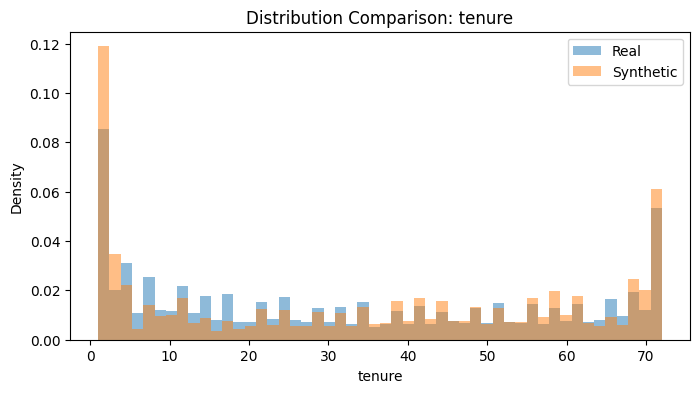

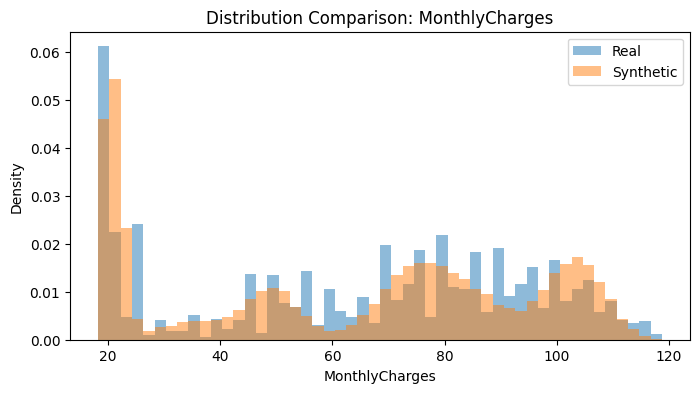

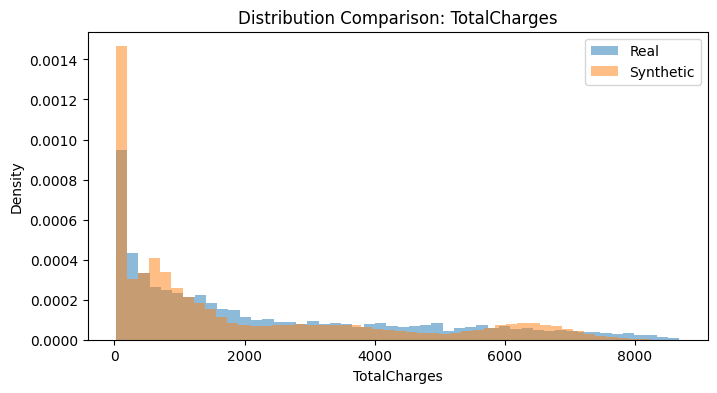


📊 Statistical Comparison of Numerical Columns:

🔹 Column: tenure
   - Kolmogorov-Smirnov Statistic : 0.0689 (p-value: 0.0000)
   - Wasserstein Distance         : 2.3843

🔹 Column: MonthlyCharges
   - Kolmogorov-Smirnov Statistic : 0.0748 (p-value: 0.0000)
   - Wasserstein Distance         : 2.4969

🔹 Column: TotalCharges
   - Kolmogorov-Smirnov Statistic : 0.1129 (p-value: 0.0000)
   - Wasserstein Distance         : 368.0321


In [30]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Separate real and fake data
real_numerical = real_df[numerical_cols]
fake_numerical = fake_df[numerical_cols]

# 1. Plot distribution comparison
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(real_numerical[col], bins=50, alpha=0.5, label='Real', density=True)
    plt.hist(fake_numerical[col], bins=50, alpha=0.5, label='Synthetic', density=True)
    plt.title(f'Distribution Comparison: {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# 2. Statistical similarity check
def compare_distributions(real_col, fake_col):
    ks_stat, ks_p = stats.ks_2samp(real_col, fake_col)
    wasserstein = stats.wasserstein_distance(real_col, fake_col)
    return ks_stat, ks_p, wasserstein

print("\n📊 Statistical Comparison of Numerical Columns:")
for col in numerical_cols:
    ks_stat, ks_p, wass_dist = compare_distributions(real_numerical[col], fake_numerical[col])
    print(f"\n🔹 Column: {col}")
    print(f"   - Kolmogorov-Smirnov Statistic : {ks_stat:.4f} (p-value: {ks_p:.4f})")
    print(f"   - Wasserstein Distance         : {wass_dist:.4f}")


### Real vs Synthetic Classification (Categorical Features Only)

**What this cell does**

This cell evaluates synthetic data quality by training a **LightGBM classifier using only categorical features** (numerical features removed) to distinguish real vs synthetic data.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `sklearn.model_selection` → `train_test_split()`  
- `sklearn.preprocessing` → `OrdinalEncoder()` for encoding categorical data  
- `sklearn.metrics` → classification metrics (accuracy, precision, recall, F1, ROC-AUC, report)  
- `lightgbm` → `LGBMClassifier()`  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load real and synthetic datasets.
2. Drop identifier and numerical columns (`customerID`, `tenure`, `MonthlyCharges`, `TotalCharges`).
3. Remove missing values.
4. Add `is_real` labels (1 = real, 0 = synthetic).
5. Align common categorical columns and combine datasets.
6. Encode all features using `OrdinalEncoder`.
7. Split into train/test sets (stratified).
8. Train LightGBM classifier.
9. Predict and evaluate using classification metrics.

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Load datasets
real_df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
fake_df = pd.read_csv('synthetic_data.csv')

# Drop unnecessary columns
drop_cols = ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
real_df = real_df.drop(columns=drop_cols, errors='ignore')
fake_df = fake_df.drop(columns=drop_cols, errors='ignore')

# Drop NaNs just in case
real_df = real_df.dropna().reset_index(drop=True)
fake_df = fake_df.dropna().reset_index(drop=True)

# Add label columns
real_df['is_real'] = 1
fake_df['is_real'] = 0

# Identify common columns
common_cols = list(set(real_df.columns).intersection(set(fake_df.columns)))
common_cols.remove('is_real')

# Combine datasets
combined = pd.concat([
    real_df[common_cols + ['is_real']],
    fake_df[common_cols + ['is_real']]
], axis=0).reset_index(drop=True)

# Treat all columns as categorical (since numerical ones were dropped)
categorical_cols = common_cols

# Ordinal encoding
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
combined[categorical_cols] = encoder.fit_transform(combined[categorical_cols])

# Split features and target
X = combined[common_cols]
y = combined['is_real']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=500, random_state=42)
lgb_model.fit(X_train, y_train)

# Evaluate
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

print("📈 Additional Evaluation Metrics:")
print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")


📊 Classification Report:

              precision    recall  f1-score   support

    Fake (0)       0.92      0.99      0.95     14000
    Real (1)       0.57      0.10      0.17      1409

    accuracy                           0.91     15409
   macro avg       0.75      0.55      0.56     15409
weighted avg       0.89      0.91      0.88     15409

📈 Additional Evaluation Metrics:
✅ Accuracy       : 0.9109
✅ Precision      : 0.5744
✅ Recall         : 0.0987
✅ F1 Score       : 0.1684
✅ ROC AUC Score  : 0.7824


In [27]:
# 🧮 Feature importance analysis
feature_importances = lgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': common_cols,
    'Importance': feature_importances
})

# Normalize to percentage
importance_df['Percentage'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

print("\n📌 Feature Importance (Percentage Contribution):\n")
for idx, row in importance_df.iterrows():
    print(f"🔹 {row['Feature']:25} : {row['Percentage']:.2f}%")



📌 Feature Importance (Percentage Contribution):

🔹 PaymentMethod             : 11.97%
🔹 Contract                  : 7.62%
🔹 MultipleLines             : 7.14%
🔹 gender                    : 6.54%
🔹 TechSupport               : 5.95%
🔹 StreamingTV               : 5.83%
🔹 OnlineSecurity            : 5.82%
🔹 StreamingMovies           : 5.76%
🔹 OnlineBackup              : 5.70%
🔹 DeviceProtection          : 5.64%
🔹 PaperlessBilling          : 5.49%
🔹 Partner                   : 5.49%
🔹 InternetService           : 5.32%
🔹 Dependents                : 4.90%
🔹 Churn                     : 4.17%
🔹 SeniorCitizen             : 3.63%
🔹 PhoneService              : 3.02%


### Cross-Domain Evaluation: Train on Real vs Synthetic (and Vice Versa)

**What this cell does**

This cell evaluates how well **models trained on real data generalize to synthetic data and vice versa**, using LightGBM classification on the `Churn` target.

---

**Libraries / Packages / Methods Used**

- `pandas` → data loading and preprocessing  
- `sklearn.model_selection` → `train_test_split()` (not used here but imported)  
- `sklearn.preprocessing` → `OrdinalEncoder()` for categorical encoding  
- `sklearn.metrics` → classification metrics (accuracy, precision, recall, F1, ROC-AUC, report)  
- `lightgbm` → `LGBMClassifier()`  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load real and synthetic datasets and drop `customerID`.
2. Identify numerical and categorical columns; convert numerical columns and clean missing values.
3. Encode categorical features using `OrdinalEncoder`.
4. Convert `Churn` to binary labels (1 = Yes, 0 = No).
5. Split into features (`X`) and target (`y`) for both datasets.
6. Train and evaluate two scenarios:
   - Train on real data → test on synthetic data  
   - Train on synthetic data → test on real data  
7. Compute metrics (accuracy, precision, recall, F1, ROC-AUC), handling edge cases where only one class is present.

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Load datasets
real_df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
synthetic_df = pd.read_csv('synthetic_data.csv')

# Drop customerID if it exists
real_df = real_df.drop(columns=[col for col in ['customerID'] if col in real_df.columns])
synthetic_df = synthetic_df.drop(columns=[col for col in ['customerID'] if col in synthetic_df.columns])

# Columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in real_df.columns if col not in numerical_cols and col != 'Churn']
target_col = 'Churn'

# Convert numerics
for col in numerical_cols:
    real_df[col] = pd.to_numeric(real_df[col], errors='coerce')
real_df = real_df.dropna().reset_index(drop=True)

# Encode categorical
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
real_df[categorical_cols] = encoder.fit_transform(real_df[categorical_cols])
synthetic_df[categorical_cols] = encoder.transform(synthetic_df[categorical_cols])

# Encode target
y_real = real_df[target_col].apply(lambda x: 1 if x == 'Yes' else 0)
y_synthetic = synthetic_df[target_col].apply(lambda x: 1 if x == 'Yes' else 0)
X_real = real_df.drop(columns=[target_col])
X_synthetic = synthetic_df.drop(columns=[target_col])

def evaluate_model(model, X_test, y_test, desc=""):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if len(model.classes_) > 1 else [0.0] * len(X_test)

    print(f"\n📊 Classification Report ({desc}):")
    try:
        print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))
    except ValueError:
        print("⚠️ Only one class present in predictions or ground truth. Skipping classification report.")

    print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
    if len(set(y_test)) > 1 and len(set(y_pred)) > 1:
        print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
        print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
        print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
        print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")
    else:
        print("⚠️ ROC AUC / Precision / Recall / F1 not available due to only one class.")

# Train on Real → Test on Synthetic
print("\n🎯 Train on Real ➔ Test on Synthetic")
model_real = lgb.LGBMClassifier(n_estimators=500, random_state=42)
model_real.fit(X_real, y_real)
evaluate_model(model_real, X_synthetic, y_synthetic, desc="Train Real - Test Synthetic")

# Train on Synthetic → Test on Real
print("\n🎯 Train on Synthetic ➔ Test on Real")
model_synth = lgb.LGBMClassifier(n_estimators=500, random_state=42)
model_synth.fit(X_synthetic, y_synthetic)
evaluate_model(model_synth, X_real, y_real, desc="Train Synthetic - Test Real")



🎯 Train on Real ➔ Test on Synthetic
[LightGBM] [Info] Number of positive: 1869, number of negative: 5163
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 7032, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265785 -> initscore=-1.016114
[LightGBM] [Info] Start training from score -1.016114

📊 Classification Report (Train Real - Test Synthetic):
              precision    recall  f1-score   support

No Churn (0)       0.81      0.92      0.86     49322
   Churn (1)       0.72      0.48      0.57     20678

    accuracy                           0.79     70000
   macro avg       0.76      0.70      0.72     70000
weighted avg       0.78      0.79      0.78     70000

✅ Accuracy       : 0.7906


### Testing by binning and quantile transformation

### CTGAN Generation per Tenure Segment with Quantile Transformation

**What this cell does**

This cell generates synthetic data by **training separate CTGAN models for each unique tenure value**, applies feature transformation per segment, combines all generated data, and evaluates overall quality.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and manipulation  
- `torch`, `random` → reproducibility and GPU support  
- `time` → execution tracking  
- `sklearn.preprocessing` → `QuantileTransformer()` for normalization  
- `sdv.single_table.CTGANSynthesizer` → synthetic data generation  
- `sdv.metadata.SingleTableMetadata` → metadata detection  
- `sdv.evaluation.single_table.evaluate_quality` → quality evaluation  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load dataset, drop `customerID`, clean `TotalCharges`.
2. Identify numerical and categorical columns and convert categoricals to `object`.
3. Loop through each unique `tenure` value:
   - filter subset of data for that tenure
   - skip small subsets (<10 rows)
   - apply `QuantileTransformer` to numerical columns
   - detect metadata and train CTGAN model
   - generate synthetic rows for that tenure
   - assign fixed tenure value back
4. Concatenate all synthetic subsets into final dataset.
5. Evaluate synthetic data using `evaluate_quality`.
6. Save synthetic dataset to CSV and log execution time.

In [3]:
import pandas as pd
import numpy as np
import torch
import random
import time
from sklearn.preprocessing import QuantileTransformer
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import warnings
warnings.filterwarnings("ignore")

# ✅ Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

start_time = time.time()
print("🚀 Starting reproducible CTGAN generation for each tenure separately on GPU...")

# ✅ Load and preprocess dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

# ✅ Identify numerical and categorical columns
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_columns = [col for col in df.columns if col not in numerical_columns]
for col in categorical_columns:
    df[col] = df[col].astype('object')

# ✅ Prepare CTGAN Hyperparameters
best_params = {
    'batch_size': 360,  # divisible by both 2 and 10
    'epochs': 1552,
    'embedding_dim': 110,
    'generator_lr': 0.004713204343061388,
    'discriminator_lr': 0.0017260261506771618,
    'generator_dim': (299, 216),
    'discriminator_dim': (230, 207),
    'verbose': True,
    'cuda': torch.cuda.is_available()
}

# ✅ Store all synthetic datasets here
all_synthetic_data = []

# ✅ Loop through each unique tenure
unique_tenures = sorted(df['tenure'].unique())
print(f"🔢 Found {len(unique_tenures)} unique tenures.")

for tenure_value in unique_tenures:
    print(f"\n🚀 Processing tenure = {tenure_value}...")
    tenure_df = df[df['tenure'] == tenure_value].copy().reset_index(drop=True)

    if len(tenure_df) < 10:
        print(f"⚠️ Skipping tenure {tenure_value} due to insufficient samples ({len(tenure_df)} rows).")
        continue

    # ✅ Apply Quantile Transformation separately
    qt_mc = QuantileTransformer(output_distribution='normal')
    qt_tc = QuantileTransformer(output_distribution='normal')

    tenure_df['MonthlyCharges'] = qt_mc.fit_transform(tenure_df[['MonthlyCharges']])
    tenure_df['TotalCharges'] = qt_tc.fit_transform(tenure_df[['TotalCharges']])

    # ✅ Create Metadata
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(tenure_df)

    # ✅ Train CTGAN
    model = CTGANSynthesizer(metadata, **best_params)

    print(f"🧠 Training CTGAN for tenure {tenure_value}...")
    model.fit(tenure_df)

    # ✅ Generate synthetic data
    generate_rows = max(500, len(tenure_df))  # You can adjust number of rows per tenure
    print(f"📈 Generating {generate_rows} synthetic rows for tenure {tenure_value}...")
    synthetic_df = model.sample(generate_rows)

    # ✅ Set the correct tenure value (since it's same for all in subset)
    synthetic_df['tenure'] = tenure_value

    # ✅ Append to overall list
    all_synthetic_data.append(synthetic_df)

# ✅ Concatenate all synthetic data
final_synthetic_df = pd.concat(all_synthetic_data, axis=0).reset_index(drop=True)
print(f"\n✅ Final synthetic dataset shape: {final_synthetic_df.shape}")

# ✅ Evaluate and display metrics
print("📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)

# Print individual detailed results
print("\n📌 Column Shapes Details:")
print(report.get_details(property_name='Column Shapes'))

print("\n📌 Column Pair Trends Details:")
print(report.get_details(property_name='Column Pair Trends'))

# Print overall score
print(f"\n✅ Overall Score: {report.get_score():.4f}")

# ✅ Save to CSV
output_path = "/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"📁 Synthetic data saved to: {output_path}")

# ✅ Completion time
end_time = time.time()
print(f"🎉 Completed in {end_time - start_time:.2f} seconds")


🚀 Starting reproducible CTGAN generation for each tenure separately on GPU...
🔢 Found 72 unique tenures.

🚀 Processing tenure = 1...
🧠 Training CTGAN for tenure 1...


Gen. (1.15) | Discrim. (0.03): 100%|██████████| 1552/1552 [00:52<00:00, 29.77it/s]  


📈 Generating 613 synthetic rows for tenure 1...

🚀 Processing tenure = 2...
🧠 Training CTGAN for tenure 2...


Gen. (0.04) | Discrim. (0.49): 100%|██████████| 1552/1552 [00:50<00:00, 30.68it/s]  


📈 Generating 500 synthetic rows for tenure 2...

🚀 Processing tenure = 3...
🧠 Training CTGAN for tenure 3...


...

📈 Generating 500 synthetic rows for tenure 70...

🚀 Processing tenure = 71...
🧠 Training CTGAN for tenure 71...


Gen. (1.94) | Discrim. (-0.81): 100%|██████████| 1552/1552 [00:49<00:00, 31.43it/s] 


📈 Generating 500 synthetic rows for tenure 71...

🚀 Processing tenure = 72...
🧠 Training CTGAN for tenure 72...


Gen. (-0.74) | Discrim. (-1.53): 100%|██████████| 1552/1552 [00:50<00:00, 30.86it/s]


📈 Generating 500 synthetic rows for tenure 72...

✅ Final synthetic dataset shape: (36113, 20)
📊 Evaluating quality of synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 249.56it/s]|
Column Shapes Score: 64.19%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:00<00:00, 199.64it/s]|
Column Pair Trends Score: 53.06%

Overall Score (Average): 58.62%


📌 Column Shapes Details:
              Column        Metric     Score
0             gender  TVComplement  0.924693
1      SeniorCitizen  TVComplement  0.964400
2            Partner  TVComplement  0.636509
3         Dependents  TVComplement  0.876493
4             tenure  TVComplement  0.051479
5       PhoneService  TVComplement  0.916701
6      MultipleLines  TVComplement  0.782629
7    InternetService  TVComplement  0.801727
8     OnlineSecurity  TVComplement  0.636702
9       OnlineBackup  TVComplement  0.747007
10  DeviceProtection  TVComplement  0.630011
11       TechSu

### Comprehensive Evaluation of Synthetic Data (SDV + Statistical Metrics)

**What this cell does**

This cell evaluates synthetic data quality using **SDV’s built-in metrics** and additional **statistical distance measures** for both numerical and categorical features.

---

**Libraries / Packages / Methods Used**

- `sdv.evaluation.single_table`
  - `evaluate_quality()` → overall quality report (column shapes & relationships)  
- `scipy.stats`
  - `ks_2samp()` → Kolmogorov-Smirnov test  
  - `wasserstein_distance()` → distribution distance  
- `scipy.spatial.distance`
  - `jensenshannon()` → categorical distribution similarity  
- `pandas`, `numpy` → data handling  
- `time` → execution tracking  

---

**How it is implemented**

1. Evaluate synthetic data using `evaluate_quality()` and print:
   - column-wise distribution similarity  
   - column-pair relationships  
   - overall score  
2. For numerical columns:
   - compute Wasserstein distance and KS statistic  
3. For categorical columns:
   - compare probability distributions and compute Jensen-Shannon divergence  
4. Save synthetic dataset to CSV.
5. Print total execution time.

In [4]:
import pandas as pd
import numpy as np
import torch
import random
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
from scipy.stats import wasserstein_distance
import warnings
warnings.filterwarnings("ignore")

# ✅ Evaluate using SDV built-in report
print("📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)
print("\n📌 Column Shapes Details:")
print(report.get_details(property_name='Column Shapes'))
print("\n📌 Column Pair Trends Details:")
print(report.get_details(property_name='Column Pair Trends'))
print(f"\n✅ Overall SDV Score: {report.get_score():.4f}")

# ✅ Additional evaluation metrics
print("\n📊 Advanced Evaluation Metrics:")
for col in numerical_columns:
    w_dist = wasserstein_distance(df[col], synthetic_df[col])
    ks_stat, ks_p = ks_2samp(df[col], synthetic_df[col])
    print(f"\n🔸 {col} (Numerical):")
    print(f"   - Wasserstein Distance  : {w_dist:.4f}")
    print(f"   - KS Statistic (p={ks_p:.4e})  : {ks_stat:.4f}")

for col in categorical_columns:
    real_counts = df[col].value_counts(normalize=True).sort_index()
    synthetic_counts = synthetic_df[col].value_counts(normalize=True).sort_index()
    all_values = real_counts.index.union(synthetic_counts.index)
    real_probs = real_counts.reindex(all_values, fill_value=0)
    synthetic_probs = synthetic_counts.reindex(all_values, fill_value=0)
    jsd = jensenshannon(real_probs, synthetic_probs, base=2)
    print(f"\n🔹 {col} (Categorical):")
    print(f"   - Jensen-Shannon Divergence : {jsd:.4f}")

# ✅ Save synthetic dataset
output_path = "/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"\n📁 Synthetic data saved to: {output_path}")

# ✅ Completion time
end_time = time.time()
print(f"🎉 Completed in {end_time - start_time:.2f} seconds")

📊 Evaluating quality of synthetic data...
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 252.46it/s]|
Column Shapes Score: 64.19%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:00<00:00, 205.01it/s]|
Column Pair Trends Score: 53.06%

Overall Score (Average): 58.62%


📌 Column Shapes Details:
              Column        Metric     Score
0             gender  TVComplement  0.924693
1      SeniorCitizen  TVComplement  0.964400
2            Partner  TVComplement  0.636509
3         Dependents  TVComplement  0.876493
4             tenure  TVComplement  0.051479
5       PhoneService  TVComplement  0.916701
6      MultipleLines  TVComplement  0.782629
7    InternetService  TVComplement  0.801727
8     OnlineSecurity  TVComplement  0.636702
9       OnlineBackup  TVComplement  0.747007
1

### Hybrid Modeling: Tenure (Classification) + MonthlyCharges (Regression) + Derived TotalCharges

**What this cell does**

This cell builds a **hybrid modeling pipeline** where:
- `tenure` is predicted as a **multiclass classification problem**
- `MonthlyCharges` is predicted using **regression**
- `TotalCharges` is **derived from predicted tenure × MonthlyCharges** and evaluated

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data preprocessing and transformations  
- `lightgbm`
  - `Dataset()`, `train()` → model training with early stopping  
- `sklearn.model_selection` → `train_test_split()`  
- `sklearn.preprocessing` → `LabelEncoder()`  
- `sklearn.metrics`
  - classification → `accuracy_score`, `f1_score`  
  - regression → `r2_score`, `mean_absolute_error`, `mean_squared_error`  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load dataset, drop `customerID`, clean `TotalCharges`.
2. Encode categorical features using `LabelEncoder`.
3. Convert `tenure` into discrete classes and create mappings.
4. Split data into features (`X`) and targets (`tenure_class`, `MonthlyCharges`).
5. Train LightGBM:
   - multiclass classifier for `tenure`
   - regression model for `MonthlyCharges`
6. Convert predicted tenure classes back to original values.
7. Compute evaluation metrics:
   - classification → accuracy, F1  
   - regression → R², MAE, RMSE  
8. Derive `TotalCharges = tenure × MonthlyCharges` and evaluate using regression metrics.

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# Load dataset
path = r'/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv'
df = pd.read_csv(path)

# Drop customerID
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Convert TotalCharges safely to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing target values
df.dropna(subset=['TotalCharges'], inplace=True)

# Encode categorical features
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Map tenure values to class labels starting from 0
tenure_unique = np.sort(df['tenure'].unique())
tenure_to_class = {v: i for i, v in enumerate(tenure_unique)}
class_to_tenure = {i: v for i, v in enumerate(tenure_unique)}

df['tenure_class'] = df['tenure'].map(tenure_to_class)

# Splitting features and targets
X = df.drop(columns=['tenure', 'MonthlyCharges', 'TotalCharges', 'tenure_class'])
y_tenure = df['tenure_class']
y_monthly = df['MonthlyCharges']

X_train, X_test, y_tenure_train, y_tenure_test, y_monthly_train, y_monthly_test = train_test_split(
    X, y_tenure, y_monthly, test_size=0.2, random_state=42
)

# Train model for tenure (classification)
print("\n--- Predicting Tenure (Classification) ---")
train_data_tenure = lgb.Dataset(X_train, label=y_tenure_train, categorical_feature=categorical_features)
valid_data_tenure = lgb.Dataset(X_test, label=y_tenure_test, categorical_feature=categorical_features)

params_tenure = {
    'objective': 'multiclass',
    'num_class': len(tenure_unique),
    'metric': 'multi_logloss',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'seed': 42,
    'verbosity': -1
}

model_tenure = lgb.train(
    params_tenure,
    train_data_tenure,
    valid_sets=[train_data_tenure, valid_data_tenure],
    num_boost_round=2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

# Predict class labels
y_tenure_pred_class = np.argmax(model_tenure.predict(X_test, num_iteration=model_tenure.best_iteration), axis=1)

# Map predicted classes back to original tenure values
y_tenure_pred = np.array([class_to_tenure[cls] for cls in y_tenure_pred_class])
y_tenure_true = np.array([class_to_tenure[cls] for cls in y_tenure_test])

tenure_acc = accuracy_score(y_tenure_true, y_tenure_pred)
tenure_f1 = f1_score(y_tenure_true, y_tenure_pred, average='macro')

print(f"Accuracy : {tenure_acc:.4f}")
print(f"F1 Score : {tenure_f1:.4f}")

# Train model for MonthlyCharges (regression)
print("\n--- Predicting MonthlyCharges (Regression) ---")
train_data_monthly = lgb.Dataset(X_train, label=y_monthly_train, categorical_feature=categorical_features)
valid_data_monthly = lgb.Dataset(X_test, label=y_monthly_test, categorical_feature=categorical_features)

params_monthly = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'seed': 42,
    'verbosity': -1
}

model_monthly = lgb.train(
    params_monthly,
    train_data_monthly,
    valid_sets=[train_data_monthly, valid_data_monthly],
    num_boost_round=2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

y_monthly_pred = model_monthly.predict(X_test, num_iteration=model_monthly.best_iteration)

monthly_r2 = r2_score(y_monthly_test, y_monthly_pred)
monthly_mae = mean_absolute_error(y_monthly_test, y_monthly_pred)
monthly_rmse = mean_squared_error(y_monthly_test, y_monthly_pred, squared=False)

print(f"R² Score : {monthly_r2:.4f}")
print(f"MAE      : {monthly_mae:.4f}")
print(f"RMSE     : {monthly_rmse:.4f}")

# --- Calculating TotalCharges ---
print("\n--- Calculating TotalCharges from Predicted tenure × MonthlyCharges ---")
totalcharges_pred = y_tenure_pred * y_monthly_pred
totalcharges_true = y_tenure_true * y_monthly_test

totalcharges_r2 = r2_score(totalcharges_true, totalcharges_pred)
totalcharges_mae = mean_absolute_error(totalcharges_true, totalcharges_pred)
totalcharges_rmse = mean_squared_error(totalcharges_true, totalcharges_pred, squared=False)

print(f"R² Score : {totalcharges_r2:.4f}")
print(f"MAE      : {totalcharges_mae:.4f}")
print(f"RMSE     : {totalcharges_rmse:.4f}")



--- Predicting Tenure (Classification) ---
Training until validation scores don't improve for 100 rounds
[100]	training's multi_logloss: 2.25781	valid_1's multi_logloss: 3.98281
Early stopping, best iteration is:
[48]	training's multi_logloss: 2.90944	valid_1's multi_logloss: 3.9394
Accuracy : 0.1429
F1 Score : 0.0206

--- Predicting MonthlyCharges (Regression) ---
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 11.2419	valid_1's rmse: 11.1358
[200]	training's rmse: 4.31943	valid_1's rmse: 4.34575
[300]	training's rmse: 1.87784	valid_1's rmse: 1.95689
[400]	training's rmse: 1.1608	valid_1's rmse: 1.26554
[500]	training's rmse: 0.997843	valid_1's rmse: 1.11504
[600]	training's rmse: 0.949155	valid_1's rmse: 1.08311
[700]	training's rmse: 0.923092	valid_1's rmse: 1.07545
[800]	training's rmse: 0.904864	valid_1's rmse: 1.0751
Early stopping, best iteration is:
[761]	training's rmse: 0.91141	valid_1's rmse: 1.07456
R² Score : 0.9987
MAE      : 0.8103
R

### Regression-Based Modeling for Tenure, MonthlyCharges, and Derived TotalCharges

**What this cell does**

This cell trains **regression models for both `tenure` and `MonthlyCharges`**, then derives `TotalCharges` using their predictions and evaluates all three.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data preprocessing and transformations  
- `lightgbm`
  - `Dataset()`, `train()` → regression model training with early stopping  
- `sklearn.model_selection` → `train_test_split()`  
- `sklearn.preprocessing` → `LabelEncoder()`  
- `sklearn.metrics` → `r2_score`, `mean_absolute_error`, `mean_squared_error`  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load dataset, drop `customerID`, clean `TotalCharges`.
2. Encode categorical features using `LabelEncoder`.
3. Split data into features (`X`) and targets (`tenure`, `MonthlyCharges`).
4. Train LightGBM regression models separately for:
   - `tenure` (predictions rounded and clipped to valid values)  
   - `MonthlyCharges`
5. Evaluate both using R², MAE, RMSE.
6. Compute `TotalCharges = predicted tenure × predicted MonthlyCharges`.
7. Evaluate derived `TotalCharges` using regression metrics.

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# Load dataset
path = r'/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv'
df = pd.read_csv(path)

# Drop customerID
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Convert TotalCharges safely to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing target values
df.dropna(subset=['TotalCharges'], inplace=True)

# Encode categorical features
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Splitting features and targets
X = df.drop(columns=['tenure', 'MonthlyCharges', 'TotalCharges'])
y_tenure = df['tenure']
y_monthly = df['MonthlyCharges']

X_train, X_test, y_tenure_train, y_tenure_test, y_monthly_train, y_monthly_test = train_test_split(
    X, y_tenure, y_monthly, test_size=0.2, random_state=42
)

# --- Predict tenure as regression ---
print("\n--- Predicting Tenure (Regression) ---")
train_data_tenure = lgb.Dataset(X_train, label=y_tenure_train, categorical_feature=categorical_features)
valid_data_tenure = lgb.Dataset(X_test, label=y_tenure_test, categorical_feature=categorical_features)

params_tenure = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'seed': 42,
    'verbosity': -1
}

model_tenure = lgb.train(
    params_tenure,
    train_data_tenure,
    valid_sets=[train_data_tenure, valid_data_tenure],
    num_boost_round=2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

# Predict tenure
y_tenure_pred = model_tenure.predict(X_test, num_iteration=model_tenure.best_iteration)
y_tenure_pred_rounded = np.round(y_tenure_pred)

# Clamp negative predictions to zero if any (just in case)
y_tenure_pred_rounded = np.clip(y_tenure_pred_rounded, 0, None)

# Metrics for tenure
tenure_r2 = r2_score(y_tenure_test, y_tenure_pred_rounded)
tenure_mae = mean_absolute_error(y_tenure_test, y_tenure_pred_rounded)
tenure_rmse = mean_squared_error(y_tenure_test, y_tenure_pred_rounded, squared=False)

print(f"R² Score : {tenure_r2:.4f}")
print(f"MAE      : {tenure_mae:.4f}")
print(f"RMSE     : {tenure_rmse:.4f}")

# --- Predict MonthlyCharges as regression ---
print("\n--- Predicting MonthlyCharges (Regression) ---")
train_data_monthly = lgb.Dataset(X_train, label=y_monthly_train, categorical_feature=categorical_features)
valid_data_monthly = lgb.Dataset(X_test, label=y_monthly_test, categorical_feature=categorical_features)

params_monthly = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'seed': 42,
    'verbosity': -1
}

model_monthly = lgb.train(
    params_monthly,
    train_data_monthly,
    valid_sets=[train_data_monthly, valid_data_monthly],
    num_boost_round=2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

# Predict MonthlyCharges
y_monthly_pred = model_monthly.predict(X_test, num_iteration=model_monthly.best_iteration)

# Metrics for MonthlyCharges
monthly_r2 = r2_score(y_monthly_test, y_monthly_pred)
monthly_mae = mean_absolute_error(y_monthly_test, y_monthly_pred)
monthly_rmse = mean_squared_error(y_monthly_test, y_monthly_pred, squared=False)

print(f"R² Score : {monthly_r2:.4f}")
print(f"MAE      : {monthly_mae:.4f}")
print(f"RMSE     : {monthly_rmse:.4f}")

# --- Calculating TotalCharges ---
print("\n--- Calculating TotalCharges from Predicted tenure × MonthlyCharges ---")
totalcharges_pred = y_tenure_pred_rounded * y_monthly_pred
totalcharges_true = y_tenure_test * y_monthly_test

totalcharges_r2 = r2_score(totalcharges_true, totalcharges_pred)
totalcharges_mae = mean_absolute_error(totalcharges_true, totalcharges_pred)
totalcharges_rmse = mean_squared_error(totalcharges_true, totalcharges_pred, squared=False)

print(f"R² Score : {totalcharges_r2:.4f}")
print(f"MAE      : {totalcharges_mae:.4f}")
print(f"RMSE     : {totalcharges_rmse:.4f}")



--- Predicting Tenure (Regression) ---
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 15.735	valid_1's rmse: 16.4195
[200]	training's rmse: 13.6838	valid_1's rmse: 14.9078
[300]	training's rmse: 13.0708	valid_1's rmse: 14.6761
[400]	training's rmse: 12.7551	valid_1's rmse: 14.7079
Early stopping, best iteration is:
[305]	training's rmse: 13.0519	valid_1's rmse: 14.6743
R² Score : 0.6437
MAE      : 11.5068
RMSE     : 14.6698

--- Predicting MonthlyCharges (Regression) ---
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 11.2419	valid_1's rmse: 11.1358
[200]	training's rmse: 4.31943	valid_1's rmse: 4.34575
[300]	training's rmse: 1.87784	valid_1's rmse: 1.95689
[400]	training's rmse: 1.1608	valid_1's rmse: 1.26554
[500]	training's rmse: 0.997843	valid_1's rmse: 1.11504
[600]	training's rmse: 0.949155	valid_1's rmse: 1.08311
[700]	training's rmse: 0.923092	valid_1's rmse: 1.07545
[800]	training's rmse: 0.904864	vali

### End-to-End Pipeline: Predict Numerical Features → Derive TotalCharges → Predict Churn

**What this cell does**

This cell builds a **full pipeline** where:
1. `tenure` and `MonthlyCharges` are predicted using regression  
2. `TotalCharges` is derived from predictions  
3. These predicted values are then used to **predict `Churn`**, evaluating end-to-end impact  

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data preprocessing and transformations  
- `lightgbm`
  - `Dataset()`, `train()` → regression & classification models  
- `sklearn.model_selection` → `train_test_split()`  
- `sklearn.preprocessing` → `LabelEncoder()`  
- `sklearn.metrics`
  - regression → `r2_score`, `MAE`, `RMSE`  
  - classification → `accuracy`, `precision`, `recall`, `F1`, `ROC-AUC`, `confusion_matrix`  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load and clean dataset (`customerID`, `TotalCharges`), encode categorical features and `Churn`.
2. Split data into:
   - features (`X`)
   - targets (`tenure`, `MonthlyCharges`)
3. Train LightGBM regression models:
   - predict `tenure` (rounded + clipped)  
   - predict `MonthlyCharges`
4. Compute `TotalCharges = predicted tenure × predicted MonthlyCharges`.
5. Build new datasets:
   - training → real values  
   - testing → predicted values  
6. Train LightGBM classifier for `Churn`.
7. Evaluate using classification metrics (accuracy, precision, recall, F1, ROC-AUC, confusion matrix).

In [6]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# --- Load dataset ---
path = r'/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv'
df = pd.read_csv(path)

# --- Basic cleanup ---
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# --- Encode categorical features ---
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features.remove('Churn')  # We'll encode Churn separately
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Encode target Churn separately
le_churn = LabelEncoder()
df['Churn'] = le_churn.fit_transform(df['Churn'].astype(str))  # Yes/No -> 1/0

# --- Splitting features and targets for tenure and MonthlyCharges ---
X = df.drop(columns=['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'])
y_tenure = df['tenure']
y_monthly = df['MonthlyCharges']

X_train, X_test, y_tenure_train, y_tenure_test, y_monthly_train, y_monthly_test = train_test_split(
    X, y_tenure, y_monthly, test_size=0.2, random_state=42
)

# --- Predict tenure (regression) ---
print("\n--- Predicting Tenure (Regression) ---")
train_data_tenure = lgb.Dataset(X_train, label=y_tenure_train, categorical_feature=categorical_features)
valid_data_tenure = lgb.Dataset(X_test, label=y_tenure_test, categorical_feature=categorical_features)

params_tenure = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'seed': 42,
    'verbosity': -1
}

model_tenure = lgb.train(
    params_tenure,
    train_data_tenure,
    valid_sets=[train_data_tenure, valid_data_tenure],
    num_boost_round=2000,
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
)

y_tenure_pred = model_tenure.predict(X_test, num_iteration=model_tenure.best_iteration)
y_tenure_pred_rounded = np.round(np.clip(y_tenure_pred, 0, None))  # Round + Clip

print(f"R² Score : {r2_score(y_tenure_test, y_tenure_pred_rounded):.4f}")
print(f"MAE      : {mean_absolute_error(y_tenure_test, y_tenure_pred_rounded):.4f}")
print(f"RMSE     : {mean_squared_error(y_tenure_test, y_tenure_pred_rounded, squared=False):.4f}")

# --- Predict MonthlyCharges (regression) ---
print("\n--- Predicting MonthlyCharges (Regression) ---")
train_data_monthly = lgb.Dataset(X_train, label=y_monthly_train, categorical_feature=categorical_features)
valid_data_monthly = lgb.Dataset(X_test, label=y_monthly_test, categorical_feature=categorical_features)

params_monthly = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'seed': 42,
    'verbosity': -1
}

model_monthly = lgb.train(
    params_monthly,
    train_data_monthly,
    valid_sets=[train_data_monthly, valid_data_monthly],
    num_boost_round=2000,
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
)

y_monthly_pred = model_monthly.predict(X_test, num_iteration=model_monthly.best_iteration)

print(f"R² Score : {r2_score(y_monthly_test, y_monthly_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_monthly_test, y_monthly_pred):.4f}")
print(f"RMSE     : {mean_squared_error(y_monthly_test, y_monthly_pred, squared=False):.4f}")

# --- Calculate TotalCharges ---
print("\n--- Calculating TotalCharges from Predicted tenure × MonthlyCharges ---")
totalcharges_pred = y_tenure_pred_rounded * y_monthly_pred
totalcharges_true = y_tenure_test * y_monthly_test

print(f"R² Score : {r2_score(totalcharges_true, totalcharges_pred):.4f}")
print(f"MAE      : {mean_absolute_error(totalcharges_true, totalcharges_pred):.4f}")
print(f"RMSE     : {mean_squared_error(totalcharges_true, totalcharges_pred, squared=False):.4f}")

# --- Now Predict Churn based on new tenure, monthlycharges, totalcharges ---
print("\n--- Predicting Churn using Predicted tenure, MonthlyCharges, TotalCharges ---")

# Create new test set with predicted values
X_test_new = X_test.copy()
X_test_new['tenure'] = y_tenure_pred_rounded
X_test_new['MonthlyCharges'] = y_monthly_pred
X_test_new['TotalCharges'] = totalcharges_pred

# For training, use the original values
X_train_new = X_train.copy()
X_train_new['tenure'] = y_tenure_train
X_train_new['MonthlyCharges'] = y_monthly_train
X_train_new['TotalCharges'] = y_tenure_train * y_monthly_train  # Real TotalCharges

# Target
y_churn_train = df.loc[X_train.index, 'Churn']
y_churn_test = df.loc[X_test.index, 'Churn']

# Train LightGBM for classification
train_data_churn = lgb.Dataset(X_train_new, label=y_churn_train, categorical_feature=categorical_features)
valid_data_churn = lgb.Dataset(X_test_new, label=y_churn_test, categorical_feature=categorical_features)

params_churn = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'seed': 42,
    'verbosity': -1
}

model_churn = lgb.train(
    params_churn,
    train_data_churn,
    valid_sets=[train_data_churn, valid_data_churn],
    num_boost_round=2000,
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
)

# Predict Churn
y_churn_pred_proba = model_churn.predict(X_test_new, num_iteration=model_churn.best_iteration)
y_churn_pred = (y_churn_pred_proba > 0.5).astype(int)

# --- Evaluate Churn prediction ---
print(f"\n✅ Churn Prediction Results:")

churn_acc = accuracy_score(y_churn_test, y_churn_pred)
churn_f1 = f1_score(y_churn_test, y_churn_pred)
churn_precision = precision_score(y_churn_test, y_churn_pred)
churn_recall = recall_score(y_churn_test, y_churn_pred)
churn_auc = roc_auc_score(y_churn_test, y_churn_pred_proba)
conf_matrix = confusion_matrix(y_churn_test, y_churn_pred)

print(f"Accuracy         : {churn_acc:.4f}")
print(f"F1 Score         : {churn_f1:.4f}")
print(f"Precision        : {churn_precision:.4f}")
print(f"Recall           : {churn_recall:.4f}")
print(f"ROC-AUC Score    : {churn_auc:.4f}")
print(f"Confusion Matrix :\n{conf_matrix}")



--- Predicting Tenure (Regression) ---
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 15.9025	valid_1's rmse: 16.5549
[200]	training's rmse: 13.9356	valid_1's rmse: 15.168
[300]	training's rmse: 13.3588	valid_1's rmse: 14.9924
Early stopping, best iteration is:
[279]	training's rmse: 13.4431	valid_1's rmse: 14.9852
R² Score : 0.6276
MAE      : 11.7335
RMSE     : 14.9969

--- Predicting MonthlyCharges (Regression) ---
Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 11.2419	valid_1's rmse: 11.1358
[200]	training's rmse: 4.31943	valid_1's rmse: 4.34575
[300]	training's rmse: 1.87784	valid_1's rmse: 1.9568
[400]	training's rmse: 1.16149	valid_1's rmse: 1.26594
[500]	training's rmse: 1.00032	valid_1's rmse: 1.11563
[600]	training's rmse: 0.952491	valid_1's rmse: 1.08461
[700]	training's rmse: 0.927789	valid_1's rmse: 1.0776
[800]	training's rmse: 0.909741	valid_1's rmse: 1.07899
Early stopping, best iteration is:
[7

### Normality Analysis using Quantile Transformation (Global, Binned, and Per-Tenure)

**What this cell does**

This cell evaluates how well **Quantile Transformation normalizes numerical features** (`MonthlyCharges`, `TotalCharges`) across:
- the full dataset  
- tenure-based bins  
- each individual tenure value  

using **skewness and kurtosis**.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and manipulation  
- `scipy.stats`
  - `skew()` → measures asymmetry  
  - `kurtosis()` → measures tail heaviness  
- `sklearn.preprocessing` → `QuantileTransformer()` (normal distribution mapping)  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load dataset, drop `customerID`, clean `TotalCharges`.
2. Define numerical columns to analyze.
3. Apply `QuantileTransformer`:
   - on entire dataset  
   - on 6 tenure bins  
   - on each unique tenure subset (skip small samples)  
4. For each case, compute:
   - skewness  
   - kurtosis  
5. Store results in a list → convert to DataFrame.
6. Print grouped results and save to CSV.

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import QuantileTransformer
import warnings
warnings.filterwarnings("ignore")

# ✅ Load Dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

# ✅ Columns of interest
columns_of_interest = ['MonthlyCharges', 'TotalCharges']

# ✅ Helper to calculate skewness and kurtosis
def check_normality(df_sub, label="Overall"):
    results = []
    for col in columns_of_interest:
        skewness = stats.skew(df_sub[col])
        kurtosis = stats.kurtosis(df_sub[col], fisher=False)  # fisher=False → normal kurtosis = 3
        results.append({
            'Base': label,
            'Feature': col,
            'Skewness': skewness,
            'Kurtosis': kurtosis
        })
    return results

# ✅ Store all normality results
all_results = []

# ✅ 1. Whole dataset (no binning)
print("\n🔵 Checking normality on whole dataset (no binning)...")

qt = QuantileTransformer(output_distribution='normal')
df_transformed = df.copy()

for col in columns_of_interest:
    df_transformed[col] = qt.fit_transform(df[[col]])

all_results.extend(check_normality(df_transformed, label="Whole Dataset"))

# ✅ 2. Binning into 6 ranges (0-12,13-24,...)
print("\n🟢 Checking normality on 6 tenure bins...")

bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
df['tenure_bin'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True, include_lowest=True)

for bin_label in labels:
    bin_df = df[df['tenure_bin'] == bin_label].copy()
    if bin_df.empty:
        continue
    qt_bin = QuantileTransformer(output_distribution='normal')
    for col in columns_of_interest:
        bin_df[col] = qt_bin.fit_transform(bin_df[[col]])
    all_results.extend(check_normality(bin_df, label=f"Tenure Bin: {bin_label}"))

# ✅ 3. Each unique tenure value
print("\n🟣 Checking normality on each unique tenure value...")

unique_tenures = sorted(df['tenure'].unique())

for tenure_value in unique_tenures:
    tenure_df = df[df['tenure'] == tenure_value].copy()
    if len(tenure_df) < 5:  # Skip too small groups
        continue
    qt_tenure = QuantileTransformer(output_distribution='normal')
    for col in columns_of_interest:
        tenure_df[col] = qt_tenure.fit_transform(tenure_df[[col]])
    all_results.extend(check_normality(tenure_df, label=f"Tenure: {tenure_value}"))

# ✅ Make final results dataframe
final_results_df = pd.DataFrame(all_results)

# ✅ Display using loops
print("\n✅ Normality check results (Skewness and Kurtosis):")

# Group by 'Base' and print each group
for base_label, group_df in final_results_df.groupby('Base'):
    print(f"\n📂 Base: {base_label}")
    for _, row in group_df.iterrows():
        print(f" - Feature: {row['Feature']}, Skewness: {row['Skewness']:.4f}, Kurtosis: {row['Kurtosis']:.4f}")

# ✅ Optionally, save to CSV
final_results_df.to_csv("/kaggle/working/normality_check_quantile_transform.csv", index=False)
print("\n📁 Results saved to /kaggle/working/normality_check_quantile_transform.csv")



🔵 Checking normality on whole dataset (no binning)...

🟢 Checking normality on 6 tenure bins...

🟣 Checking normality on each unique tenure value...

✅ Normality check results (Skewness and Kurtosis):

📂 Base: Tenure Bin: 0-12
 - Feature: MonthlyCharges, Skewness: 0.0019, Kurtosis: 3.4435
 - Feature: TotalCharges, Skewness: -0.0010, Kurtosis: 3.4386

📂 Base: Tenure Bin: 13-24
 - Feature: MonthlyCharges, Skewness: -0.2770, Kurtosis: 5.1670
 - Feature: TotalCharges, Skewness: 0.0007, Kurtosis: 3.9442

📂 Base: Tenure Bin: 25-36
 - Feature: MonthlyCharges, Skewness: 0.0008, Kurtosis: 4.1451
 - Feature: TotalCharges, Skewness: -0.0000, Kurtosis: 4.1461

📂 Base: Tenure Bin: 37-48
 - Feature: MonthlyCharges, Skewness: 0.0011, Kurtosis: 4.2418
 - Feature: TotalCharges, Skewness: -0.0000, Kurtosis: 4.2432

📂 Base: Tenure Bin: 49-60
 - Feature: MonthlyCharges, Skewness: 0.0002, Kurtosis: 4.1462
 - Feature: TotalCharges, Skewness: 0.0000, Kurtosis: 4.1461

📂 Base: Tenure Bin: 61-72
 - Feature: M

### CTGAN Training on Quantile-Transformed Data with Normality Check

**What this cell does**

This cell applies **Quantile Transformation to numerical features**, verifies normality, trains a **CTGAN model on the transformed dataset**, generates synthetic data, and evaluates its quality.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `torch`, `random` → reproducibility and GPU usage  
- `time` → execution tracking  
- `scipy.stats`
  - `skew()`, `kurtosis()` → normality check  
- `sklearn.preprocessing` → `QuantileTransformer()`  
- `sdv.single_table.CTGANSynthesizer` → synthetic data generation  
- `sdv.metadata.SingleTableMetadata` → metadata detection  
- `sdv.evaluation.single_table.evaluate_quality` → synthetic data evaluation  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load dataset, drop `customerID`, clean `TotalCharges`.
2. Identify numerical and categorical columns; convert categoricals to `object`.
3. Apply `QuantileTransformer` to `MonthlyCharges` and `TotalCharges`.
4. Compute skewness and kurtosis to verify normalization.
5. Save transformed dataset.
6. Detect metadata and train CTGAN using predefined hyperparameters.
7. Generate synthetic dataset (70,000 rows).
8. Evaluate synthetic data using SDV quality metrics (column shapes & relationships).
9. Save synthetic dataset and log execution time.

In [2]:
import pandas as pd
import numpy as np
import torch
import random
import time
import scipy.stats as stats
from sklearn.preprocessing import QuantileTransformer
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import warnings
warnings.filterwarnings("ignore")

# ✅ Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

start_time = time.time()
print("🚀 Starting reproducible CTGAN generation on GPU...")

# ✅ Load and preprocess dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

# ✅ Identify numerical and categorical columns
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_columns = [col for col in df.columns if col not in numerical_columns]
for col in categorical_columns:
    df[col] = df[col].astype('object')

# ✅ Apply QuantileTransformer to entire dataset for MonthlyCharges and TotalCharges
print("\n🔵 Applying QuantileTransformer to MonthlyCharges and TotalCharges on entire dataset...")
qt_mc = QuantileTransformer(output_distribution='normal')
qt_tc = QuantileTransformer(output_distribution='normal')

df['MonthlyCharges'] = qt_mc.fit_transform(df[['MonthlyCharges']])
df['TotalCharges'] = qt_tc.fit_transform(df[['TotalCharges']])

# ✅ Check and display normality after transformation
print("\n📈 Checking skewness and kurtosis after Quantile Transformation:")

columns_of_interest = ['MonthlyCharges', 'TotalCharges']
for col in columns_of_interest:
    skewness = stats.skew(df[col])
    kurtosis = stats.kurtosis(df[col], fisher=False)
    print(f" - Feature: {col}, Skewness: {skewness:.4f}, Kurtosis: {kurtosis:.4f}")

# ✅ Save transformed dataset
transformed_data_path = "/kaggle/working/transformed_dataset_quantile.csv"
df.to_csv(transformed_data_path, index=False)
print(f"\n📁 Transformed dataset saved to: {transformed_data_path}")

# ✅ Prepare CTGAN Hyperparameters
best_params = {
    'batch_size': 360,
    'epochs': 1552,
    'embedding_dim': 110,
    'generator_lr': 0.004713204343061388,
    'discriminator_lr': 0.0017260261506771618,
    'generator_dim': (299, 216),
    'discriminator_dim': (230, 207),
    'verbose': True,
    'cuda': torch.cuda.is_available()
}

# ✅ Create Metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

# ✅ Train CTGAN on full transformed data
print("\n🧠 Training CTGAN on transformed dataset...")
model = CTGANSynthesizer(metadata, **best_params)
model.fit(df)

# ✅ Generate synthetic data
generate_rows = 70000  # Adjust based on your needs
print(f"\n📈 Generating {generate_rows} synthetic rows...")
synthetic_df = model.sample(generate_rows)

# ✅ Save synthetic dataset
synthetic_data_path = "/kaggle/working/synthetic_CTGAN_quantile_dataset.csv"
synthetic_df.to_csv(synthetic_data_path, index=False)
print(f"\n📁 Synthetic data saved to: {synthetic_data_path}")

# ✅ Evaluate and display metrics
print("\n📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)

# Print individual detailed results
print("\n📌 Column Shapes Details:")
for detail in report.get_details(property_name='Column Shapes'):
    print(detail)

print("\n📌 Column Pair Trends Details:")
for detail in report.get_details(property_name='Column Pair Trends'):
    print(detail)

# Print overall score
print(f"\n✅ Overall Quality Score: {report.get_score():.4f}")

# ✅ Completion time
end_time = time.time()
print(f"\n🎉 Completed in {end_time - start_time:.2f} seconds")


🚀 Starting reproducible CTGAN generation on GPU...

🔵 Applying QuantileTransformer to MonthlyCharges and TotalCharges on entire dataset...

📈 Checking skewness and kurtosis after Quantile Transformation:
 - Feature: MonthlyCharges, Skewness: 0.0054, Kurtosis: 3.1472
 - Feature: TotalCharges, Skewness: -0.0022, Kurtosis: 3.1417

📁 Transformed dataset saved to: /kaggle/working/transformed_dataset_quantile.csv

🧠 Training CTGAN on transformed dataset...


Gen. (0.22) | Discrim. (0.39): 100%|██████████| 1552/1552 [14:21<00:00,  1.80it/s]  



📈 Generating 70000 synthetic rows...

📁 Synthetic data saved to: /kaggle/working/synthetic_CTGAN_quantile_dataset.csv

📊 Evaluating quality of synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 83.01it/s]|
Column Shapes Score: 95.88%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:03<00:00, 59.45it/s]|
Column Pair Trends Score: 91.7%

Overall Score (Average): 93.79%


📌 Column Shapes Details:
Column
Metric
Score

📌 Column Pair Trends Details:
Column 1
Column 2
Metric
Score
Real Correlation
Synthetic Correlation

✅ Overall Quality Score: 0.9379

🎉 Completed in 876.89 seconds


### Synthetic Data Evaluation (SDV + Statistical Distance Metrics)

**What this cell does**

This cell evaluates the **quality of synthetic data** using both **SDV’s built-in evaluation** and additional **statistical distance metrics** for numerical and categorical features.

---

**Libraries / Packages / Methods Used**

- `sdv.evaluation.single_table`
  - `evaluate_quality()` → overall quality report  
- `scipy.stats`
  - `ks_2samp()` → Kolmogorov-Smirnov test  
  - `wasserstein_distance()` → distribution distance  
- `scipy.spatial.distance`
  - `jensenshannon()` → categorical distribution similarity  
- `pandas`, `numpy` → data handling  
- `time` → execution tracking  

---

**How it is implemented**

1. Evaluate synthetic data using `evaluate_quality()`:
   - print column distribution similarity  
   - print column-pair relationships  
   - print overall score  
2. For numerical columns:
   - compute Wasserstein distance and KS statistic  
3. For categorical columns:
   - compute Jensen-Shannon divergence between real and synthetic distributions  
4. Save synthetic dataset to CSV.
5. Print total execution time.

In [3]:
import pandas as pd
import numpy as np
import torch
import random
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
from scipy.stats import wasserstein_distance
import warnings
warnings.filterwarnings("ignore")

# ✅ Evaluate using SDV built-in report
print("📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)
print("\n📌 Column Shapes Details:")
print(report.get_details(property_name='Column Shapes'))
print("\n📌 Column Pair Trends Details:")
print(report.get_details(property_name='Column Pair Trends'))
print(f"\n✅ Overall SDV Score: {report.get_score():.4f}")

# ✅ Additional evaluation metrics
print("\n📊 Advanced Evaluation Metrics:")
for col in numerical_columns:
    w_dist = wasserstein_distance(df[col], synthetic_df[col])
    ks_stat, ks_p = ks_2samp(df[col], synthetic_df[col])
    print(f"\n🔸 {col} (Numerical):")
    print(f"   - Wasserstein Distance  : {w_dist:.4f}")
    print(f"   - KS Statistic (p={ks_p:.4e})  : {ks_stat:.4f}")

for col in categorical_columns:
    real_counts = df[col].value_counts(normalize=True).sort_index()
    synthetic_counts = synthetic_df[col].value_counts(normalize=True).sort_index()
    all_values = real_counts.index.union(synthetic_counts.index)
    real_probs = real_counts.reindex(all_values, fill_value=0)
    synthetic_probs = synthetic_counts.reindex(all_values, fill_value=0)
    jsd = jensenshannon(real_probs, synthetic_probs, base=2)
    print(f"\n🔹 {col} (Categorical):")
    print(f"   - Jensen-Shannon Divergence : {jsd:.4f}")

# ✅ Save synthetic dataset
output_path = "/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"\n📁 Synthetic data saved to: {output_path}")

# ✅ Completion time
end_time = time.time()
print(f"🎉 Completed in {end_time - start_time:.2f} seconds")

📊 Evaluating quality of synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 72.50it/s]|
Column Shapes Score: 95.88%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:03<00:00, 60.53it/s]|
Column Pair Trends Score: 91.7%

Overall Score (Average): 93.79%


📌 Column Shapes Details:
              Column        Metric     Score
0             gender  TVComplement  0.982850
1      SeniorCitizen  TVComplement  0.992029
2            Partner  TVComplement  0.958280
3         Dependents  TVComplement  0.968964
4             tenure  KSComplement  0.960044
5       PhoneService  TVComplement  0.966415
6      MultipleLines  TVComplement  0.924372
7    InternetService  TVComplement  0.962912
8     OnlineSecurity  TVComplement  0.961455
9       OnlineBackup  TVComplement  0.967098
10  DeviceProtection  TVComplement  0.966126
11       TechSupport  TVComplement  0.934998
12       StreamingTV  TVComplement  0.950814
13   StreamingMovies  T

### Real vs Synthetic Classification (Quantile-Transformed Data)

**What this cell does**

This cell evaluates the **quality of CTGAN-generated data (after Quantile Transformation)** by training a LightGBM classifier to distinguish **real vs synthetic samples**.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `sklearn.model_selection` → `train_test_split()`  
- `sklearn.preprocessing` → `OrdinalEncoder()` for categorical encoding  
- `sklearn.metrics` → classification metrics (accuracy, precision, recall, F1, ROC-AUC, report)  
- `lightgbm` → `LGBMClassifier()`  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load transformed real dataset and synthetic dataset.
2. Clean real data (`TotalCharges`, missing values).
3. Add `is_real` labels (1 = real, 0 = synthetic).
4. Align common columns and combine datasets.
5. Identify categorical and numerical features.
6. Encode categorical features using `OrdinalEncoder` (if present).
7. Split into train/test sets (stratified).
8. Train LightGBM classifier.
9. Predict and evaluate using classification metrics (accuracy, precision, recall, F1, ROC-AUC).

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ✅ Load datasets
synthetic_df = pd.read_csv('/kaggle/working/synthetic_CTGAN_quantile_dataset.csv')
real_df = pd.read_csv('/kaggle/working/transformed_dataset_quantile.csv')

# ✅ Clean real data
real_df['TotalCharges'] = pd.to_numeric(real_df['TotalCharges'], errors='coerce')
real_df = real_df.dropna().reset_index(drop=True)

# ✅ Add label column
real_df['is_real'] = 1
synthetic_df['is_real'] = 0

# ✅ Match columns
common_cols = list(set(real_df.columns).intersection(set(synthetic_df.columns)))
common_cols.remove('is_real')

# ✅ Combine datasets
combined = pd.concat([
    real_df[common_cols + ['is_real']],
    synthetic_df[common_cols + ['is_real']]
], axis=0).reset_index(drop=True)

# ✅ Identify categorical and numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in common_cols if col not in numerical_cols]

# ✅ Encode categorical variables
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if len(categorical_cols) > 0:  # Just a safe check
    combined[categorical_cols] = encoder.fit_transform(combined[categorical_cols])

# ✅ Split features and target
X = combined[common_cols]
y = combined['is_real']

# ✅ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# ✅ Train LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=500, random_state=42)
lgb_model.fit(X_train, y_train)

# ✅ Evaluate
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

# ✅ Metrics
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

print("📈 Additional Evaluation Metrics:")
print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")


[LightGBM] [Info] Number of positive: 5626, number of negative: 55999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003960 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 61625, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.091294 -> initscore=-2.297935
[LightGBM] [Info] Start training from score -2.297935
📊 Classification Report:

              precision    recall  f1-score   support

    Fake (0)       0.98      0.99      0.98     14001
    Real (1)       0.84      0.80      0.82      1406

    accuracy                           0.97     15407
   macro avg       0.91      0.89      0.90     15407
weighted avg       0.97      0.97      0.97     15407

📈 Additional Evaluation Metrics:
✅ Accuracy       : 0.9680
✅ Precision      : 0.8430
✅ Reca

In [8]:
# 🧮 Feature importance analysis
feature_importances = lgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': common_cols,
    'Importance': feature_importances
})

# Normalize to percentage
importance_df['Percentage'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

print("\n📌 Feature Importance (Percentage Contribution):\n")
for idx, row in importance_df.iterrows():
    print(f"🔹 {row['Feature']:25} : {row['Percentage']:.2f}%")



📌 Feature Importance (Percentage Contribution):

🔹 MonthlyCharges            : 26.93%
🔹 TotalCharges              : 24.64%
🔹 tenure                    : 15.27%
🔹 InternetService           : 3.19%
🔹 PaymentMethod             : 3.02%
🔹 StreamingMovies           : 2.67%
🔹 StreamingTV               : 2.55%
🔹 Contract                  : 2.38%
🔹 MultipleLines             : 2.37%
🔹 OnlineSecurity            : 2.15%
🔹 OnlineBackup              : 2.11%
🔹 TechSupport               : 2.07%
🔹 DeviceProtection          : 1.67%
🔹 Partner                   : 1.55%
🔹 PaperlessBilling          : 1.44%
🔹 gender                    : 1.40%
🔹 Dependents                : 1.33%
🔹 Churn                     : 1.25%
🔹 PhoneService              : 1.23%
🔹 SeniorCitizen             : 0.78%


### Cross-Domain Churn Evaluation (Quantile-Transformed Real vs Synthetic Data)

**What this cell does**

This cell evaluates how well **models trained on real data generalize to synthetic data and vice versa** for the `Churn` prediction task using quantile-transformed datasets.

---

**Libraries / Packages / Methods Used**

- `pandas` → data loading and preprocessing  
- `sklearn.preprocessing` → `OrdinalEncoder()` for categorical encoding  
- `sklearn.model_selection` → `train_test_split()` (imported but not used)  
- `sklearn.metrics` → classification metrics (accuracy, precision, recall, F1, ROC-AUC, report)  
- `lightgbm` → `LGBMClassifier()`  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load transformed real and synthetic datasets and drop `customerID`.
2. Identify numerical and categorical columns; clean numerical values.
3. Encode categorical features using `OrdinalEncoder`.
4. Convert `Churn` into binary labels (1 = Yes, 0 = No).
5. Split datasets into features (`X`) and targets (`y`) for both real and synthetic data.
6. Train and evaluate two scenarios:
   - Train on real → test on synthetic  
   - Train on synthetic → test on real  
7. Compute metrics (accuracy, precision, recall, F1, ROC-AUC), handling edge cases where only one class exists.

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Load datasets
synthetic_df = pd.read_csv('/kaggle/working/synthetic_CTGAN_quantile_dataset.csv')
real_df = pd.read_csv('/kaggle/working/transformed_dataset_quantile.csv')

# Drop customerID if it exists
real_df = real_df.drop(columns=[col for col in ['customerID'] if col in real_df.columns])
synthetic_df = synthetic_df.drop(columns=[col for col in ['customerID'] if col in synthetic_df.columns])

# Columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in real_df.columns if col not in numerical_cols and col != 'Churn']
target_col = 'Churn'

# Convert numerics
for col in numerical_cols:
    real_df[col] = pd.to_numeric(real_df[col], errors='coerce')
real_df = real_df.dropna().reset_index(drop=True)

# Encode categorical
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
real_df[categorical_cols] = encoder.fit_transform(real_df[categorical_cols])
synthetic_df[categorical_cols] = encoder.transform(synthetic_df[categorical_cols])

# Encode target
y_real = real_df[target_col].apply(lambda x: 1 if x == 'Yes' else 0)
y_synthetic = synthetic_df[target_col].apply(lambda x: 1 if x == 'Yes' else 0)
X_real = real_df.drop(columns=[target_col])
X_synthetic = synthetic_df.drop(columns=[target_col])

def evaluate_model(model, X_test, y_test, desc=""):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if len(model.classes_) > 1 else [0.0] * len(X_test)

    print(f"\n📊 Classification Report ({desc}):")
    try:
        print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))
    except ValueError:
        print("⚠️ Only one class present in predictions or ground truth. Skipping classification report.")

    print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
    if len(set(y_test)) > 1 and len(set(y_pred)) > 1:
        print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
        print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
        print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
        print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")
    else:
        print("⚠️ ROC AUC / Precision / Recall / F1 not available due to only one class.")

# Train on Real → Test on Synthetic
print("\n🎯 Train on Real ➔ Test on Synthetic")
model_real = lgb.LGBMClassifier(n_estimators=500, random_state=42)
model_real.fit(X_real, y_real)
evaluate_model(model_real, X_synthetic, y_synthetic, desc="Train Real - Test Synthetic")

# Train on Synthetic → Test on Real
print("\n🎯 Train on Synthetic ➔ Test on Real")
model_synth = lgb.LGBMClassifier(n_estimators=500, random_state=42)
model_synth.fit(X_synthetic, y_synthetic)
evaluate_model(model_synth, X_real, y_real, desc="Train Synthetic - Test Real")



🎯 Train on Real ➔ Test on Synthetic
[LightGBM] [Info] Number of positive: 1869, number of negative: 5163
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 7032, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265785 -> initscore=-1.016114
[LightGBM] [Info] Start training from score -1.016114

📊 Classification Report (Train Real - Test Synthetic):
              precision    recall  f1-score   support

No Churn (0)       0.86      0.88      0.87     54590
   Churn (1)       0.53      0.47      0.50     15410

    accuracy                           0.79     70000
   macro avg       0.69      0.68      0.69     70000
weighted avg       0.79      0.79      0.79     70000

✅ Accuracy       : 0.7930


### CTGAN with Quantile Transformation and Tenure as Categorical Feature

**What this cell does**

This cell applies **Quantile Transformation to numerical features**, treats `tenure` as a **categorical variable**, trains a **CTGAN model**, generates synthetic data, and evaluates its quality.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data loading and preprocessing  
- `torch`, `random` → reproducibility and GPU usage  
- `time` → execution tracking  
- `scipy.stats` → `skew()`, `kurtosis()` for normality check  
- `sklearn.preprocessing` → `QuantileTransformer()`  
- `sdv.single_table.CTGANSynthesizer` → synthetic data generation  
- `sdv.metadata.SingleTableMetadata` → metadata detection  
- `sdv.evaluation.single_table.evaluate_quality` → quality evaluation  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Load dataset, drop `customerID`, clean `TotalCharges`.
2. Treat:
   - `MonthlyCharges`, `TotalCharges` → numerical  
   - `tenure` → converted to string (categorical for CTGAN)  
   - remaining columns → categorical (`object`)
3. Apply `QuantileTransformer` to numerical columns.
4. Compute skewness and kurtosis to verify normalization.
5. Save transformed dataset.
6. Detect metadata and train CTGAN using predefined hyperparameters.
7. Generate synthetic dataset (70,000 rows).
8. Evaluate using SDV metrics (column distributions and relationships).
9. Save synthetic dataset and print execution time.

In [10]:
import pandas as pd
import numpy as np
import torch
import random
import time
import scipy.stats as stats
from sklearn.preprocessing import QuantileTransformer
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import warnings
warnings.filterwarnings("ignore")

# ✅ Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

start_time = time.time()
print("🚀 Starting reproducible CTGAN generation on GPU...")

# ✅ Load and preprocess dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

# ✅ Identify numerical and categorical columns
numerical_columns = ['MonthlyCharges', 'TotalCharges']  # tenure will be treated separately
categorical_columns = [col for col in df.columns if col not in numerical_columns + ['tenure']]  # exclude tenure for now
for col in categorical_columns:
    df[col] = df[col].astype('object')

# ✅ Treat 'tenure' as categorical feature
df['tenure'] = df['tenure'].astype(str)  # Convert tenure to string so that it becomes categorical for CTGAN

# ✅ Apply QuantileTransformer to MonthlyCharges and TotalCharges
print("\n🔵 Applying QuantileTransformer to MonthlyCharges and TotalCharges on entire dataset...")
qt_mc = QuantileTransformer(output_distribution='normal')
qt_tc = QuantileTransformer(output_distribution='normal')

df['MonthlyCharges'] = qt_mc.fit_transform(df[['MonthlyCharges']])
df['TotalCharges'] = qt_tc.fit_transform(df[['TotalCharges']])

# ✅ Check and display normality after transformation
print("\n📈 Checking skewness and kurtosis after Quantile Transformation:")

columns_of_interest = ['MonthlyCharges', 'TotalCharges']
for col in columns_of_interest:
    skewness = stats.skew(df[col])
    kurtosis = stats.kurtosis(df[col], fisher=False)
    print(f" - Feature: {col}, Skewness: {skewness:.4f}, Kurtosis: {kurtosis:.4f}")

# ✅ Save transformed dataset
transformed_data_path = "/kaggle/working/transformed_dataset_quantile_with_tenure_category.csv"
df.to_csv(transformed_data_path, index=False)
print(f"\n📁 Transformed dataset saved to: {transformed_data_path}")

# ✅ Prepare CTGAN Hyperparameters
best_params = {
    'batch_size': 360,
    'epochs': 1552,
    'embedding_dim': 110,
    'generator_lr': 0.004713204343061388,
    'discriminator_lr': 0.0017260261506771618,
    'generator_dim': (299, 216),
    'discriminator_dim': (230, 207),
    'verbose': True,
    'cuda': torch.cuda.is_available()
}

# ✅ Create Metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

# ✅ Train CTGAN on full transformed data
print("\n🧠 Training CTGAN on transformed dataset...")
model = CTGANSynthesizer(metadata, **best_params)
model.fit(df)

# ✅ Generate synthetic data
generate_rows = 70000  # Adjust based on your needs
print(f"\n📈 Generating {generate_rows} synthetic rows...")
synthetic_df = model.sample(generate_rows)

# ✅ Save synthetic dataset
synthetic_data_path = "/kaggle/working/synthetic_CTGAN_quantile_with_tenure_category.csv"
synthetic_df.to_csv(synthetic_data_path, index=False)
print(f"\n📁 Synthetic data saved to: {synthetic_data_path}")

# ✅ Evaluate and display metrics
print("\n📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)

# Print individual detailed results
print("\n📌 Column Shapes Details:")
for detail in report.get_details(property_name='Column Shapes'):
    print(detail)

print("\n📌 Column Pair Trends Details:")
for detail in report.get_details(property_name='Column Pair Trends'):
    print(detail)

# Print overall score
print(f"\n✅ Overall Quality Score: {report.get_score():.4f}")

# ✅ Completion time
end_time = time.time()
print(f"\n🎉 Completed in {end_time - start_time:.2f} seconds")


🚀 Starting reproducible CTGAN generation on GPU...

🔵 Applying QuantileTransformer to MonthlyCharges and TotalCharges on entire dataset...

📈 Checking skewness and kurtosis after Quantile Transformation:
 - Feature: MonthlyCharges, Skewness: 0.0054, Kurtosis: 3.1472
 - Feature: TotalCharges, Skewness: -0.0022, Kurtosis: 3.1417

📁 Transformed dataset saved to: /kaggle/working/transformed_dataset_quantile_with_tenure_category.csv

🧠 Training CTGAN on transformed dataset...


Gen. (0.76) | Discrim. (-0.74): 100%|██████████| 1552/1552 [15:35<00:00,  1.66it/s] 



📈 Generating 70000 synthetic rows...

📁 Synthetic data saved to: /kaggle/working/synthetic_CTGAN_quantile_with_tenure_category.csv

📊 Evaluating quality of synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 81.94it/s]|
Column Shapes Score: 95.66%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:03<00:00, 57.89it/s]|
Column Pair Trends Score: 89.37%

Overall Score (Average): 92.52%


📌 Column Shapes Details:
Column
Metric
Score

📌 Column Pair Trends Details:
Column 1
Column 2
Metric
Score
Real Correlation
Synthetic Correlation

✅ Overall Quality Score: 0.9252

🎉 Completed in 947.76 seconds


### Synthetic Data Evaluation (Tenure as Categorical + Quantile-Transformed Features)

**What this cell does**

This cell evaluates the **quality of synthetic data** (with `tenure` treated as categorical) using **SDV evaluation metrics** and additional **statistical distance measures** for both numerical and categorical features.

---

**Libraries / Packages / Methods Used**

- `pandas`, `numpy` → data handling  
- `sdv.evaluation.single_table`
  - `evaluate_quality()` → overall synthetic data quality report  
- `scipy.stats`
  - `ks_2samp()` → Kolmogorov-Smirnov test  
  - `wasserstein_distance()` → numerical distribution distance  
- `scipy.spatial.distance`
  - `jensenshannon()` → categorical distribution similarity  
- `time` → execution tracking  
- `warnings` → suppress warnings  

---

**How it is implemented**

1. Remove `is_real` column if present in datasets.
2. Define:
   - numerical columns → `MonthlyCharges`, `TotalCharges`  
   - categorical columns → all others (including `tenure`)  
3. Evaluate synthetic data using `evaluate_quality()`:
   - column-wise distributions  
   - column-pair relationships  
   - overall score  
4. For numerical features:
   - compute Wasserstein distance and KS statistic  
5. For categorical features:
   - compute Jensen-Shannon divergence between real and synthetic distributions  
6. Save synthetic dataset to CSV.
7. Print total execution time.

In [18]:
import pandas as pd
import numpy as np
import torch
import random
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import jensenshannon
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import warnings
warnings.filterwarnings("ignore")

# ✅ Assuming df, synthetic_df, metadata are already loaded
start_time = time.time()

# ✅ If 'is_real' exists, drop it from both datasets
if 'is_real' in df.columns:
    df = df.drop(columns=['is_real'])
if 'is_real' in synthetic_df.columns:
    synthetic_df = synthetic_df.drop(columns=['is_real'])

# ✅ Correct Columns
numerical_columns = ['MonthlyCharges', 'TotalCharges']  # tenure is categorical now
categorical_columns = [col for col in df.columns if col not in numerical_columns and col != 'Churn']

# ✅ Evaluate using SDV built-in report
print("📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)

print("\n📌 Column Shapes Details:")
print(report.get_details(property_name='Column Shapes'))

print("\n📌 Column Pair Trends Details:")
print(report.get_details(property_name='Column Pair Trends'))

print(f"\n✅ Overall SDV Score: {report.get_score():.4f}")

# ✅ Additional evaluation metrics
print("\n📊 Advanced Evaluation Metrics:")

# For Numerical Features
for col in numerical_columns:
    w_dist = wasserstein_distance(df[col], synthetic_df[col])
    ks_stat, ks_p = ks_2samp(df[col], synthetic_df[col])
    print(f"\n🔸 {col} (Numerical):")
    print(f"   - Wasserstein Distance  : {w_dist:.4f}")
    print(f"   - KS Statistic (p={ks_p:.4e})  : {ks_stat:.4f}")

# For Categorical Features
for col in categorical_columns:
    real_counts = df[col].value_counts(normalize=True).sort_index()
    synthetic_counts = synthetic_df[col].value_counts(normalize=True).sort_index()
    all_values = real_counts.index.union(synthetic_counts.index)
    real_probs = real_counts.reindex(all_values, fill_value=0)
    synthetic_probs = synthetic_counts.reindex(all_values, fill_value=0)
    jsd = jensenshannon(real_probs, synthetic_probs, base=2)
    print(f"\n🔹 {col} (Categorical):")
    print(f"   - Jensen-Shannon Divergence : {jsd:.4f}")

# ✅ Save synthetic dataset
output_path = "/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"\n📁 Synthetic data saved to: {output_path}")

# ✅ Completion time
end_time = time.time()
print(f"\n🎉 Completed in {end_time - start_time:.2f} seconds")


📊 Evaluating quality of synthetic data...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 79.13it/s]|
Column Shapes Score: 91.09%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:03<00:00, 60.83it/s]|
Column Pair Trends Score: 81.52%

Overall Score (Average): 86.3%


📌 Column Shapes Details:
              Column        Metric         Score
0             gender  TVComplement  9.642643e-01
1      SeniorCitizen  TVComplement  9.729005e-01
2            Partner  TVComplement  9.937200e-01
3         Dependents  TVComplement  9.945926e-01
4             tenure  TVComplement  1.023891e-08
5       PhoneService  TVComplement  9.891579e-01
6      MultipleLines  TVComplement  9.463434e-01
7    InternetService  TVComplement  9.537404e-01
8     OnlineSecurity  TVComplement  9.473019e-01
9       OnlineBackup  TVComplement  9.619497e-01
10  DeviceProtection  TVComplement  9.324542e-01
11       TechSupport  TVComplement  9.357000e-01
12       Streami

### Real vs Synthetic Classification (Tenure as Categorical)

**What this step does**

This step evaluates how distinguishable your synthetic data is from real data by training a classifier.
If the model performs poorly → synthetic data is realistic.
If it performs very well → synthetic data is easily separable (not ideal).

---

**Libraries / Methods Used**

* `pandas`, `numpy` → data handling
* `sklearn`

  * `train_test_split` → data splitting
  * `OrdinalEncoder` → encode categorical features (including tenure)
  * `classification_report`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score` → evaluation metrics
* `lightgbm.LGBMClassifier` → classifier
* `warnings` → suppress logs

---

**Implementation Steps**

1. Load **real** and **synthetic** datasets
2. Clean real data (`TotalCharges`, missing values)
3. Add labels:

   * Real → `1`
   * Synthetic → `0`
4. Align both datasets using common columns
5. Treat `tenure` as **categorical** and encode all categorical features
6. Combine datasets into one
7. Split into train/test (stratified)
8. Train **LightGBM classifier**
9. Evaluate using:

   * Accuracy
   * Precision / Recall / F1
   * ROC-AUC

---

**Key Insight (VERY IMPORTANT for interviews)**

* **Low accuracy (~50–60%)** → Excellent synthetic data (hard to distinguish)
* **High accuracy (>80–90%)** → Poor synthetic quality (model easily separates)

---

**Your specific setup advantage**

* Treating `tenure` as **categorical** avoids regression distortion
* Using **Quantile transformation** improves distribution matching
* LightGBM captures nonlinear separability → strong evaluator

---

**Interpretation Tip**

Focus most on:

* **ROC-AUC** → overall separability
* **F1 Score** → balance between precision & recall

These matter more than raw accuracy.


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ✅ Load datasets
synthetic_df = pd.read_csv('/kaggle/working/synthetic_CTGAN_quantile_with_tenure_category.csv')
real_df = pd.read_csv('/kaggle/working/transformed_dataset_quantile_with_tenure_category.csv')

# ✅ Clean real data
real_df['TotalCharges'] = pd.to_numeric(real_df['TotalCharges'], errors='coerce')
real_df = real_df.dropna().reset_index(drop=True)

# ✅ Add label column
real_df['is_real'] = 1
synthetic_df['is_real'] = 0

# ✅ Match columns
common_cols = list(set(real_df.columns).intersection(set(synthetic_df.columns)))
common_cols.remove('is_real')

# ✅ Combine datasets
combined = pd.concat([
    real_df[common_cols + ['is_real']],
    synthetic_df[common_cols + ['is_real']]
], axis=0).reset_index(drop=True)

# ✅ Identify categorical and numerical columns
# tenure is categorical now!
numerical_cols = ['MonthlyCharges', 'TotalCharges']  # tenure is removed from here
categorical_cols = [col for col in common_cols if col not in numerical_cols]

# ✅ Encode categorical variables (tenure will be encoded as well)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if len(categorical_cols) > 0:  # Just a safe check
    combined[categorical_cols] = encoder.fit_transform(combined[categorical_cols])

# ✅ Split features and target
X = combined[common_cols]
y = combined['is_real']

# ✅ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# ✅ Train LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=500, random_state=42)
lgb_model.fit(X_train, y_train)

# ✅ Evaluate
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

# ✅ Metrics
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

print("📈 Additional Evaluation Metrics:")
print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")


[LightGBM] [Info] Number of positive: 5626, number of negative: 55999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 61625, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.091294 -> initscore=-2.297935
[LightGBM] [Info] Start training from score -2.297935
📊 Classification Report:

              precision    recall  f1-score   support

    Fake (0)       0.98      0.99      0.99     14001
    Real (1)       0.87      0.83      0.85      1406

    accuracy                           0.97     15407
   macro avg       0.93      0.91      0.92     15407
weighted avg       0.97      0.97      0.97     15407

📈 Additional Evaluation Metrics:
✅ Accuracy       : 0.9730
✅ Precision      : 0.8722
✅ Reca

In [15]:
# 🧮 Feature importance analysis
feature_importances = lgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': common_cols,
    'Importance': feature_importances
})

# Normalize to percentage
importance_df['Percentage'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

print("\n📌 Feature Importance (Percentage Contribution):\n")
for idx, row in importance_df.iterrows():
    print(f"🔹 {row['Feature']:25} : {row['Percentage']:.2f}%")



📌 Feature Importance (Percentage Contribution):

🔹 TotalCharges              : 26.11%
🔹 MonthlyCharges            : 25.30%
🔹 tenure                    : 16.81%
🔹 PaymentMethod             : 3.25%
🔹 InternetService           : 2.85%
🔹 Contract                  : 2.46%
🔹 StreamingTV               : 2.41%
🔹 StreamingMovies           : 2.19%
🔹 MultipleLines             : 1.97%
🔹 OnlineSecurity            : 1.97%
🔹 DeviceProtection          : 1.90%
🔹 TechSupport               : 1.72%
🔹 OnlineBackup              : 1.67%
🔹 Partner                   : 1.59%
🔹 PhoneService              : 1.57%
🔹 Dependents                : 1.45%
🔹 gender                    : 1.35%
🔹 PaperlessBilling          : 1.32%
🔹 SeniorCitizen             : 1.09%
🔹 Churn                     : 1.03%


### Cross-Evaluation of LightGBM Models on Real vs Synthetic Data

**What this cell does**

This cell evaluates the quality of synthetic data by training **LightGBM classification models** on real and synthetic datasets separately and testing them on each other. It measures how well patterns learned from one dataset generalize to the other using multiple classification metrics.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads real and synthetic datasets
  - dataframe operations → column dropping, type conversion, NaN handling

- `sklearn.model_selection`
  - `train_test_split` (imported but not used in this cell)

- `sklearn.preprocessing`
  - `OrdinalEncoder()` → encodes categorical features into integer values, with handling for unseen categories

- `sklearn.metrics`
  - `classification_report()` → detailed classification summary
  - `accuracy_score()` → overall prediction accuracy
  - `precision_score()`, `recall_score()`, `f1_score()` → classification performance metrics
  - `roc_auc_score()` → evaluates probabilistic predictions

- `lightgbm`
  - `LGBMClassifier()` → gradient boosting model used for classification

- `warnings`
  - `filterwarnings('ignore')` → suppresses warnings during execution

---

**How it is implemented**

1. Load **real** and **synthetic** datasets from CSV files.
2. Remove `customerID` column if present in either dataset.
3. Define:
   - numerical columns: `MonthlyCharges`, `TotalCharges`
   - categorical columns: all remaining features except target (`Churn`)
4. Convert numerical columns to numeric format using `pd.to_numeric()` with error coercion.
5. Drop rows containing missing values in both datasets.
6. Encode categorical features (including `tenure`) using `OrdinalEncoder`, fitting on real data and applying the same transformation to synthetic data.
7. Encode target variable `Churn` into binary labels (1 = Yes, 0 = No).
8. Split datasets into features (`X`) and target (`y`) for both real and synthetic data.
9. Define `evaluate_model()` function:
   - generates predictions and probabilities
   - computes classification report and metrics (accuracy, precision, recall, F1, ROC-AUC)
   - handles edge cases where only one class is present
10. Train a LightGBM model (`n_estimators=500`) on real data and evaluate it on synthetic data.
11. Train another LightGBM model on synthetic data and evaluate it on real data.
12. Print performance metrics for both scenarios to assess how well synthetic data captures real data patterns.

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ✅ Load datasets
synthetic_df = pd.read_csv('/kaggle/working/synthetic_CTGAN_quantile_with_tenure_category.csv')
real_df = pd.read_csv('/kaggle/working/transformed_dataset_quantile_with_tenure_category.csv')

# ✅ Drop customerID if it exists
real_df = real_df.drop(columns=[col for col in ['customerID'] if col in real_df.columns])
synthetic_df = synthetic_df.drop(columns=[col for col in ['customerID'] if col in synthetic_df.columns])

# ✅ Columns
# Now tenure is categorical!
numerical_cols = ['MonthlyCharges', 'TotalCharges']  # tenure removed from here
categorical_cols = [col for col in real_df.columns if col not in numerical_cols and col != 'Churn']
target_col = 'Churn'

# ✅ Convert numerics
for col in numerical_cols:
    real_df[col] = pd.to_numeric(real_df[col], errors='coerce')
synthetic_df[numerical_cols] = synthetic_df[numerical_cols].apply(pd.to_numeric, errors='coerce')

# ✅ Drop rows with NaNs
real_df = real_df.dropna().reset_index(drop=True)
synthetic_df = synthetic_df.dropna().reset_index(drop=True)

# ✅ Encode categorical variables (including 'tenure' now)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
real_df[categorical_cols] = encoder.fit_transform(real_df[categorical_cols])
synthetic_df[categorical_cols] = encoder.transform(synthetic_df[categorical_cols])

# ✅ Encode target
y_real = real_df[target_col].apply(lambda x: 1 if x == 'Yes' else 0)
y_synthetic = synthetic_df[target_col].apply(lambda x: 1 if x == 'Yes' else 0)
X_real = real_df.drop(columns=[target_col])
X_synthetic = synthetic_df.drop(columns=[target_col])

# ✅ Evaluation function
def evaluate_model(model, X_test, y_test, desc=""):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if len(model.classes_) > 1 else [0.0] * len(X_test)

    print(f"\n📊 Classification Report ({desc}):")
    try:
        print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))
    except ValueError:
        print("⚠️ Only one class present in predictions or ground truth. Skipping classification report.")

    print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
    if len(set(y_test)) > 1 and len(set(y_pred)) > 1:
        print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
        print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
        print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
        print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")
    else:
        print("⚠️ ROC AUC / Precision / Recall / F1 not available due to only one class.")

# ✅ Train on Real → Test on Synthetic
print("\n🎯 Train on Real ➔ Test on Synthetic")
model_real = lgb.LGBMClassifier(n_estimators=500, random_state=42)
model_real.fit(X_real, y_real)
evaluate_model(model_real, X_synthetic, y_synthetic, desc="Train Real - Test Synthetic")

# ✅ Train on Synthetic → Test on Real
print("\n🎯 Train on Synthetic ➔ Test on Real")
model_synth = lgb.LGBMClassifier(n_estimators=500, random_state=42)
model_synth.fit(X_synthetic, y_synthetic)
evaluate_model(model_synth, X_real, y_real, desc="Train Synthetic - Test Real")



🎯 Train on Real ➔ Test on Synthetic
[LightGBM] [Info] Number of positive: 1869, number of negative: 5163
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 625
[LightGBM] [Info] Number of data points in the train set: 7032, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265785 -> initscore=-1.016114
[LightGBM] [Info] Start training from score -1.016114

📊 Classification Report (Train Real - Test Synthetic):
              precision    recall  f1-score   support

No Churn (0)       0.81      0.92      0.86     51898
   Churn (1)       0.62      0.39      0.48     18102

    accuracy                           0.78     70000
   macro avg       0.72      0.65      0.67     70000
weighted avg       0.76      0.78      0.76     70000

✅ Accuracy       : 0.7812


### LightGBM Model Training, Evaluation, and Feature Importance Analysis

**What this cell does**

This cell trains a **LightGBM classification model** on the customer churn dataset, evaluates its performance on a held-out test set using multiple metrics, and computes **feature importance scores (as percentage contribution)** to understand which features influence churn prediction the most.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → column dropping, type conversion, NaN handling

- `numpy`
  - `sum()` → used to normalize feature importances

- `sklearn.model_selection`
  - `train_test_split()` → splits data into training and testing sets with stratification

- `sklearn.preprocessing`
  - `OrdinalEncoder()` → encodes categorical features into numeric values

- `sklearn.metrics`
  - `classification_report()` → detailed classification summary
  - `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()` → performance metrics
  - `roc_auc_score()` → evaluates probability predictions

- `lightgbm`
  - `LGBMClassifier()` → gradient boosting classifier used for training

- `warnings`
  - `filterwarnings('ignore')` → suppresses warnings

---

**How it is implemented**

1. Load the dataset and remove unnecessary columns (`customerID`, `tenure`).
2. Identify numerical (`MonthlyCharges`, `TotalCharges`) and categorical features.
3. Convert `TotalCharges` to numeric format and drop rows with missing values.
4. Encode categorical features using `OrdinalEncoder`.
5. Separate features (`X`) and target (`y`), encoding `Churn` as binary (1 = Yes, 0 = No).
6. Split the data into training and testing sets using `train_test_split()` with stratification.
7. Train a LightGBM model with `n_estimators=500` on the training data.
8. Generate predictions and probability scores on the test set.
9. Compute and print evaluation metrics: classification report, accuracy, precision, recall, F1 score, and ROC-AUC.
10. Extract feature importance scores from the trained model.
11. Normalize importance values to percentages and sort them in descending order.
12. Print feature contributions to interpret which features most influence the model.

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ✅ Load dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

# ✅ Drop unwanted columns
df = df.drop(columns=['customerID', 'tenure'])

# ✅ Identify features
numerical_cols = ['MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in df.columns if col not in numerical_cols + ['Churn']]
target_col = 'Churn'

# ✅ Handle TotalCharges as numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

# ✅ Encode categorical features
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if len(categorical_cols) > 0:
    df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

# ✅ Prepare X and y
X = df.drop(columns=[target_col])
y = df[target_col].apply(lambda x: 1 if x == 'Yes' else 0)  # Encode Yes/No

# ✅ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# ✅ Train LightGBM model
model = lgb.LGBMClassifier(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

# ✅ Evaluate model on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n📊 Model Evaluation on Test Data:")
print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))
print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")

# ✅ Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# ✅ Normalize importances to percentages
total_importance = np.sum(importances)
importances_percent = (importances / total_importance) * 100

# ✅ Sort features by importance
sorted_features = sorted(zip(feature_names, importances_percent), key=lambda x: x[1], reverse=True)

# ✅ Print feature importances nicely in descending order
print("\n📈 Feature Importances (Percentage Contribution):")
for name, importance in sorted_features:
    print(f" - {name}: {importance:.2f}%")


[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 553
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151

📊 Model Evaluation on Test Data:
              precision    recall  f1-score   support

No Churn (0)       0.83      0.85      0.84      1033
   Churn (1)       0.55      0.50      0.52       374

    accuracy                           0.76      1407
   macro avg       0.69      0.68      0.68      1407
weighted avg       0.75      0.76      0.75      1407

✅ Accuracy       : 0.7569
✅ Precision      : 0.5465
✅ Recall         : 0.5027
✅ F1 Sc

### Quantile Transformation and Normalization of Numerical Features (Including Tenure)

**What this cell does**

This cell preprocesses the customer churn dataset by converting selected numerical features (`MonthlyCharges`, `TotalCharges`, and `tenure`) into **approximately normal distributions using Quantile Transformation**, evaluates the transformation using skewness and kurtosis, and saves the transformed dataset.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → column dropping, type conversion, saving to CSV

- `numpy`
  - used implicitly for numerical operations

- `scipy.stats`
  - `skew()` → measures asymmetry of feature distribution
  - `kurtosis()` → measures distribution shape (tailedness)

- `sklearn.preprocessing`
  - `QuantileTransformer()` → transforms numerical features to follow a normal distribution

- `sdv` (imported but not used in this cell)
  - `CTGANSynthesizer`, `SingleTableMetadata`, `evaluate_quality`

- `torch`, `random`, `time` (imported but not used here)

- `warnings`
  - `filterwarnings("ignore")` → suppresses warnings

---

**How it is implemented**

1. Load dataset and drop the `customerID` column.
2. Convert `TotalCharges` to numeric format and remove rows with missing values.
3. Define numerical columns:
   - `MonthlyCharges`, `TotalCharges`, and transformed version of tenure (`tenure_trans`)
4. Identify categorical columns and cast them to `object` type for compatibility.
5. Apply separate `QuantileTransformer(output_distribution='normal')` instances to:
   - `MonthlyCharges`
   - `TotalCharges`
   - `tenure` (stored as new column `tenure_trans`)
6. Drop the original `tenure` column after transformation.
7. Compute and print **skewness and kurtosis** for transformed numerical features to verify normalization.
8. Save the fully transformed dataset to:


In [22]:
import pandas as pd
import numpy as np
import torch
import random
import time
import scipy.stats as stats
from sklearn.preprocessing import QuantileTransformer
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import warnings
warnings.filterwarnings("ignore")

# ✅ Load and preprocess dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)

# ✅ Identify numerical and categorical columns
numerical_columns = ['MonthlyCharges', 'TotalCharges', 'tenure_trans']  # tenure will be transformed
categorical_columns = [col for col in df.columns if col not in ['MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']]
for col in categorical_columns:
    df[col] = df[col].astype('object')

# ✅ Apply QuantileTransformer to MonthlyCharges, TotalCharges, and tenure
print("\n🔵 Applying QuantileTransformer to MonthlyCharges, TotalCharges, and Tenure...")

qt_mc = QuantileTransformer(output_distribution='normal')
qt_tc = QuantileTransformer(output_distribution='normal')
qt_tenure = QuantileTransformer(output_distribution='normal')

df['MonthlyCharges'] = qt_mc.fit_transform(df[['MonthlyCharges']])
df['TotalCharges'] = qt_tc.fit_transform(df[['TotalCharges']])
df['tenure_trans'] = qt_tenure.fit_transform(df[['tenure']])

# ✅ Drop old 'tenure' column (only keep tenure_trans)
df = df.drop(columns=['tenure'])

# ✅ Check and display normality after transformation
print("\n📈 Checking skewness and kurtosis after Quantile Transformation:")

columns_of_interest = ['MonthlyCharges', 'TotalCharges', 'tenure_trans']
for col in columns_of_interest:
    skewness = stats.skew(df[col])
    kurtosis = stats.kurtosis(df[col], fisher=False)
    print(f" - Feature: {col}, Skewness: {skewness:.4f}, Kurtosis: {kurtosis:.4f}")

# ✅ Save transformed dataset
transformed_data_path = "/kaggle/working/transformed_dataset_quantile_with_tenure_numerical.csv"
df.to_csv(transformed_data_path, index=False)
print(f"\n📁 Transformed dataset saved to: {transformed_data_path}")


🔵 Applying QuantileTransformer to MonthlyCharges, TotalCharges, and Tenure...

📈 Checking skewness and kurtosis after Quantile Transformation:
 - Feature: MonthlyCharges, Skewness: 0.0054, Kurtosis: 3.1472
 - Feature: TotalCharges, Skewness: -0.0022, Kurtosis: 3.1417
 - Feature: tenure_trans, Skewness: -0.3743, Kurtosis: 5.6438

📁 Transformed dataset saved to: /kaggle/working/transformed_dataset_quantile_with_tenure_numerical.csv


### Gaussian Mixture Modeling (GMM) for Tenure Distribution Segmentation

**What this cell does**

This cell analyzes the distribution of the `tenure` feature, fits multiple **Gaussian Mixture Models (GMMs)** with varying numbers of components, selects the optimal model using **BIC/AIC**, assigns cluster labels to tenure values, and visualizes the resulting segmentation.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → filtering, labeling, previewing results

- `numpy`
  - `argmin()` → finds optimal number of components
  - `argsort()` → sorts GMM component means for label ordering

- `matplotlib.pyplot`
  - `hist()` → plots distributions
  - `plot()` → visualizes BIC/AIC curves
  - figure/axis functions → formatting plots

- `sklearn.mixture`
  - `GaussianMixture()` → fits mixture models to tenure data
  - `fit()` → trains model
  - `bic()`, `aic()` → compute model selection scores
  - `predict()` → assigns cluster labels

- `time`
  - `time()` → measures execution time

---

**How it is implemented**

1. Load dataset and print summary statistics of the `tenure` column.
2. Plot the original tenure distribution using a histogram.
3. Define a range of GMM components (2 to 72).
4. For each number of components:
   - fit a `GaussianMixture` model on `tenure`
   - compute and store BIC and AIC scores
5. Plot BIC and AIC values against number of components.
6. Select the optimal model based on **minimum BIC score**.
7. Use the best model to predict cluster labels for tenure values.
8. Sort cluster components based on their mean values.
9. Assign human-readable labels:
   - for 2 components → `Short_Tenure`, `Long_Tenure`
   - otherwise → `Cluster_0`, `Cluster_1`, ...
10. Add the new column `Tenure_Mode_Label` to the dataframe.
11. Plot histograms of tenure distributions for each assigned cluster.
12. Display sample rows showing tenure and assigned labels.

Summary of 'tenure':
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


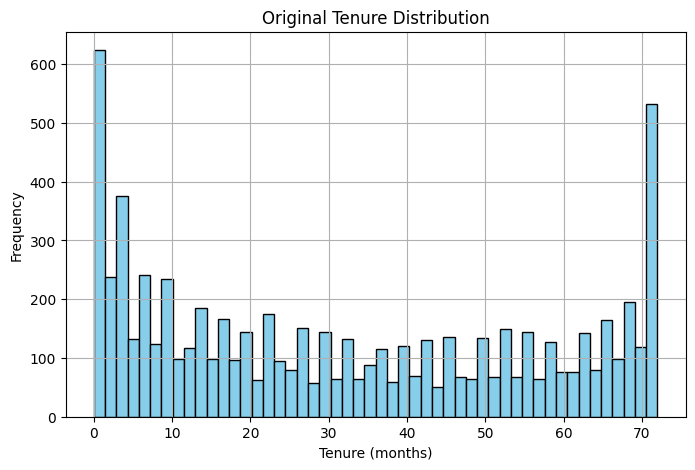

⏳ Processing GMM with 2 components... (1/71)
⏳ Processing GMM with 3 components... (2/71)
⏳ Processing GMM with 4 components... (3/71)
⏳ Processing GMM with 5 components... (4/71)
⏳ Processing GMM with 6 components... (5/71)
⏳ Processing GMM with 7 components... (6/71)
⏳ Processing GMM with 8 components... (7/71)
⏳ Processing GMM with 9 components... (8/71)
⏳ Processing GMM with 10 components... (9/71)
⏳ Processing GMM with 11 components... (10/71)
⏳ Processing GMM with 12 components... (11/71)
⏳ Processing GMM with 13 components... (12/71)
⏳ Processing GMM with 14 components... (13/71)
⏳ Processing GMM with 15 components... (14/71)
⏳ Processing GMM with 16 components... (15/71)
⏳ Processing GMM with 17 components... (16/71)
⏳ Processing GMM with 18 components... (17/71)
⏳ Processing GMM with 19 components... (18/71)
⏳ Processing GMM with 20 components... (19/71)
⏳ Processing GMM with 21 components... (20/71)
⏳ Processing GMM with 22 components... (21/71)
⏳ Processing GMM with 23 compo

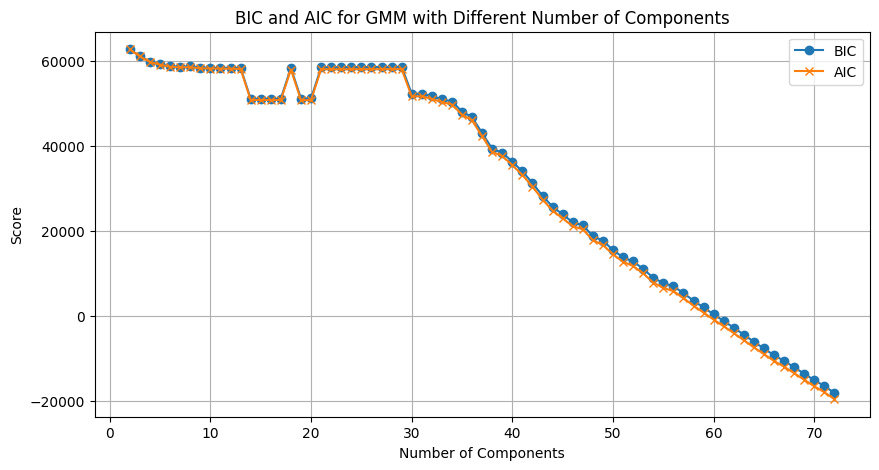

🏆 Best number of components selected based on BIC: 72


/tmp/ipykernel_31/4091315548.py:88: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()      # <-- Adjusts padding to prevent overlap


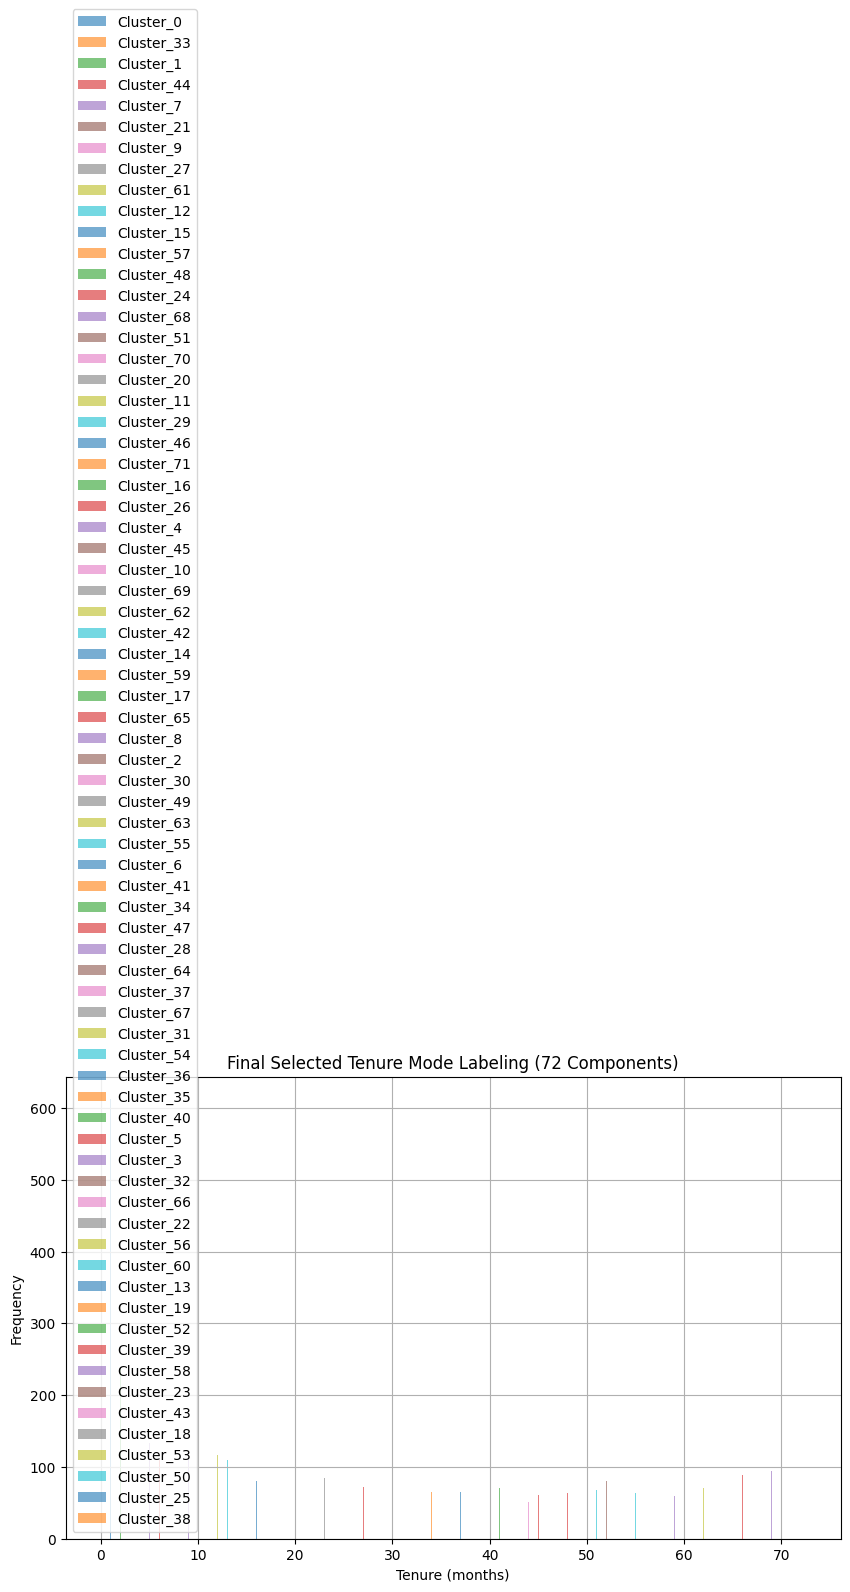

   tenure Tenure_Mode_Label
0       1         Cluster_0
1      34        Cluster_33
2       2         Cluster_1
3      45        Cluster_44
4       2         Cluster_1
5       8         Cluster_7
6      22        Cluster_21
7      10         Cluster_9
8      28        Cluster_27
9      62        Cluster_61


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import time

# Load data
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

# 🔍 Analyze 'tenure'
print(f"Summary of 'tenure':\n{df['tenure'].describe()}")

# 📈 Plot the raw distribution
plt.figure(figsize=(8,5))
plt.hist(df['tenure'], bins=50, color='skyblue', edgecolor='black')
plt.title('Original Tenure Distribution')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# ⚡ Try multiple GMM combinations
components_to_try = list(range(2, 73))  # 2 to 72

bics = []
aics = []
models = []

start_time = time.time()

for idx, n_components in enumerate(components_to_try):
    print(f"⏳ Processing GMM with {n_components} components... ({idx+1}/{len(components_to_try)})")
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(df[['tenure']])

    bic = gmm.bic(df[['tenure']])
    aic = gmm.aic(df[['tenure']])
    
    bics.append(bic)
    aics.append(aic)
    models.append(gmm)

end_time = time.time()
print(f"✅ Finished processing all models in {end_time - start_time:.2f} seconds.")

# 📈 Plot BIC and AIC values
plt.figure(figsize=(10,5))
plt.plot(components_to_try, bics, label='BIC', marker='o')
plt.plot(components_to_try, aics, label='AIC', marker='x')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.title('BIC and AIC for GMM with Different Number of Components')
plt.legend()
plt.grid(True)
plt.show()

# ✅ Automatically Select Best Model (Lowest BIC)
best_n_components = components_to_try[np.argmin(bics)]
best_model = models[np.argmin(bics)]

print(f"🏆 Best number of components selected based on BIC: {best_n_components}")

# 🔥 Build Final Labels using the best model
final_labels = best_model.predict(df[['tenure']])

# 📋 Create human-readable labels
means = best_model.means_.flatten()
sorted_indices = np.argsort(means)

# 📋 Label mapping
if best_n_components == 2:
    mapping = {sorted_indices[0]: 'Short_Tenure', sorted_indices[1]: 'Long_Tenure'}
    df['Tenure_Mode_Label'] = pd.Series(final_labels).map(mapping)
else:
    df['Tenure_Mode_Label'] = pd.Series(final_labels).map({idx: f'Cluster_{i}' for i, idx in enumerate(sorted_indices)})

# 📈 Plot Final Selected Labeling (Fixed Legend Position)
plt.figure(figsize=(10,6))
for label in df['Tenure_Mode_Label'].unique():
    subset = df[df['Tenure_Mode_Label'] == label]
    plt.hist(subset['tenure'], bins=30, alpha=0.6, label=label)

plt.title(f'Final Selected Tenure Mode Labeling ({best_n_components} Components)')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.legend(loc='best')  # <-- Let matplotlib automatically place the legend
plt.grid(True)
plt.tight_layout()      # <-- Adjusts padding to prevent overlap
plt.show()

# 🎯 Quick check
print(df[['tenure', 'Tenure_Mode_Label']].head(10))

# 💾 Optional: Save final dataset
# df.to_csv('dataset_with_tenure_modes_final.csv', index=False)


### GMM-Based Tenure Clustering with Model Selection and Normality Testing

**What this cell does**

This cell models the distribution of the `tenure` feature using **Gaussian Mixture Models (GMM)**, selects the optimal number of components using **BIC**, assigns cluster labels to tenure values, visualizes the clusters, and evaluates whether each cluster follows a normal distribution using the **Shapiro-Wilk test**.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → filtering, labeling, grouping

- `numpy`
  - `argmin()` → selects best model based on BIC
  - `argsort()` → orders clusters based on mean values

- `matplotlib.pyplot`
  - `hist()` → plots distributions
  - `plot()` → visualizes BIC scores
  - figure/axis formatting functions

- `sklearn.mixture`
  - `GaussianMixture()` → fits mixture models
  - `fit()` → trains model on tenure data
  - `bic()` → computes model selection score
  - `predict()` → assigns cluster labels

- `scipy.stats`
  - `shapiro()` → performs Shapiro-Wilk normality test on each cluster

- `time`
  - `time()` → tracks execution time

---

**How it is implemented**

1. Load dataset and display summary statistics for the `tenure` column.
2. Plot the original tenure distribution using a histogram.
3. Define a range of GMM components (2 to 20).
4. For each component count:
   - fit a `GaussianMixture` model on tenure
   - compute and store BIC score
5. Plot BIC values to compare model performance.
6. Select the optimal number of components based on the lowest BIC.
7. Use the best model to predict cluster labels for tenure values.
8. Sort clusters based on their mean values and assign readable labels (`Cluster_0`, `Cluster_1`, etc.).
9. Add the new column `Tenure_Cluster_Label` to the dataframe.
10. Plot density histograms of tenure for each cluster to visualize separation.
11. Perform Shapiro-Wilk normality test on each cluster and print results indicating whether distributions are approximately normal.

Summary of 'tenure':
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


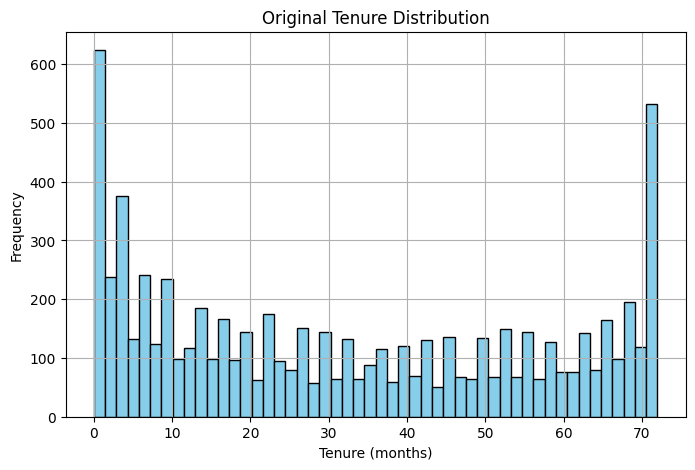

⏳ Fitting GMM with 2 components... (1/19)
⏳ Fitting GMM with 3 components... (2/19)
⏳ Fitting GMM with 4 components... (3/19)
⏳ Fitting GMM with 5 components... (4/19)
⏳ Fitting GMM with 6 components... (5/19)
⏳ Fitting GMM with 7 components... (6/19)
⏳ Fitting GMM with 8 components... (7/19)
⏳ Fitting GMM with 9 components... (8/19)
⏳ Fitting GMM with 10 components... (9/19)
⏳ Fitting GMM with 11 components... (10/19)
⏳ Fitting GMM with 12 components... (11/19)
⏳ Fitting GMM with 13 components... (12/19)
⏳ Fitting GMM with 14 components... (13/19)
⏳ Fitting GMM with 15 components... (14/19)
⏳ Fitting GMM with 16 components... (15/19)
⏳ Fitting GMM with 17 components... (16/19)
⏳ Fitting GMM with 18 components... (17/19)
⏳ Fitting GMM with 19 components... (18/19)
⏳ Fitting GMM with 20 components... (19/19)
✅ Finished processing in 3.65 seconds.


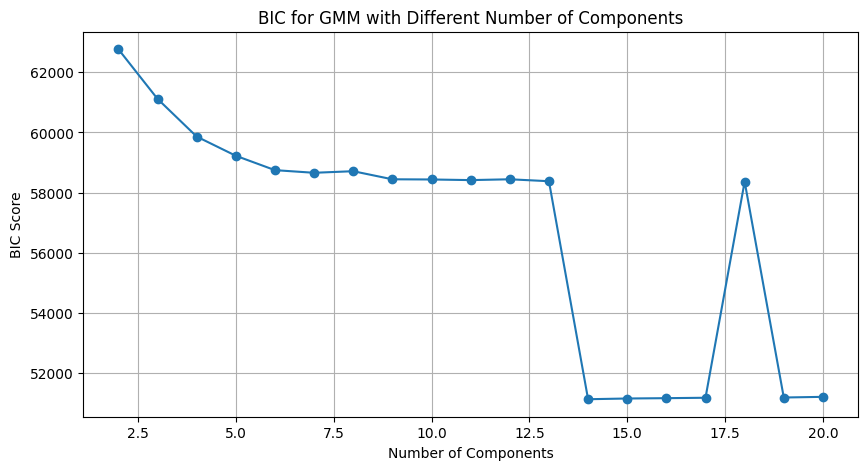

🏆 Best number of components selected based on BIC: 14


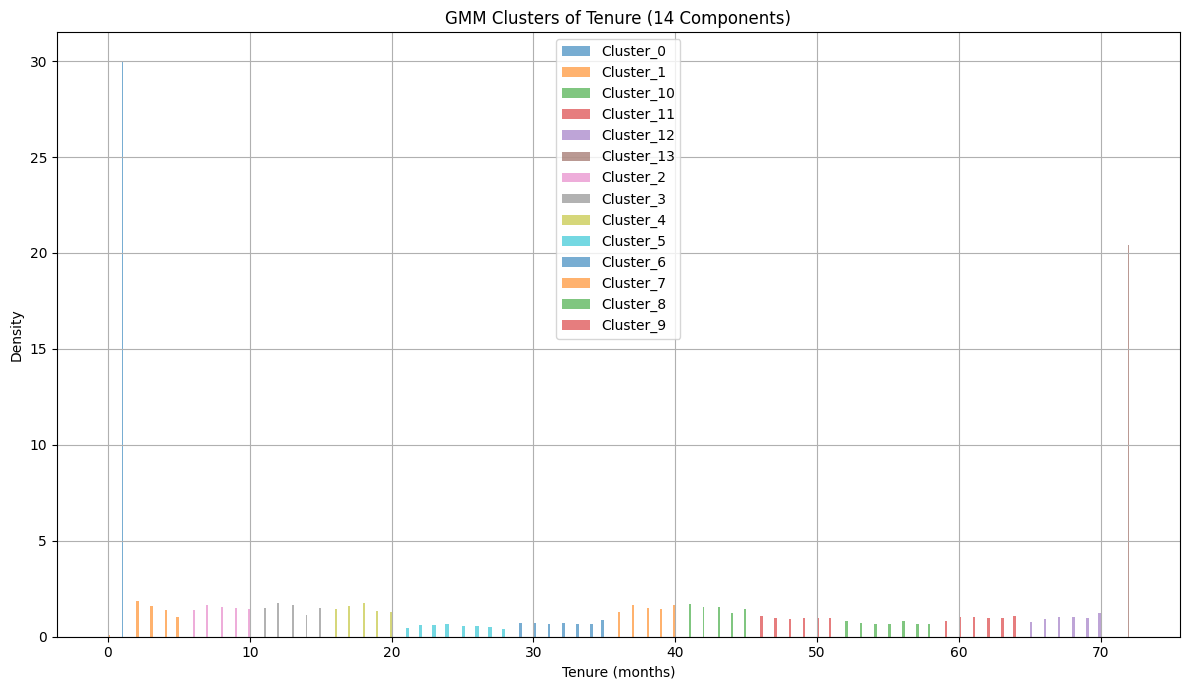


🔍 Normality Test Results (Shapiro-Wilk Test):

📌 Cluster_0: W-statistic = 1.0000, p-value = 1.0000
   -> Likely Normal ✅
📌 Cluster_1: W-statistic = 0.8809, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_10: W-statistic = 0.9149, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_11: W-statistic = 0.9074, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_12: W-statistic = 0.9051, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_13: W-statistic = 0.5874, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_2: W-statistic = 0.8926, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_3: W-statistic = 0.8874, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_4: W-statistic = 0.8964, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_5: W-statistic = 0.9373, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_6: W-statistic = 0.9076, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_7: W-statistic = 0.8891, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_8: W-s

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import shapiro
import time

# Load the dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

# Analyze 'tenure'
print(f"Summary of 'tenure':\n{df['tenure'].describe()}")

# Plot raw distribution
plt.figure(figsize=(8,5))
plt.hist(df['tenure'], bins=50, color='skyblue', edgecolor='black')
plt.title('Original Tenure Distribution')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Try multiple GMM combinations to find best fit
components_to_try = list(range(2, 21))  # Reasonable range 2-20

bics = []
models = []

start_time = time.time()

for idx, n_components in enumerate(components_to_try):
    print(f"⏳ Fitting GMM with {n_components} components... ({idx+1}/{len(components_to_try)})")
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(df[['tenure']])

    bic = gmm.bic(df[['tenure']])
    bics.append(bic)
    models.append(gmm)

end_time = time.time()
print(f"✅ Finished processing in {end_time - start_time:.2f} seconds.")

# Plot BIC
plt.figure(figsize=(10,5))
plt.plot(components_to_try, bics, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('BIC Score')
plt.title('BIC for GMM with Different Number of Components')
plt.grid(True)
plt.show()

# Select best model
best_n_components = components_to_try[np.argmin(bics)]
best_model = models[np.argmin(bics)]

print(f"🏆 Best number of components selected based on BIC: {best_n_components}")

# Predict cluster labels
final_labels = best_model.predict(df[['tenure']])

# Create readable cluster labels
means = best_model.means_.flatten()
sorted_indices = np.argsort(means)
label_mapping = {idx: f'Cluster_{i}' for i, idx in enumerate(sorted_indices)}
df['Tenure_Cluster_Label'] = pd.Series(final_labels).map(label_mapping)

# Plot clusters separately
plt.figure(figsize=(12,7))
for label in sorted(df['Tenure_Cluster_Label'].unique()):
    subset = df[df['Tenure_Cluster_Label'] == label]
    plt.hist(subset['tenure'], bins=30, alpha=0.6, label=label, density=True)

plt.title(f'GMM Clusters of Tenure ({best_n_components} Components)')
plt.xlabel('Tenure (months)')
plt.ylabel('Density')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# Test normality for each cluster
print("\n🔍 Normality Test Results (Shapiro-Wilk Test):\n")
for label in sorted(df['Tenure_Cluster_Label'].unique()):
    subset = df[df['Tenure_Cluster_Label'] == label]['tenure']
    stat, p_value = shapiro(subset)
    print(f"📌 {label}: W-statistic = {stat:.4f}, p-value = {p_value:.4f}")
    if p_value > 0.05:
        print("   -> Likely Normal ✅")
    else:
        print("   -> Likely NOT Normal ❌")



### Generic GMM-Based Analysis Function for Numerical Features (TotalCharges & MonthlyCharges)

**What this cell does**

This cell defines a reusable function to analyze numerical columns using **Gaussian Mixture Models (GMM)**. It applies this function to `TotalCharges` and `MonthlyCharges` to:
- find optimal number of clusters using BIC  
- assign cluster labels  
- visualize distributions per cluster  
- test normality of each cluster  

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → cleaning, column creation, indexing

- `numpy`
  - `argmin()` → selects best GMM model (lowest BIC)
  - `argsort()` → orders clusters based on means

- `matplotlib.pyplot`
  - `hist()` → plots feature distributions and cluster-wise distributions
  - `plot()` → visualizes BIC scores
  - figure formatting functions

- `sklearn.mixture`
  - `GaussianMixture()` → fits mixture models
  - `fit()` → trains model
  - `bic()` → computes model selection score
  - `predict()` → assigns cluster labels

- `scipy.stats`
  - `shapiro()` → performs Shapiro-Wilk normality test per cluster

- `time`
  - `time()` → tracks execution duration

---

**How it is implemented**

1. Load dataset and clean column names using `str.strip()`.
2. Preprocess `TotalCharges` by replacing blanks with `NaN` and converting to float.
3. Define function `analyze_column_gmm(df, column_name, n_components_range)`:
   - prints summary statistics of the column
   - plots original distribution
   - iterates over a range of GMM components:
     - fits `GaussianMixture` on non-null values
     - computes BIC scores
   - plots BIC vs number of components
   - selects best model using lowest BIC
   - predicts cluster labels for the column
   - sorts clusters based on their mean values
   - maps clusters to ordered labels (`Cluster_0`, `Cluster_1`, ...)
   - adds new column `<column_name>_Cluster_Label` to dataframe
   - plots cluster-wise distributions
   - performs Shapiro-Wilk test for each cluster and prints results
4. Apply the function separately to:
   - `TotalCharges`
   - `MonthlyCharges`
5. Return updated dataframe with new cluster label columns for both features.



================== Analyzing 'TotalCharges' ==================

Summary of 'TotalCharges':
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


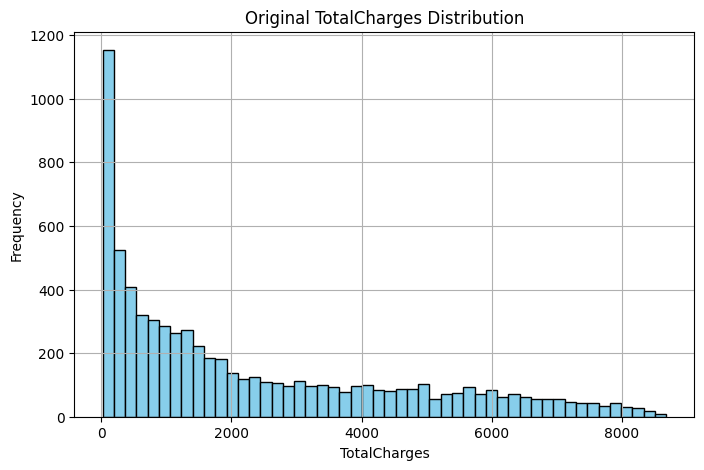

⏳ Fitting GMM with 2 components... (1/19)
⏳ Fitting GMM with 3 components... (2/19)
⏳ Fitting GMM with 4 components... (3/19)
⏳ Fitting GMM with 5 components... (4/19)
⏳ Fitting GMM with 6 components... (5/19)
⏳ Fitting GMM with 7 components... (6/19)
⏳ Fitting GMM with 8 components... (7/19)
⏳ Fitting GMM with 9 components... (8/19)
⏳ Fitting GMM with 10 components... (9/19)
⏳ Fitting GMM with 11 components... (10/19)
⏳ Fitting GMM with 12 components... (11/19)
⏳ Fitting GMM with 13 components... (12/19)
⏳ Fitting GMM with 14 components... (13/19)
⏳ Fitting GMM with 15 components... (14/19)
⏳ Fitting GMM with 16 components... (15/19)
⏳ Fitting GMM with 17 components... (16/19)
⏳ Fitting GMM with 18 components... (17/19)
⏳ Fitting GMM with 19 components... (18/19)
⏳ Fitting GMM with 20 components... (19/19)
✅ Finished processing in 2.31 seconds.


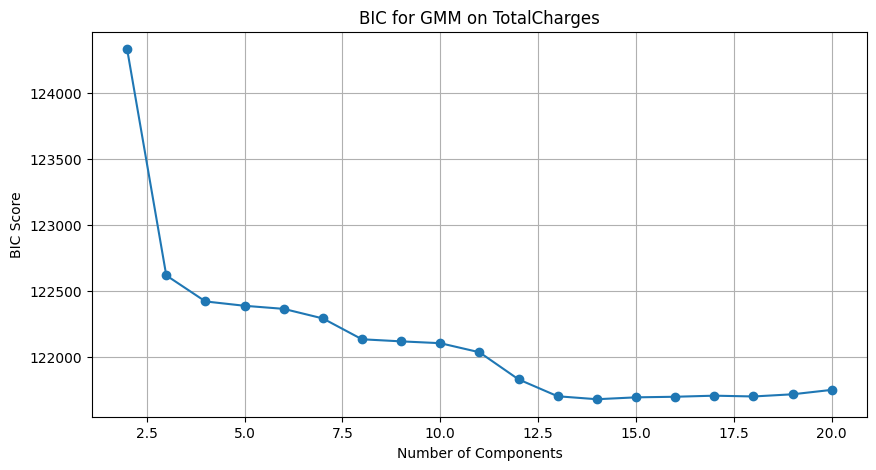


🏆 Best number of components selected based on BIC for 'TotalCharges': 14


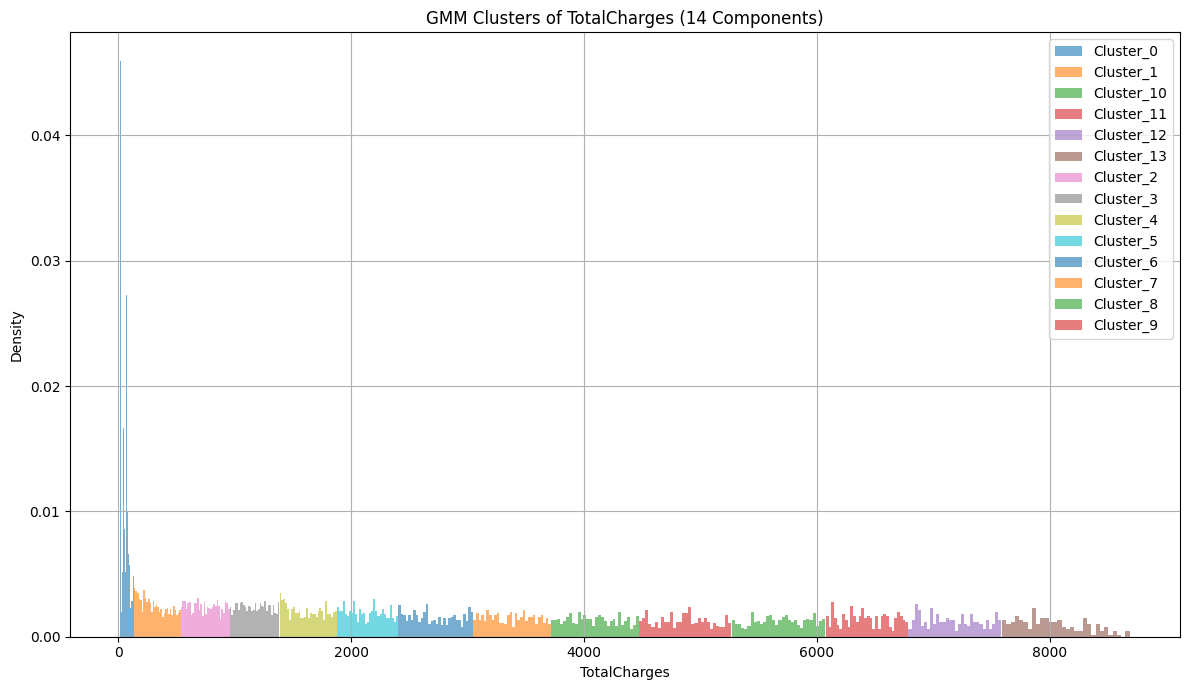


🔍 Normality Test Results (Shapiro-Wilk Test):

📌 Cluster_0: W-statistic = 0.9499, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_1: W-statistic = 0.9456, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_10: W-statistic = 0.9617, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_11: W-statistic = 0.9560, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_12: W-statistic = 0.9468, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_13: W-statistic = 0.9567, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_2: W-statistic = 0.9526, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_3: W-statistic = 0.9565, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_4: W-statistic = 0.9402, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_5: W-statistic = 0.9512, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_6: W-statistic = 0.9438, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_7: W-statistic = 0.9524, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_8:

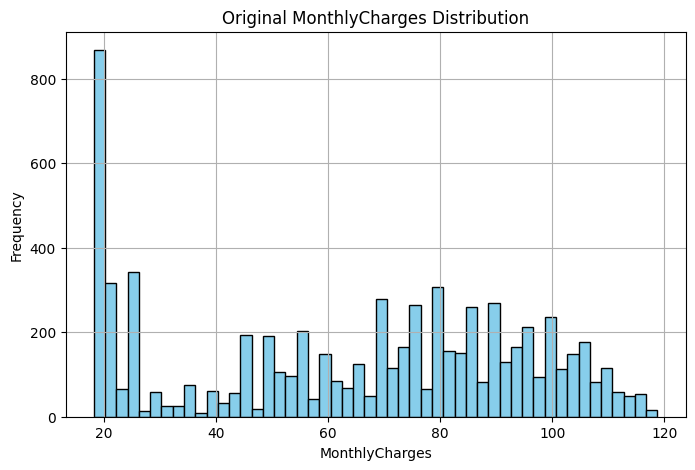

⏳ Fitting GMM with 2 components... (1/19)
⏳ Fitting GMM with 3 components... (2/19)
⏳ Fitting GMM with 4 components... (3/19)
⏳ Fitting GMM with 5 components... (4/19)
⏳ Fitting GMM with 6 components... (5/19)
⏳ Fitting GMM with 7 components... (6/19)
⏳ Fitting GMM with 8 components... (7/19)
⏳ Fitting GMM with 9 components... (8/19)
⏳ Fitting GMM with 10 components... (9/19)
⏳ Fitting GMM with 11 components... (10/19)
⏳ Fitting GMM with 12 components... (11/19)
⏳ Fitting GMM with 13 components... (12/19)
⏳ Fitting GMM with 14 components... (13/19)
⏳ Fitting GMM with 15 components... (14/19)
⏳ Fitting GMM with 16 components... (15/19)
⏳ Fitting GMM with 17 components... (16/19)
⏳ Fitting GMM with 18 components... (17/19)
⏳ Fitting GMM with 19 components... (18/19)
⏳ Fitting GMM with 20 components... (19/19)
✅ Finished processing in 1.64 seconds.


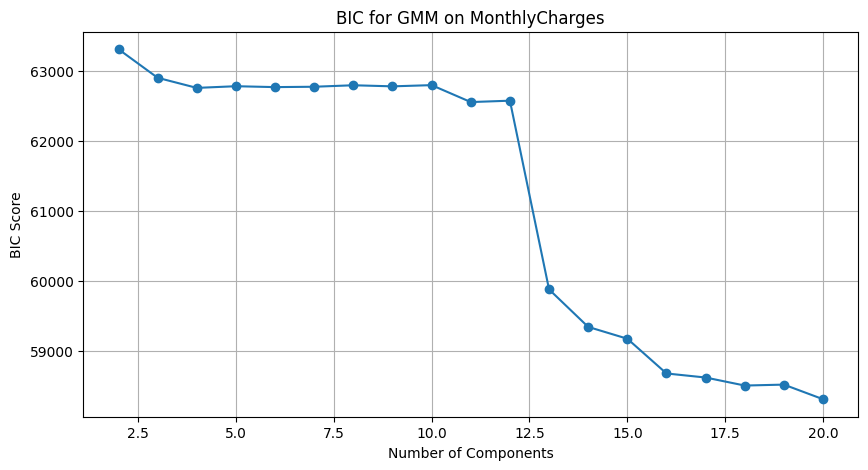


🏆 Best number of components selected based on BIC for 'MonthlyCharges': 20


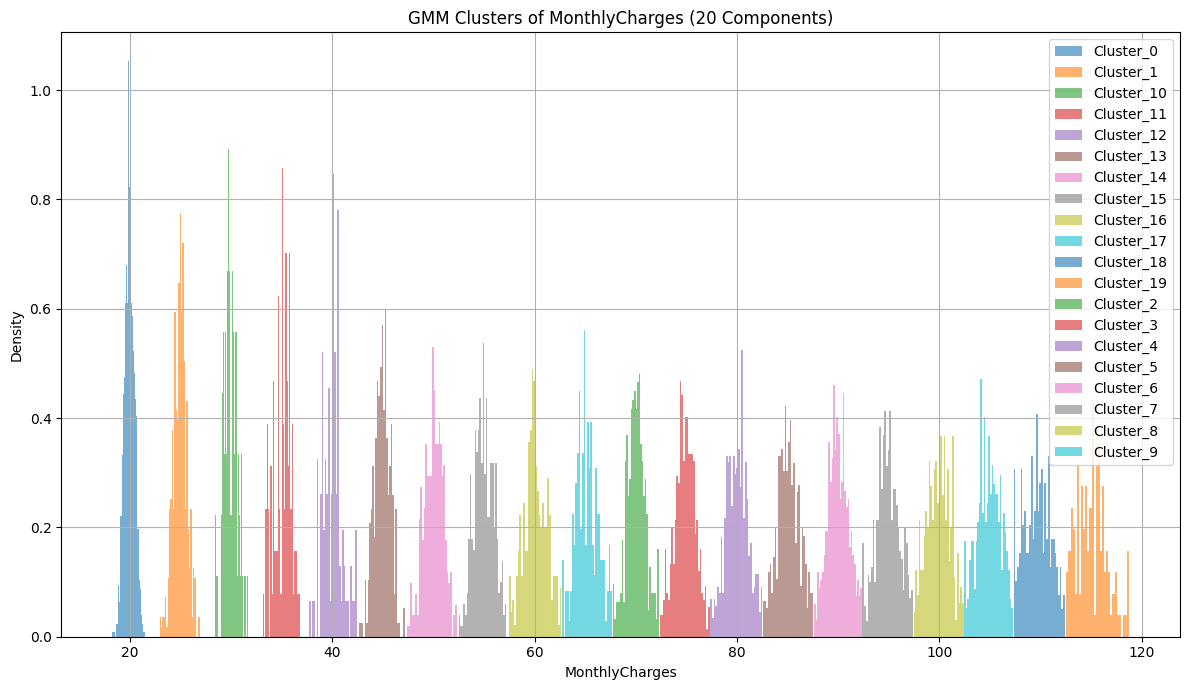


🔍 Normality Test Results (Shapiro-Wilk Test):

📌 Cluster_0: W-statistic = 0.9975, p-value = 0.0662
   -> Likely Normal ✅
📌 Cluster_1: W-statistic = 0.9969, p-value = 0.6091
   -> Likely Normal ✅
📌 Cluster_10: W-statistic = 0.9940, p-value = 0.1016
   -> Likely Normal ✅
📌 Cluster_11: W-statistic = 0.9948, p-value = 0.1312
   -> Likely Normal ✅
📌 Cluster_12: W-statistic = 0.9941, p-value = 0.0448
   -> Likely NOT Normal ❌
📌 Cluster_13: W-statistic = 0.9922, p-value = 0.0177
   -> Likely NOT Normal ❌
📌 Cluster_14: W-statistic = 0.9922, p-value = 0.0246
   -> Likely NOT Normal ❌
📌 Cluster_15: W-statistic = 0.9890, p-value = 0.0027
   -> Likely NOT Normal ❌
📌 Cluster_16: W-statistic = 0.9873, p-value = 0.0015
   -> Likely NOT Normal ❌
📌 Cluster_17: W-statistic = 0.9846, p-value = 0.0007
   -> Likely NOT Normal ❌
📌 Cluster_18: W-statistic = 0.9767, p-value = 0.0007
   -> Likely NOT Normal ❌
📌 Cluster_19: W-statistic = 0.9720, p-value = 0.0116
   -> Likely NOT Normal ❌
📌 Cluster_2: W-statist

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import shapiro
import time

# Load the dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

# Clean column names (sometimes needed)
df.columns = df.columns.str.strip()

# 🧹 Special Cleaning for 'TotalCharges' — replace blank spaces with NaN and convert to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

def analyze_column_gmm(df, column_name, n_components_range=(2, 21)):
    print(f"\n\n================== Analyzing '{column_name}' ==================\n")

    # 🔎 Analyze column
    print(f"Summary of '{column_name}':\n{df[column_name].describe()}")

    # 📈 Plot raw distribution
    plt.figure(figsize=(8,5))
    plt.hist(df[column_name].dropna(), bins=50, color='skyblue', edgecolor='black')
    plt.title(f'Original {column_name} Distribution')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    # ⚡ Try multiple GMM combinations
    components_to_try = list(range(*n_components_range))

    bics = []
    models = []

    start_time = time.time()

    for idx, n_components in enumerate(components_to_try):
        print(f"⏳ Fitting GMM with {n_components} components... ({idx+1}/{len(components_to_try)})")
        gmm = GaussianMixture(n_components=n_components, random_state=42)
        gmm.fit(df[[column_name]].dropna())

        bic = gmm.bic(df[[column_name]].dropna())
        bics.append(bic)
        models.append(gmm)

    end_time = time.time()
    print(f"✅ Finished processing in {end_time - start_time:.2f} seconds.")

    # 📈 Plot BIC
    plt.figure(figsize=(10,5))
    plt.plot(components_to_try, bics, marker='o')
    plt.xlabel('Number of Components')
    plt.ylabel('BIC Score')
    plt.title(f'BIC for GMM on {column_name}')
    plt.grid(True)
    plt.show()

    # 🏆 Select best model
    best_n_components = components_to_try[np.argmin(bics)]
    best_model = models[np.argmin(bics)]

    print(f"\n🏆 Best number of components selected based on BIC for '{column_name}': {best_n_components}")

    # 🔥 Predict cluster labels
    final_labels = best_model.predict(df[[column_name]].dropna())

    # 📋 Create readable cluster labels
    means = best_model.means_.flatten()
    sorted_indices = np.argsort(means)
    label_mapping = {idx: f'Cluster_{i}' for i, idx in enumerate(sorted_indices)}
    
    # Create a new column for cluster labels (align indexes)
    temp_labels = pd.Series(final_labels, index=df[[column_name]].dropna().index)
    df[f'{column_name}_Cluster_Label'] = temp_labels.map(label_mapping)

    # 📈 Plot clusters separately
    plt.figure(figsize=(12,7))
    for label in sorted(df[f'{column_name}_Cluster_Label'].dropna().unique()):
        subset = df[df[f'{column_name}_Cluster_Label'] == label]
        plt.hist(subset[column_name], bins=30, alpha=0.6, label=label, density=True)

    plt.title(f'GMM Clusters of {column_name} ({best_n_components} Components)')
    plt.xlabel(column_name)
    plt.ylabel('Density')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 🔍 Test normality for each cluster
    print("\n🔍 Normality Test Results (Shapiro-Wilk Test):\n")
    for label in sorted(df[f'{column_name}_Cluster_Label'].dropna().unique()):
        subset = df[df[f'{column_name}_Cluster_Label'] == label][column_name]
        stat, p_value = shapiro(subset)
        print(f"📌 {label}: W-statistic = {stat:.4f}, p-value = {p_value:.4f}")
        if p_value > 0.05:
            print("   -> Likely Normal ✅")
        else:
            print("   -> Likely NOT Normal ❌")
    
    return df

# ===============================
# 🔥 Now apply it to 'TotalCharges' and 'MonthlyCharges'
# ===============================

# Analyze TotalCharges
df = analyze_column_gmm(df, 'TotalCharges')

# Analyze MonthlyCharges
df = analyze_column_gmm(df, 'MonthlyCharges')


### GMM-Based Fixed Clustering of MonthlyCharges (10 Components) with Normality Testing

**What this cell does**

This cell analyzes the `MonthlyCharges` feature by fitting a **Gaussian Mixture Model (GMM) with a fixed 10 clusters**, assigns cluster labels, visualizes the cluster-wise distributions, and evaluates whether each cluster follows a normal distribution using the **Shapiro-Wilk test**.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → cleaning, column creation, indexing

- `numpy`
  - `argsort()` → orders clusters based on GMM component means

- `matplotlib.pyplot`
  - `hist()` → plots raw and cluster-wise distributions
  - figure formatting functions → styling and layout

- `sklearn.mixture`
  - `GaussianMixture()` → fits mixture model with fixed number of components
  - `fit()` → trains model
  - `predict()` → assigns cluster labels

- `scipy.stats`
  - `shapiro()` → performs Shapiro-Wilk normality test

- `time`
  - `time()` → measures model fitting time

---

**How it is implemented**

1. Load dataset and clean column names using `str.strip()`.
2. Preprocess `TotalCharges` by replacing blanks with `NaN` and converting to float (not directly used here).
3. Select `MonthlyCharges` as the feature for analysis.
4. Print summary statistics and plot the original distribution.
5. Fit a `GaussianMixture` model with **10 components** on non-null values of `MonthlyCharges`.
6. Predict cluster labels for each data point.
7. Sort GMM components based on their mean values and map them to ordered labels (`Cluster_0` to `Cluster_9`).
8. Add a new column `MonthlyCharges_Cluster_Label` to store cluster assignments.
9. Plot separate histograms for each cluster to visualize distribution differences.
10. Perform Shapiro-Wilk test for each cluster (if sample size ≥ 3) to check for normality and print results.



================== Analyzing 'MonthlyCharges' with 10 clusters ==================

Summary of 'MonthlyCharges':
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


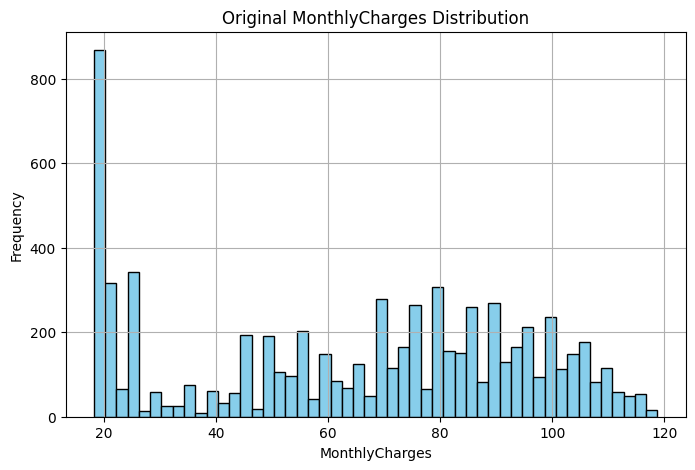

✅ Fitted GMM in 0.04 seconds.


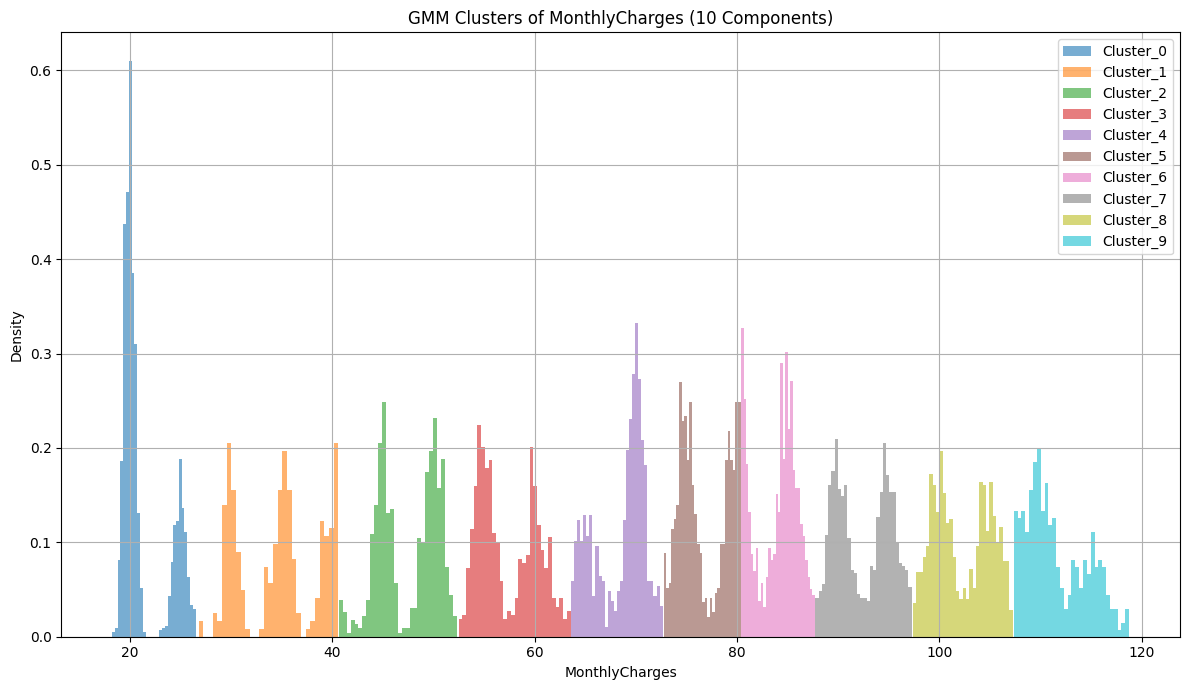


🔍 Normality Test Results (Shapiro-Wilk Test):

📌 Cluster_0: W-statistic = 0.7566, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_1: W-statistic = 0.9168, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_2: W-statistic = 0.9127, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_3: W-statistic = 0.9209, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_4: W-statistic = 0.8964, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_5: W-statistic = 0.8966, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_6: W-statistic = 0.9239, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_7: W-statistic = 0.9256, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_8: W-statistic = 0.9344, p-value = 0.0000
   -> Likely NOT Normal ❌
📌 Cluster_9: W-statistic = 0.9319, p-value = 0.0000
   -> Likely NOT Normal ❌


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import shapiro
import time

# Load the dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

# Clean column names
df.columns = df.columns.str.strip()

# 🧹 Special Cleaning for 'TotalCharges' — (we don't need it for MonthlyCharges)
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

# ===============================
# 🔥 Analyze MonthlyCharges with 10 GMM clusters
# ===============================

column_name = 'MonthlyCharges'
n_components = 10

print(f"\n\n================== Analyzing '{column_name}' with {n_components} clusters ==================\n")

# 🔎 Analyze column
print(f"Summary of '{column_name}':\n{df[column_name].describe()}")

# 📈 Plot raw distribution
plt.figure(figsize=(8,5))
plt.hist(df[column_name].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title(f'Original {column_name} Distribution')
plt.xlabel(column_name)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# ⚡ Fit GMM directly
start_time = time.time()

gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm.fit(df[[column_name]].dropna())

end_time = time.time()
print(f"✅ Fitted GMM in {end_time - start_time:.2f} seconds.")

# 🔥 Predict cluster labels
final_labels = gmm.predict(df[[column_name]].dropna())

# 📋 Create readable cluster labels
means = gmm.means_.flatten()
sorted_indices = np.argsort(means)
label_mapping = {idx: f'Cluster_{i}' for i, idx in enumerate(sorted_indices)}

# Create a new column for cluster labels (align indexes)
temp_labels = pd.Series(final_labels, index=df[[column_name]].dropna().index)
df[f'{column_name}_Cluster_Label'] = temp_labels.map(label_mapping)

# 📈 Plot clusters separately
plt.figure(figsize=(12,7))
for label in sorted(df[f'{column_name}_Cluster_Label'].dropna().unique()):
    subset = df[df[f'{column_name}_Cluster_Label'] == label]
    plt.hist(subset[column_name], bins=30, alpha=0.6, label=label, density=True)

plt.title(f'GMM Clusters of {column_name} (10 Components)')
plt.xlabel(column_name)
plt.ylabel('Density')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔍 Test normality for each cluster
print("\n🔍 Normality Test Results (Shapiro-Wilk Test):\n")
for label in sorted(df[f'{column_name}_Cluster_Label'].dropna().unique()):
    subset = df[df[f'{column_name}_Cluster_Label'] == label][column_name]
    if len(subset) >= 3:  # Shapiro-Wilk requires at least 3 samples
        stat, p_value = shapiro(subset)
        print(f"📌 {label}: W-statistic = {stat:.4f}, p-value = {p_value:.4f}")
        if p_value > 0.05:
            print("   -> Likely Normal ✅")
        else:
            print("   -> Likely NOT Normal ❌")
    else:
        print(f"📌 {label}: Not enough data to perform Shapiro-Wilk test.")


### LightGBM Training with Early Stopping and ROC Curve Evaluation (Reduced Feature Set)

**What this cell does**

This cell trains a **LightGBM binary classification model** to predict churn after dropping selected features, evaluates its performance using multiple metrics, and visualizes model performance using an **ROC curve**.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → cleaning, column dropping, feature/target separation

- `numpy`
  - used for thresholding predictions (`> 0.5`)

- `lightgbm`
  - `Dataset()` → prepares data for LightGBM training
  - `train()` → trains model with specified parameters
  - `early_stopping()` → stops training when validation performance stops improving
  - `log_evaluation()` → logs training progress

- `sklearn.model_selection`
  - `train_test_split()` → splits data into train/test sets with stratification

- `sklearn.preprocessing`
  - `LabelEncoder()` → encodes categorical features and target labels

- `sklearn.metrics`
  - `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()` → classification metrics
  - `roc_auc_score()` → evaluates probability predictions
  - `confusion_matrix()` → shows prediction breakdown
  - `classification_report()` → detailed performance summary
  - `roc_curve()` → computes ROC curve values

- `matplotlib.pyplot`
  - `plot()` → plots ROC curve
  - figure formatting functions

---

**How it is implemented**

1. Load dataset and clean column names using `str.strip()`.
2. Clean `TotalCharges` (replace blanks with `NaN`, convert to float).
3. Drop columns: `customerID`, `tenure`, and `TotalCharges`.
4. Split dataset into features (`X`) and target (`y = Churn`).
5. Identify categorical features (all except `MonthlyCharges`) and encode them using `LabelEncoder`.
6. Split data into training and testing sets using `train_test_split()` with stratification.
7. Encode target labels (`Churn`) into binary values.
8. Create LightGBM datasets using `lgb.Dataset`.
9. Define model parameters (binary objective, AUC metric, learning rate, tree parameters).
10. Train model using `lgb.train()` with:
    - up to 1000 boosting rounds
    - early stopping (50 rounds)
    - periodic logging
11. Generate prediction probabilities and convert them to class labels using a 0.5 threshold.
12. Compute evaluation metrics: accuracy, precision, recall, F1 score, ROC-AUC, confusion matrix, and classification report.
13. Compute ROC curve (`fpr`, `tpr`) and plot it along with AUC score to visualize model performance.

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[43]	training's binary_logloss: 0.405221	training's auc: 0.865892	valid_1's binary_logloss: 0.448625	valid_1's auc: 0.817229

=================== Model Performance Metrics ===================
Accuracy : 0.7743
Precision: 0.5966
Recall   : 0.4626
F1 Score : 0.5211
AUC Score: 0.8172

Confusion Matrix:
[[918 117]
 [201 173]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.46      0.52       374

    accuracy                           0.77      1409
   macro avg       0.71      0.67      0.69      1409
weighted avg       0.76      0.77      0.76      1409



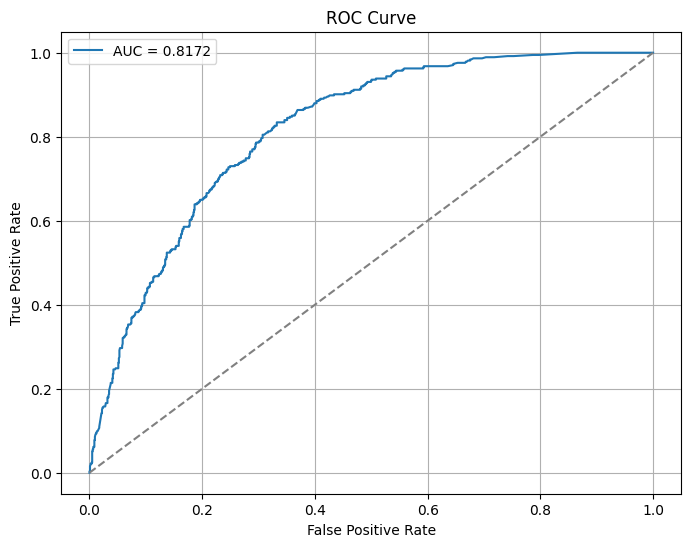

In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

# Load the dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Clean 'TotalCharges' (even if we drop it later)
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Drop unwanted columns
df = df.drop(columns=['customerID', 'tenure', 'TotalCharges'])

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identify categorical columns (except 'MonthlyCharges')
categorical_cols = X.columns.drop('MonthlyCharges')

# Label encode categorical variables
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode target labels
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# Create LGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Set parameters
params = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'boosting': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42
}

# Train model with callbacks
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

# Predict
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = (y_pred_prob > 0.5).astype(int)

# ====================
# 📋 Model Evaluation
# ====================

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
# Precision
precision = precision_score(y_test, y_pred)
# Recall
recall = recall_score(y_test, y_pred)
# F1 Score
f1 = f1_score(y_test, y_pred)
# AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Print all metrics
print("\n=================== Model Performance Metrics ===================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC Score: {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# ====================
# 📈 Plot ROC Curve
# ====================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()



=================== Feature Importance (by % contribution) ===================

             Feature    Importance  Importance_Percent
0           Contract  11098.431927           55.399047
1     MonthlyCharges   2329.621065           11.628560
2     OnlineSecurity   2061.002832           10.287723
3    InternetService    939.143594            4.687839
4      PaymentMethod    797.555873            3.981088
5        TechSupport    639.823534            3.193750
6       OnlineBackup    485.848599            2.425167
7    StreamingMovies    342.728670            1.710768
8             gender    307.405850            1.534450
9   PaperlessBilling    286.855842            1.431873
10  DeviceProtection    189.429690            0.945559
11        Dependents    167.899290            0.838088
12           Partner    154.363369            0.770522
13     SeniorCitizen     83.615420            0.417376
14     MultipleLines     83.440850            0.416504
15       StreamingTV     42.131690     

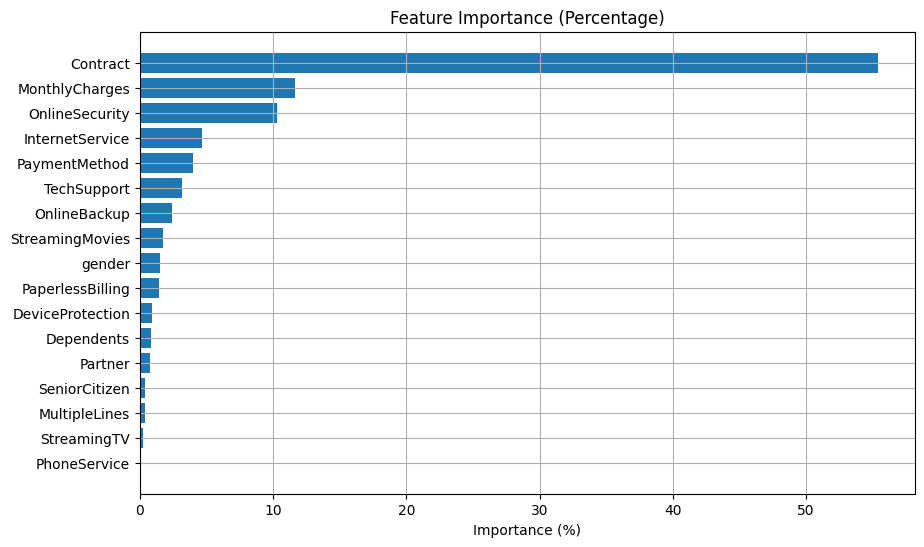

In [6]:
# ====================
# 📈 Feature Importance
# ====================

# Get feature importance (gain-based)
importance = model.feature_importance(importance_type='gain')
feature_names = model.feature_name()

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Convert importance to percentage
feature_importance_df['Importance_Percent'] = 100 * feature_importance_df['Importance'] / feature_importance_df['Importance'].sum()

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance_Percent', ascending=False).reset_index(drop=True)

# Print
print("\n=================== Feature Importance (by % contribution) ===================\n")
print(feature_importance_df)

# (Optional) Plot Feature Importance
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance_Percent'])
plt.gca().invert_yaxis()
plt.xlabel('Importance (%)')
plt.title('Feature Importance (Percentage)')
plt.grid(True)
plt.show()


### GMM-Based Discretization of Numerical Features + LightGBM Classification

**What this cell does**

This cell converts numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) into **categorical clusters using Gaussian Mixture Models (GMM)**, then trains a **LightGBM classifier** on the transformed dataset and evaluates its performance using standard classification metrics and an ROC curve.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → cleaning, column transformation, feature engineering

- `numpy`
  - `argmin()` → selects optimal GMM model (lowest BIC)

- `sklearn.mixture`
  - `GaussianMixture()` → fits mixture models for feature clustering
  - `fit()` → trains GMM
  - `bic()` → evaluates model fit
  - `predict()` → assigns cluster labels

- `sklearn.preprocessing`
  - `LabelEncoder()` → encodes categorical features and target

- `sklearn.model_selection`
  - `train_test_split()` → splits dataset into train/test sets

- `lightgbm`
  - `Dataset()` → prepares data
  - `train()` → trains model with boosting
  - `early_stopping()` → stops training early
  - `log_evaluation()` → logs progress

- `sklearn.metrics`
  - `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()` → performance metrics
  - `roc_auc_score()` → evaluates probability predictions
  - `confusion_matrix()`, `classification_report()` → detailed evaluation
  - `roc_curve()` → computes ROC curve

- `matplotlib.pyplot`
  - `plot()` → plots ROC curve

- `warnings`
  - `filterwarnings('ignore')` → suppresses warnings

---

**How it is implemented**

1. Load dataset, clean column names, and preprocess `TotalCharges` (handle blanks and convert to float).
2. Drop `customerID` column.
3. Define numerical features: `tenure`, `MonthlyCharges`, `TotalCharges`.
4. Define helper function `gmm_cluster_feature()`:
   - fits multiple GMMs (2 to max components)
   - selects best model using lowest BIC
   - predicts cluster labels
   - returns cluster assignments and optimal number of clusters
5. For each numerical feature:
   - apply GMM clustering
   - create new categorical feature `<feature>_cluster`
6. Drop original numerical columns (fully converting dataset to categorical form).
7. Separate features (`X`) and target (`y`).
8. Encode all features and target using `LabelEncoder`.
9. Split dataset into training and testing sets with stratification.
10. Create LightGBM datasets and define model parameters.
11. Train model using `lgb.train()` with early stopping and logging.
12. Generate prediction probabilities and convert to class labels using threshold (0.5).
13. Compute evaluation metrics: accuracy, precision, recall, F1 score, ROC-AUC, confusion matrix, and classification report.
14. Plot ROC curve using predicted probabilities to visualize model performance.


🔵 Processing feature: tenure
✅ Best number of GMM clusters for tenure: 14

🔵 Processing feature: MonthlyCharges
✅ Best number of GMM clusters for MonthlyCharges: 15

🔵 Processing feature: TotalCharges
✅ Best number of GMM clusters for TotalCharges: 14
Training until validation scores don't improve for 50 rounds
[100]	training's binary_logloss: 0.342534	training's auc: 0.909405	valid_1's binary_logloss: 0.420701	valid_1's auc: 0.840179
Early stopping, best iteration is:
[91]	training's binary_logloss: 0.348036	training's auc: 0.905642	valid_1's binary_logloss: 0.420283	valid_1's auc: 0.840332

=================== Model Performance Metrics ===================
Accuracy : 0.7956
Precision: 0.6514
Recall   : 0.4947
F1 Score : 0.5623
AUC Score: 0.8403

Confusion Matrix:
[[936  99]
 [189 185]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1035
       Churn       0.65      0.49      0.56       374

    accuracy 

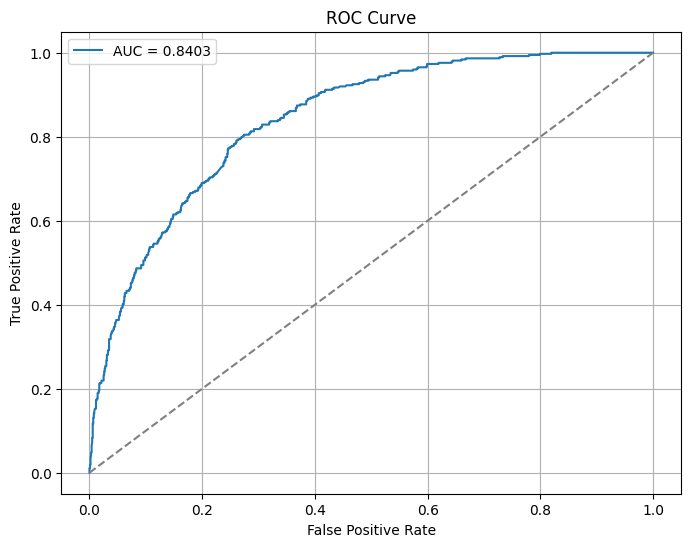

In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Clean TotalCharges (some missing spaces)
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Drop customerID
df = df.drop(columns=['customerID'])

# Numerical features to transform
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Helper function to GMM-cluster one feature
def gmm_cluster_feature(df, feature, max_components=15):
    # Drop missing
    feature_data = df[[feature]].dropna()

    # Try GMM for different numbers of components
    bics = []
    models = []
    for n in range(2, max_components+1):
        gmm = GaussianMixture(n_components=n, random_state=42)
        gmm.fit(feature_data)
        bic = gmm.bic(feature_data)
        bics.append(bic)
        models.append(gmm)

    # Select best model
    best_n = np.argmin(bics) + 2
    best_gmm = models[np.argmin(bics)]

    # Predict clusters
    cluster_labels = best_gmm.predict(feature_data)

    # Map back to original df
    cluster_series = pd.Series(cluster_labels, index=feature_data.index, name=f'{feature}_cluster')

    return cluster_series, best_n

# Transform each numerical feature
for feature in numerical_features:
    print(f"\n🔵 Processing feature: {feature}")
    cluster_labels, best_n = gmm_cluster_feature(df, feature)
    print(f"✅ Best number of GMM clusters for {feature}: {best_n}")
    df[f'{feature}_cluster'] = cluster_labels

# Now drop original numerical features
df = df.drop(columns=numerical_features)

# Now all features are categorical
X = df.drop(columns=['Churn'])
y = df['Churn']

# Encode all features
le = LabelEncoder()
for col in X.columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Encode target
y = le.fit_transform(y)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create LGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Set parameters
params = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'boosting': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42
}

# Train model with callbacks
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

# Predict
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = (y_pred_prob > 0.5).astype(int)

# ====================
# 📋 Model Evaluation
# ====================

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print metrics
print("\n=================== Model Performance Metrics ===================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC Score: {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


### Large-Search GMM-Based Discretization of Numerical Features + LightGBM Classification

**What this cell does**

This cell converts numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) into categorical clusters using **Gaussian Mixture Models (GMM)** with an extensive search over possible cluster sizes, then trains a **LightGBM classifier** on the transformed data and evaluates its performance.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → cleaning, feature transformation, column handling

- `numpy`
  - `argmin()` → selects optimal GMM model based on BIC

- `sklearn.mixture`
  - `GaussianMixture()` → fits mixture models
  - `fit()` → trains GMM
  - `bic()` → evaluates model quality
  - `predict()` → assigns cluster labels

- `sklearn.preprocessing`
  - `LabelEncoder()` → encodes categorical features and target

- `sklearn.model_selection`
  - `train_test_split()` → splits dataset into train/test sets

- `lightgbm`
  - `Dataset()` → prepares data for training
  - `train()` → trains model
  - `early_stopping()` → stops training early
  - `log_evaluation()` → logs training progress

- `sklearn.metrics`
  - `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()` → evaluation metrics
  - `roc_auc_score()` → evaluates probability predictions
  - `confusion_matrix()`, `classification_report()` → detailed evaluation
  - `roc_curve()` → computes ROC curve

- `matplotlib.pyplot`
  - `plot()` → visualizes ROC curve

- `warnings`
  - `filterwarnings('ignore')` → suppresses warnings

---

**How it is implemented**

1. Load dataset, clean column names, and preprocess `TotalCharges` (handle blanks and convert to float).
2. Drop `customerID` column.
3. Define numerical features: `tenure`, `MonthlyCharges`, `TotalCharges`.
4. Define enhanced `gmm_cluster_feature()`:
   - determines maximum allowable clusters based on sample size
   - iteratively fits GMM models from 2 up to a large upper bound (≤1000 or sample limit)
   - computes BIC for each model
   - handles errors and logs progress during search
   - selects best model using lowest BIC
   - predicts cluster labels and returns them
5. Apply GMM clustering to each numerical feature and create new categorical columns (`<feature>_cluster`).
6. Drop original numerical features to convert dataset fully into categorical form.
7. Separate features (`X`) and target (`y`), then encode all columns using `LabelEncoder`.
8. Split dataset into training and testing sets with stratification.
9. Create LightGBM datasets and define model parameters.
10. Train model using `lgb.train()` with early stopping and logging.
11. Generate prediction probabilities and convert to binary predictions using a 0.5 threshold.
12. Compute evaluation metrics: accuracy, precision, recall, F1 score, ROC-AUC, confusion matrix, and classification report.
13. Plot ROC curve to visualize classification performance.


🔵 Processing feature: tenure
🔵 Searching best GMM fit for 'tenure' from 2 to 1000 clusters...
⏳ Processed 100 clusters...
⏳ Processed 200 clusters...
⏳ Processed 300 clusters...
⏳ Processed 400 clusters...
⏳ Processed 500 clusters...
⏳ Processed 600 clusters...
⏳ Processed 700 clusters...
⏳ Processed 800 clusters...
⏳ Processed 900 clusters...
⏳ Processed 1000 clusters...
✅ Best number of GMM clusters for tenure: 73

🔵 Processing feature: MonthlyCharges
🔵 Searching best GMM fit for 'MonthlyCharges' from 2 to 1000 clusters...
⏳ Processed 100 clusters...
⏳ Processed 200 clusters...
⏳ Processed 300 clusters...
⏳ Processed 400 clusters...
⏳ Processed 500 clusters...
⏳ Processed 600 clusters...
⏳ Processed 700 clusters...
⏳ Processed 800 clusters...
⏳ Processed 900 clusters...
⏳ Processed 1000 clusters...
✅ Best number of GMM clusters for MonthlyCharges: 998

🔵 Processing feature: TotalCharges
🔵 Searching best GMM fit for 'TotalCharges' from 2 to 1000 clusters...
⏳ Processed 100 clusters..

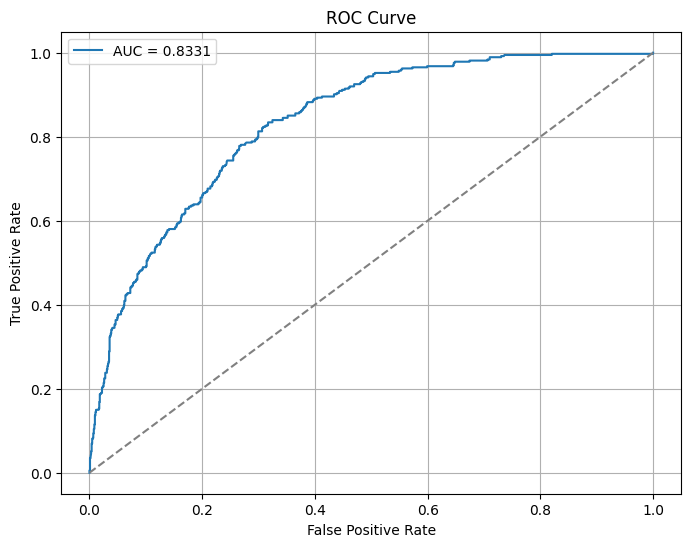

In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Clean TotalCharges
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Drop customerID
df = df.drop(columns=['customerID'])

# Numerical features to transform
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Updated GMM clustering function
def gmm_cluster_feature(df, feature, max_components=1000):
    # Drop missing
    feature_data = df[[feature]].dropna()

    # Limit max_components if there are fewer samples
    n_samples = feature_data.shape[0]
    upper_limit = min(max_components, n_samples - 1)  # -1 because GMM cannot have more clusters than samples

    # Try GMM for different numbers of components
    bics = []
    models = []
    print(f"🔵 Searching best GMM fit for '{feature}' from 2 to {upper_limit} clusters...")
    for n in range(2, upper_limit+1):
        try:
            gmm = GaussianMixture(n_components=n, random_state=42)
            gmm.fit(feature_data)
            bic = gmm.bic(feature_data)
            bics.append(bic)
            models.append(gmm)
            if n % 100 == 0:
                print(f"⏳ Processed {n} clusters...")
        except Exception as e:
            print(f"⚠️ Skipping {n} clusters due to error: {e}")
            break

    # Select best model
    best_n = np.argmin(bics) + 2
    best_gmm = models[np.argmin(bics)]

    # Predict clusters
    cluster_labels = best_gmm.predict(feature_data)

    # Map back to original df
    cluster_series = pd.Series(cluster_labels, index=feature_data.index, name=f'{feature}_cluster')

    return cluster_series, best_n

# Transform each numerical feature
for feature in numerical_features:
    print(f"\n🔵 Processing feature: {feature}")
    cluster_labels, best_n = gmm_cluster_feature(df, feature, max_components=1000)
    print(f"✅ Best number of GMM clusters for {feature}: {best_n}")
    df[f'{feature}_cluster'] = cluster_labels

# Drop original numerical features
df = df.drop(columns=numerical_features)

# All features now categorical
X = df.drop(columns=['Churn'])
y = df['Churn']

# Encode all features
le = LabelEncoder()
for col in X.columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Encode target
y = le.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create LGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# LGBM parameters
params = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'boosting': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42
}

# Train LGBM with early stopping
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

# Predict
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = (y_pred_prob > 0.5).astype(int)

# ====================
# 📋 Model Evaluation
# ====================

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print metrics
print("\n=================== Model Performance Metrics ===================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC Score: {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
✅ Best number of GMM clusters for tenure: 73
✅ Best number of GMM clusters for MonthlyCharges: 998
✅ Best number of GMM clusters for TotalCharges: 14

In [2]:
!pip install optbinning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 61.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 18.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.26.1 which i

### Optimal Binning of Numerical Features + LightGBM Comparison (Original vs Binned)

**What this cell does**

This cell applies **Optimal Binning (supervised discretization)** to numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`), creates a binned (categorical) version of the dataset, and compares **LightGBM model performance** between original features and binned features.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → cleaning, copying, feature creation

- `optbinning`
  - `OptimalBinning()` → performs supervised binning of numerical variables
  - `fit()` → learns optimal bins using target (`Churn`)
  - `transform()` → converts numerical values into bin categories
  - `binning_table.build()` → displays binning statistics

- `sklearn.preprocessing`
  - `LabelEncoder()` → encodes categorical features into numeric values

- `sklearn.model_selection`
  - `train_test_split()` → splits data into train/test sets

- `lightgbm`
  - `LGBMClassifier()` → gradient boosting classifier

- `sklearn.metrics`
  - `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()` → performance metrics
  - `roc_auc_score()` → evaluates probability predictions
  - `confusion_matrix()`, `classification_report()` → detailed evaluation

---

**How it is implemented**

1. Load dataset and print basic shape information.
2. Drop `customerID` if present.
3. Convert target `Churn` into binary (1 = Yes, 0 = No).
4. Clean `TotalCharges` by converting to numeric and dropping missing values.
5. Create a copy of dataset (`df_binned`) for storing binned features.
6. For each numerical feature (`tenure`, `MonthlyCharges`, `TotalCharges`):
   - initialize `OptimalBinning` with constraints (`max_n_bins=6`, `min_bin_size=0.05`)
   - fit binning model using feature and target (`Churn`)
   - print binning table
   - transform feature into categorical bins and store as `<feature>_binned`
7. Create two datasets:
   - `X_original` → original numerical + categorical features
   - `X_binned` → numerical features replaced with their binned versions
8. Encode categorical variables in both datasets using `LabelEncoder`.
9. Split both datasets into train/test sets using stratification.
10. Compute class imbalance ratio (`scale_pos_weight`) from training data.
11. Train two LightGBM models:
    - one on original features
    - one on binned features
12. Define `evaluate_model()` function to compute metrics and print results.
13. Evaluate both models using accuracy, precision, recall, F1, ROC-AUC, confusion matrix, and classification report to compare performance.

In [4]:
# 📦 Install if needed:
# !pip install optbinning lightgbm scikit-learn

import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from optbinning import OptimalBinning

# ✅ Step 1: Load your dataset
print("📂 Loading dataset...")
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
print(f"✅ Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.\n")

# ✅ Step 2: List of numerical features to bin
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(f"🎯 Numerical features to bin: {numerical_features}\n")

# ✅ Step 3: Drop 'customerID' column if it exists
if 'customerID' in df.columns:
    print("🗑️ Dropping 'customerID' column...")
    df = df.drop(columns=['customerID'])
    print("✅ 'customerID' column dropped.\n")
else:
    print("ℹ️ 'customerID' column not found, skipping drop.\n")

# ✅ Step 4: Convert 'Churn' column to binary
if df['Churn'].dtype == object:
    print("🔄 Converting 'Churn' values to 1/0...")
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    print("✅ 'Churn' conversion complete.\n")
else:
    print("ℹ️ 'Churn' column already numeric, no conversion needed.\n")

# ✅ Step 5: Handle bad/missing values in 'TotalCharges'
print("🔍 Checking and cleaning 'TotalCharges' column...")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_count = df['TotalCharges'].isna().sum()
print(f"⚠️ Found {missing_count} missing/invalid values in 'TotalCharges'. Dropping these rows...")

df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(f"✅ Dropped rows with missing TotalCharges. New dataset shape: {df.shape}\n")

# ✅ Step 6: Create a copy to store binned versions
df_binned = df.copy()
print("📝 Created a copy of the dataset for binning.\n")

# ✅ Step 7: Perform Optimal Binning
for idx, feature in enumerate(numerical_features, start=1):
    print(f"🚀 [{idx}/{len(numerical_features)}] Binning feature: '{feature}'...")

    optb = OptimalBinning(
        name=feature,
        dtype="numerical",
        solver="cp",
        max_n_bins=6,
        min_bin_size=0.05
    )

    print(f"🔧 Fitting OptimalBinning model on '{feature}'...")
    optb.fit(df[feature], df['Churn'])
    print(f"✅ Fitting complete for '{feature}'.")

    binning_table = optb.binning_table.build()
    print(f"📊 Binning Table for '{feature}':")
    print(binning_table, "\n")

    print(f"🎨 Transforming '{feature}' into categorical bins...")
    df_binned[feature + "_binned"] = optb.transform(df[feature], metric="bins")
    print(f"✅ Transformation complete for '{feature}'.\n")

# ✅ Step 8: Prepare datasets
binned_features = [col + "_binned" for col in numerical_features]

X_original = df.drop(columns=['Churn'])  # original numerical + categorical
X_binned = df_binned.drop(columns=numerical_features + ['Churn'])  # binned version
y = df['Churn']

print("✅ Prepared both original and binned datasets.\n")

# ✅ Step 9: Label Encode categorical features for original dataset
print("🔠 Label encoding categorical features in original dataset...")
categorical_cols_orig = X_original.select_dtypes(include=['object']).columns.tolist()
print(f"ℹ️ Categorical columns found in original data: {categorical_cols_orig}")

le = LabelEncoder()
for col in categorical_cols_orig:
    X_original[col] = le.fit_transform(X_original[col])

print("✅ Label encoding completed for original dataset.\n")

# ✅ Step 10: Label Encode categorical features for binned dataset
print("🔠 Label encoding categorical features in binned dataset...")
categorical_cols_binned = X_binned.select_dtypes(include=['object']).columns.tolist()
print(f"ℹ️ Categorical columns found in binned data: {categorical_cols_binned}")

for col in categorical_cols_binned:
    X_binned[col] = le.fit_transform(X_binned[col])

print("✅ Label encoding completed for binned dataset.\n")

# ✅ Step 11: Train-test split
print("✂️ Splitting data into train and test sets...\n")
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X_original, y, test_size=0.2, random_state=42, stratify=y)
X_train_binned, X_test_binned, _, _ = train_test_split(X_binned, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Step 12: Handle class imbalance
print("⚖️ Handling class imbalance...")
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"✅ Computed scale_pos_weight: {scale_pos_weight:.4f}\n")

# ✅ Step 13: Train LightGBM models
print("🚀 Training LightGBM model on original features...")
model_orig = lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
model_orig.fit(X_train_orig, y_train)

print("🚀 Training LightGBM model on binned features...")
model_binned = lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
model_binned.fit(X_train_binned, y_train)

# ✅ Step 14: Evaluate models
print("\n📊 Evaluating models...\n")

def evaluate_model(model, X_test, y_test, title="Model"):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]
    print(f"📋 Evaluation Results for {title}:")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1 Score:", f1_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("\nDetailed Classification Report:\n", classification_report(y_test, preds))
    print("-" * 60)

# ✅ Evaluate both models
evaluate_model(model_orig, X_test_orig, y_test, title="Original Features")
evaluate_model(model_binned, X_test_binned, y_test, title="Binned Categorical Features")


(CVXPY) Apr 28 02:21:30 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Apr 28 02:21:30 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
📂 Loading dataset...
✅ Dataset loaded with 7043 rows and 21 columns.

🎯 Numerical features to bin: ['tenure', 'MonthlyCharges', 'TotalCharges']

🗑️ Dropping 'customerID' column...
✅ 'customerID' column dropped.

🔄 Converting 'Churn' values to 1/0...
✅ 'Churn' conversion complete.

🔍 Checking and cleaning 'TotalCharges' column...
⚠️ Found 11 missing/invalid values in 'TotalCharges'. Dropping these rows...
✅ Dropped rows with missing TotalCharges. New dataset shape: (7032, 20)

📝 Created a copy of the dataset f

### Optimal Binning + One-Hot Encoding + LightGBM Comparison

**What this cell does**

This cell applies **Optimal Binning** to numerical features, converts all features into **one-hot encoded format**, and compares **LightGBM model performance** between original features and binned features.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - `read_csv()` → loads dataset
  - dataframe operations → cleaning, copying, feature creation
  - `get_dummies()` → performs one-hot encoding

- `optbinning`
  - `OptimalBinning()` → supervised binning of numerical features
  - `fit()` → learns bin splits using target (`Churn`)
  - `transform()` → converts numerical values into bin categories
  - `binning_table.build()` → shows bin statistics

- `sklearn.model_selection`
  - `train_test_split()` → splits dataset into train/test sets

- `lightgbm`
  - `LGBMClassifier()` → gradient boosting model

- `sklearn.metrics`
  - `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()` → evaluation metrics
  - `roc_auc_score()` → evaluates predicted probabilities
  - `confusion_matrix()`, `classification_report()` → detailed evaluation

---

**How it is implemented**

1. Load dataset and print shape.
2. Drop `customerID` if present.
3. Convert target `Churn` into binary (1/0).
4. Clean `TotalCharges` by converting to numeric and removing missing values.
5. Create a copy of dataset (`df_binned`) for storing binned features.
6. For each numerical feature (`tenure`, `MonthlyCharges`, `TotalCharges`):
   - fit `OptimalBinning` with constraints (`max_n_bins=6`, `min_bin_size=0.05`)
   - display binning table
   - transform feature into categorical bins (`<feature>_binned`)
7. Prepare two datasets:
   - `X_original` → original features
   - `X_binned` → numerical features replaced by binned versions
8. Apply **one-hot encoding (`pd.get_dummies`)** to both datasets.
9. Clean feature names by replacing special characters to ensure LightGBM compatibility.
10. Split both datasets into training and testing sets using stratification.
11. Compute class imbalance ratio (`scale_pos_weight`) from training data.
12. Train two LightGBM models (`n_estimators=500`):
    - one on original features
    - one on binned features
13. Define evaluation function to compute metrics.
14. Evaluate both models using accuracy, precision, recall, F1 score, ROC-AUC, confusion matrix, and classification report for comparison.

In [6]:
# 📦 Install if needed:
# !pip install optbinning lightgbm scikit-learn

import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from optbinning import OptimalBinning

# ✅ Step 1: Load your dataset
print("📂 Loading dataset...")
df = pd.read_csv('/kaggle/input/customer-churn-openml-2-7043/dataset1_openml_7043x21.csv')
print(f"✅ Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.\n")

# ✅ Step 2: List of numerical features to bin
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(f"🎯 Numerical features to bin: {numerical_features}\n")

# ✅ Step 3: Drop 'customerID' column if it exists
if 'customerID' in df.columns:
    print("🗑️ Dropping 'customerID' column...")
    df = df.drop(columns=['customerID'])
    print("✅ 'customerID' column dropped.\n")
else:
    print("ℹ️ 'customerID' column not found, skipping drop.\n")

# ✅ Step 4: Convert 'Churn' column to binary
if df['Churn'].dtype == object:
    print("🔄 Converting 'Churn' values to 1/0...")
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    print("✅ 'Churn' conversion complete.\n")
else:
    print("ℹ️ 'Churn' column already numeric, no conversion needed.\n")

# ✅ Step 5: Handle bad/missing values in 'TotalCharges'
print("🔍 Checking and cleaning 'TotalCharges' column...")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_count = df['TotalCharges'].isna().sum()
print(f"⚠️ Found {missing_count} missing/invalid values in 'TotalCharges'. Dropping these rows...")

df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(f"✅ Dropped rows with missing TotalCharges. New dataset shape: {df.shape}\n")

# ✅ Step 6: Create a copy to store binned versions
df_binned = df.copy()
print("📝 Created a copy of the dataset for binning.\n")

# ✅ Step 7: Perform Optimal Binning
for idx, feature in enumerate(numerical_features, start=1):
    print(f"🚀 [{idx}/{len(numerical_features)}] Binning feature: '{feature}'...")

    optb = OptimalBinning(
        name=feature,
        dtype="numerical",
        solver="cp",
        max_n_bins=6,
        min_bin_size=0.05
    )

    print(f"🔧 Fitting OptimalBinning model on '{feature}'...")
    optb.fit(df[feature], df['Churn'])
    print(f"✅ Fitting complete for '{feature}'.")

    binning_table = optb.binning_table.build()
    print(f"📊 Binning Table for '{feature}':")
    print(binning_table, "\n")

    print(f"🎨 Transforming '{feature}' into categorical bins...")
    df_binned[feature + "_binned"] = optb.transform(df[feature], metric="bins")
    print(f"✅ Transformation complete for '{feature}'.\n")

# ✅ Step 8: Prepare datasets
binned_features = [col + "_binned" for col in numerical_features]

X_original = df.drop(columns=['Churn'])  # original numerical + categorical
X_binned = df_binned.drop(columns=numerical_features + ['Churn'])  # binned version
y = df['Churn']

print("✅ Prepared both original and binned datasets.\n")

# ✅ Step 9: One-Hot Encode categorical features
print("🔠 One-hot encoding categorical features in original dataset...")
X_original = pd.get_dummies(X_original, drop_first=True)
print("✅ One-hot encoding completed for original dataset.\n")

print("🔠 One-hot encoding categorical features in binned dataset...")
X_binned = pd.get_dummies(X_binned, drop_first=True)
print("✅ One-hot encoding completed for binned dataset.\n")

# ✅ Step 10: Fix Special Characters in Feature Names
print("🛠️ Fixing special characters in feature names for LightGBM compatibility...")
X_original.columns = X_original.columns.str.replace(r'[^\w]', '_', regex=True)
X_binned.columns = X_binned.columns.str.replace(r'[^\w]', '_', regex=True)
print("✅ Special characters replaced.\n")

# ✅ Step 11: Train-test split
print("✂️ Splitting data into train and test sets...\n")
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X_original, y, test_size=0.2, random_state=42, stratify=y)
X_train_binned, X_test_binned, _, _ = train_test_split(X_binned, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Step 12: Handle class imbalance
print("⚖️ Handling class imbalance...")
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"✅ Computed scale_pos_weight: {scale_pos_weight:.4f}\n")

# ✅ Step 13: Train LightGBM models
print("🚀 Training LightGBM model on original features...")
model_orig = lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, n_estimators=500)
model_orig.fit(X_train_orig, y_train)

print("🚀 Training LightGBM model on binned features...")
model_binned = lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, n_estimators=500)
model_binned.fit(X_train_binned, y_train)


# ✅ Step 14: Evaluate models
print("\n📊 Evaluating models...\n")

def evaluate_model(model, X_test, y_test, title="Model"):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]
    print(f"📋 Evaluation Results for {title}:")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1 Score:", f1_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("\nDetailed Classification Report:\n", classification_report(y_test, preds))
    print("-" * 60)

# ✅ Evaluate both models
evaluate_model(model_orig, X_test_orig, y_test, title="Original Features")
evaluate_model(model_binned, X_test_binned, y_test, title="Binned Categorical Features")


📂 Loading dataset...
✅ Dataset loaded with 7043 rows and 21 columns.

🎯 Numerical features to bin: ['tenure', 'MonthlyCharges', 'TotalCharges']

🗑️ Dropping 'customerID' column...
✅ 'customerID' column dropped.

🔄 Converting 'Churn' values to 1/0...
✅ 'Churn' conversion complete.

🔍 Checking and cleaning 'TotalCharges' column...
⚠️ Found 11 missing/invalid values in 'TotalCharges'. Dropping these rows...
✅ Dropped rows with missing TotalCharges. New dataset shape: (7032, 20)

📝 Created a copy of the dataset for binning.

🚀 [1/3] Binning feature: 'tenure'...
🔧 Fitting OptimalBinning model on 'tenure'...
✅ Fitting complete for 'tenure'.
📊 Binning Table for 'tenure':
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0         (-inf, 1.50)    613   0.087173        233    380    0.619902   
1         [1.50, 5.50)    747   0.106229        383    364    0.487282   
2        [5.50, 16.50)   1179   0.167662        759    420    0.356234   
3       [16.50, 43.50)   1936  

In [7]:
X_train_binned.columns

Index(['SeniorCitizen', 'gender_Male', 'Partner_Yes', 'Dependents_Yes',
       'PhoneService_Yes', 'MultipleLines_No_phone_service',
       'MultipleLines_Yes', 'InternetService_Fiber_optic',
       'InternetService_No', 'OnlineSecurity_No_internet_service',
       'OnlineSecurity_Yes', 'OnlineBackup_No_internet_service',
       'OnlineBackup_Yes', 'DeviceProtection_No_internet_service',
       'DeviceProtection_Yes', 'TechSupport_No_internet_service',
       'TechSupport_Yes', 'StreamingTV_No_internet_service', 'StreamingTV_Yes',
       'StreamingMovies_No_internet_service', 'StreamingMovies_Yes',
       'Contract_One_year', 'Contract_Two_year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit_card__automatic_',
       'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check',
       'tenure_binned__1_50__5_50_', 'tenure_binned__16_50__43_50_',
       'tenure_binned__43_50__70_50_', 'tenure_binned__5_50__16_50_',
       'tenure_binned__70_50__inf_', 'MonthlyCharges_binned__19

### CTGAN-Based Synthetic Data Generation on Binned Dataset (Reproducible Setup)

**What this cell does**

This cell trains a **CTGAN (Conditional GAN)** model on the **binned categorical dataset with churn labels**, generates **70,000 synthetic samples**, and saves the generated dataset. It ensures reproducibility by fixing random seeds and optionally uses GPU acceleration.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - dataframe operations → copying dataset, merging target, saving synthetic data

- `numpy`, `random`, `torch`
  - `seed()` / `manual_seed()` → ensures reproducibility across NumPy, Python, and PyTorch
  - `torch.cuda.is_available()` → checks GPU availability

- `sdv.single_table`
  - `CTGANSynthesizer()` → generative model for tabular data
  - `fit()` → trains CTGAN on input dataset
  - `sample()` → generates synthetic data

- `sdv.metadata`
  - `SingleTableMetadata()` → detects schema and feature types automatically

- `sdv.evaluation.single_table`
  - `evaluate_quality` (imported but not used here)

- `time`
  - `time()` → tracks total, training, and generation time

- `warnings`
  - `filterwarnings("ignore")` → suppresses warnings

---

**How it is implemented**

1. Set random seeds for NumPy, Python, and PyTorch (including CUDA) for reproducibility.
2. Start execution timer.
3. Use previously prepared **binned dataset (`X_binned`)** and merge target variable `Churn` back into it.
4. Display sample rows to verify dataset structure.
5. Detect dataset metadata automatically using `SingleTableMetadata`.
6. Define optimized CTGAN hyperparameters (batch size, epochs, learning rates, network dimensions, GPU usage).
7. Initialize `CTGANSynthesizer` with metadata and parameters.
8. Train CTGAN model on the dataset using `fit()`.
9. Generate **70,000 synthetic rows** using `sample()`.
10. Save generated dataset to CSV:/kaggle/working/augmented_CTGAN_Binned_Churn_dataset.csv
11. Print training time, generation time, and total execution time.

In [7]:
# 📦 Import libraries
import pandas as pd
import numpy as np
import torch
import random
import time
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
import warnings
warnings.filterwarnings("ignore")

# ✅ Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ✅ Start timing
start_time = time.time()
print("🚀 Starting reproducible CTGAN generation on GPU...\n")

# ✅ Use your existing binned dataset
# Assuming you already have X_binned and y from earlier
# Otherwise load them if needed

# Merge Churn back into the binned dataset
print("🔗 Merging 'Churn' back into the binned dataset...")
df_binned_with_churn = X_binned.copy()
df_binned_with_churn['Churn'] = y.values
print("✅ Merge complete.\n")

# ✅ Print first two rows
print("🧾 First two rows of dataset to be used for CTGAN training:")
print(df_binned_with_churn.head(2))
print("\n✅ Dataset ready for synthetic data generation.\n")

# ✅ Define metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_binned_with_churn)
print(f"✅ Metadata detection complete. Dataset shape: {df_binned_with_churn.shape}\n")

# ✅ Best CTGAN Hyperparameters (as per your earlier setup)
best_params = {
    'batch_size': 360,
    'epochs': 1552,
    'embedding_dim': 110,
    'generator_lr': 0.004713204343061388,
    'discriminator_lr': 0.0017260261506771618,
    'generator_dim': (299, 216),
    'discriminator_dim': (230, 207),
    'verbose': True,
    'cuda': torch.cuda.is_available()
}

# ✅ Train CTGAN
print("🧠 Training CTGAN with best parameters on CUDA..." if best_params['cuda'] else "🧠 Training CTGAN with best parameters on CPU...")
train_start = time.time()
model = CTGANSynthesizer(metadata, **best_params)
model.fit(df_binned_with_churn)
train_end = time.time()
print(f"⏱️ Training time: {train_end - train_start:.2f} seconds\n")

# ✅ Generate synthetic data
print("📈 Generating synthetic data (70,000 rows)...")
generate_start = time.time()
synthetic_df = model.sample(70000)
generate_end = time.time()
print(f"⏱️ Generation time: {generate_end - generate_start:.2f} seconds\n")

# ✅ Save synthetic data
output_path = "/kaggle/working/augmented_CTGAN_Binned_Churn_dataset.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"📁 Synthetic data saved to: {output_path}\n")

# ✅ Completion
end_time = time.time()
print(f"🎉 Completed in {end_time - start_time:.2f} seconds")


🚀 Starting reproducible CTGAN generation on GPU...

🔗 Merging 'Churn' back into the binned dataset...
✅ Merge complete.

🧾 First two rows of dataset to be used for CTGAN training:
   SeniorCitizen  gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0              0        False         True           False             False   
1              0         True        False           False              True   

   MultipleLines_No_phone_service  MultipleLines_Yes  \
0                            True              False   
1                           False              False   

   InternetService_Fiber_optic  InternetService_No  \
0                        False               False   
1                        False               False   

   OnlineSecurity_No_internet_service  ...  \
0                               False  ...   
1                               False  ...   

   MonthlyCharges_binned__19_93__20_88_  MonthlyCharges_binned__20_88__27_68_  \
0                          

Gen. (-0.14) | Discrim. (4.44): 100%|██████████| 1552/1552 [23:16<00:00,  1.11it/s] 


⏱️ Training time: 1405.30 seconds

📈 Generating synthetic data (70,000 rows)...
⏱️ Generation time: 2.92 seconds

📁 Synthetic data saved to: /kaggle/working/augmented_CTGAN_Binned_Churn_dataset.csv

🎉 Completed in 1409.01 seconds


In [25]:
# 📦 Save the trained CTGAN model
model_save_path = "/kaggle/working/ctgan_model_1_full_categorical.pkl"

# ✅ Save the model using SDV's save method
model.save(model_save_path)
print(f"✅ CTGAN model saved to: {model_save_path}")

# 📥 To download the model in Kaggle Notebooks, create a download link:
from IPython.display import FileLink

print("\n📁 Click below link to download the saved CTGAN model:")
display(FileLink(model_save_path))


✅ CTGAN model saved to: /kaggle/working/ctgan_model_1_full_categorical.pkl

📁 Click below link to download the saved CTGAN model:


/kaggle/working/ctgan_model_1_full_categorical.pkl

In [17]:
# ✅ Save synthetic data
output_path = "/kaggle/working/augmented_CTGAN_Binned_Churn_dataset.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"📁 Synthetic data saved to: {output_path}\n")

📁 Synthetic data saved to: /kaggle/working/augmented_CTGAN_Binned_Churn_dataset.csv



In [18]:
# ✅ Evaluate and display metrics
print("📊 Evaluating quality of synthetic data...")
report = evaluate_quality(real_data=df, synthetic_data=synthetic_df, metadata=metadata)

# Print individual detailed results
print("\n📌 Column Shapes Details:")
print(report.get_details(property_name='Column Shapes'))

print("\n📌 Column Pair Trends Details:")
print(report.get_details(property_name='Column Pair Trends'))

# Print overall score
print(f"\n✅ Overall Score: {report.get_score():.4f}")

# ✅ Save to CSV
output_path = "/kaggle/working/augmented_CTGAN_Churn_dataset_1.csv"
synthetic_df.to_csv(output_path, index=False)
print(f"📁 Synthetic data saved to: {output_path}")

# ✅ Completion time
end_time = time.time()
print(f"🎉 Completed in {end_time - start_time:.2f} seconds")


📊 Evaluating quality of synthetic data...


ValueError: The metadata does not match the data. The following columns are missing in the real/synthetic data or in the metadata: Contract, Dependents, DeviceProtection, InternetService, MonthlyCharges, MultipleLines, OnlineBackup, OnlineSecurity, PaperlessBilling, Partner, PaymentMethod, PhoneService, StreamingMovies, StreamingTV, TechSupport, TotalCharges, gender, tenure

In [10]:
df_binned_with_churn.columns

Index(['SeniorCitizen', 'gender_Male', 'Partner_Yes', 'Dependents_Yes',
       'PhoneService_Yes', 'MultipleLines_No_phone_service',
       'MultipleLines_Yes', 'InternetService_Fiber_optic',
       'InternetService_No', 'OnlineSecurity_No_internet_service',
       'OnlineSecurity_Yes', 'OnlineBackup_No_internet_service',
       'OnlineBackup_Yes', 'DeviceProtection_No_internet_service',
       'DeviceProtection_Yes', 'TechSupport_No_internet_service',
       'TechSupport_Yes', 'StreamingTV_No_internet_service', 'StreamingTV_Yes',
       'StreamingMovies_No_internet_service', 'StreamingMovies_Yes',
       'Contract_One_year', 'Contract_Two_year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit_card__automatic_',
       'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check',
       'tenure_binned__1_50__5_50_', 'tenure_binned__16_50__43_50_',
       'tenure_binned__43_50__70_50_', 'tenure_binned__5_50__16_50_',
       'tenure_binned__70_50__inf_', 'MonthlyCharges_binned__19

### Real vs Synthetic Data Discrimination using LightGBM

**What this cell does**

This cell evaluates the quality of synthetic data by training a **LightGBM classifier to distinguish between real and synthetic (CTGAN-generated) samples**. If the model performs poorly, it indicates synthetic data closely resembles real data; high performance indicates detectable differences.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - dataframe operations → copying datasets, merging, column filtering, concatenation

- `numpy`
  - used implicitly for numerical operations

- `lightgbm`
  - `LGBMClassifier()` → classifier to distinguish real vs synthetic data

- `sklearn.model_selection`
  - `train_test_split()` → splits combined dataset into train/test sets

- `sklearn.preprocessing`
  - `OrdinalEncoder()` → encodes categorical variables with handling for unseen values

- `sklearn.metrics`
  - `classification_report()` → detailed classification summary
  - `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()` → performance metrics
  - `roc_auc_score()` → evaluates probability predictions

- `warnings`
  - `filterwarnings('ignore')` → suppresses warnings

---

**How it is implemented**

1. Load real dataset (`df_binned_with_churn`) and synthetic dataset from CSV.
2. Drop `customerID` column from both datasets if present.
3. Clean `TotalCharges` (convert to numeric and remove missing values if applicable).
4. Add a binary label:
   - `is_real = 1` for real data
   - `is_real = 0` for synthetic data
5. Identify common columns between real and synthetic datasets to ensure alignment.
6. Combine both datasets into a single dataframe.
7. Identify categorical and numerical columns.
8. Convert categorical columns to string and encode them using `OrdinalEncoder` (handles unseen categories).
9. Split combined dataset into training and testing sets using stratification.
10. Train a LightGBM classifier (`n_estimators=500`) to predict `is_real`.
11. Generate predictions and probabilities on the test set.
12. Evaluate model using classification report, accuracy, precision, recall, F1 score, and ROC-AUC to assess how distinguishable synthetic data is from real data.

In [23]:
# 📦 Import libraries
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import warnings
warnings.filterwarnings('ignore')

# ✅ Load real (binned) and fake (synthetic) datasets
real_df = df_binned_with_churn.copy()
fake_df = pd.read_csv('/kaggle/working/augmented_CTGAN_Binned_Churn_dataset.csv')

# ✅ Drop 'customerID' if it exists (safe drop)
if 'customerID' in real_df.columns:
    print("🗑️ Dropping 'customerID' from real_df...")
    real_df = real_df.drop(columns=["customerID"])
if 'customerID' in fake_df.columns:
    print("🗑️ Dropping 'customerID' from fake_df...")
    fake_df = fake_df.drop(columns=["customerID"])

# ✅ Clean 'TotalCharges' if present
if 'TotalCharges' in real_df.columns:
    real_df['TotalCharges'] = pd.to_numeric(real_df['TotalCharges'], errors='coerce')
    real_df = real_df.dropna(subset=['TotalCharges']).reset_index(drop=True)
if 'TotalCharges' in fake_df.columns:
    fake_df['TotalCharges'] = pd.to_numeric(fake_df['TotalCharges'], errors='coerce')
    fake_df = fake_df.dropna(subset=['TotalCharges']).reset_index(drop=True)

# ✅ Add 'is_real' label
real_df['is_real'] = 1
fake_df['is_real'] = 0

# ✅ Find common columns between real and fake
common_cols = list(set(real_df.columns).intersection(set(fake_df.columns)))
common_cols.remove('is_real')  # Remove the label column

# ✅ Combine datasets
combined = pd.concat([
    real_df[common_cols + ['is_real']],
    fake_df[common_cols + ['is_real']]
], axis=0).reset_index(drop=True)

# ✅ Identify categorical and numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in common_cols if col not in numerical_cols]

if len(categorical_cols) > 0:
    print("🔠 Converting categorical columns to string type before encoding...")
    combined[categorical_cols] = combined[categorical_cols].astype(str)  # Force string type
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    combined[categorical_cols] = encoder.fit_transform(combined[categorical_cols])
    print("✅ Categorical encoding completed.\n")

# ✅ Train-test split
X = combined[common_cols]
y = combined['is_real']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# ✅ Train LightGBM model
lgb_model = lgb.LGBMClassifier(n_estimators=500, random_state=42)
lgb_model.fit(X_train, y_train)

# ✅ Make predictions
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

# ✅ Evaluation metrics
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

print("📈 Additional Evaluation Metrics:")
print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")


🔠 Converting categorical columns to string type before encoding...
✅ Categorical encoding completed.

[LightGBM] [Info] Number of positive: 5626, number of negative: 55999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 84
[LightGBM] [Info] Number of data points in the train set: 61625, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.091294 -> initscore=-2.297935
[LightGBM] [Info] Start training from score -2.297935
📊 Classification Report:

              precision    recall  f1-score   support

    Fake (0)       0.99      0.99      0.99     14001
    Real (1)       0.88      0.86      0.87      1406

    accuracy                           0.98     15407
   macro avg       0.93      0.92      0.93     15407
weighted avg       0.98      0.98      0.98  

### Cross-Domain Evaluation: Real vs Synthetic Data using LightGBM (All Features as Categorical)

**What this cell does**

This cell evaluates the usefulness of synthetic data by training **LightGBM models on real and synthetic datasets separately and testing them on each other**, treating all features as categorical. This assesses how well patterns learned from one dataset generalize to the other.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - dataframe operations → copying datasets, column filtering, type conversion

- `sklearn.model_selection`
  - `train_test_split` (imported but not used)

- `sklearn.preprocessing`
  - `OrdinalEncoder()` → encodes categorical features with handling for unseen values

- `sklearn.metrics`
  - `classification_report()` → detailed performance summary
  - `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()` → evaluation metrics
  - `roc_auc_score()` → evaluates predicted probabilities

- `lightgbm`
  - `LGBMClassifier()` → classification model

- `warnings`
  - `filterwarnings('ignore')` → suppresses warnings

---

**How it is implemented**

1. Load real (binned) dataset and synthetic dataset.
2. Drop `customerID` column from both datasets if present.
3. Define target column (`Churn`) and feature columns (all other columns).
4. Treat all features as categorical and convert them to string type.
5. Encode categorical features using `OrdinalEncoder`, fitting on real data and applying to synthetic data.
6. Separate features (`X_real`, `X_synthetic`) and targets (`y_real`, `y_synthetic`).
7. Ensure target `Churn` is binary encoded (1 = Yes, 0 = No).
8. Define `evaluate_model()` function to compute classification metrics and handle edge cases (single-class predictions).
9. Train LightGBM model on real data and evaluate on synthetic data.
10. Train another LightGBM model on synthetic data and evaluate on real data.
11. Print performance metrics (accuracy, precision, recall, F1, ROC-AUC) to assess how well knowledge transfers between real and synthetic datasets.

In [25]:
# 📦 Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ✅ Load real (binned) and synthetic datasets
real_df = df_binned_with_churn.copy()
synthetic_df = pd.read_csv('/kaggle/working/augmented_CTGAN_Binned_Churn_dataset.csv')

# ✅ Drop 'customerID' if exists
real_df = real_df.drop(columns=[col for col in ['customerID'] if col in real_df.columns])
synthetic_df = synthetic_df.drop(columns=[col for col in ['customerID'] if col in synthetic_df.columns])

# ✅ Set target column
target_col = 'Churn'

# ✅ Get feature columns (all except target)
feature_cols = [col for col in real_df.columns if col != target_col]

# ✅ Treat all features as categorical
categorical_cols = feature_cols.copy()

# ✅ Convert all categorical features to string type before encoding
print("🔠 Converting all categorical columns to string...")
real_df[categorical_cols] = real_df[categorical_cols].astype(str)
synthetic_df[categorical_cols] = synthetic_df[categorical_cols].astype(str)

# ✅ Encode categorical features using OrdinalEncoder
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
real_df[categorical_cols] = encoder.fit_transform(real_df[categorical_cols])
synthetic_df[categorical_cols] = encoder.transform(synthetic_df[categorical_cols])

# ✅ Prepare features and target
X_real = real_df[feature_cols]
y_real = real_df[target_col]

X_synthetic = synthetic_df[feature_cols]
y_synthetic = synthetic_df[target_col]

# ✅ In case 'Churn' is not binary encoded already
if y_real.dtype == object or y_real.dtype == str:
    y_real = y_real.map({'Yes': 1, 'No': 0}).astype(int)
if y_synthetic.dtype == object or y_synthetic.dtype == str:
    y_synthetic = y_synthetic.map({'Yes': 1, 'No': 0}).astype(int)

# ✅ Define evaluation function
def evaluate_model(model, X_test, y_test, desc=""):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if len(model.classes_) > 1 else [0.0] * len(X_test)

    print(f"\n📊 Classification Report ({desc}):")
    try:
        print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))
    except ValueError:
        print("⚠️ Only one class present in predictions or ground truth. Skipping classification report.")

    print(f"✅ Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
    if len(set(y_test)) > 1 and len(set(y_pred)) > 1:
        print(f"✅ Precision      : {precision_score(y_test, y_pred):.4f}")
        print(f"✅ Recall         : {recall_score(y_test, y_pred):.4f}")
        print(f"✅ F1 Score       : {f1_score(y_test, y_pred):.4f}")
        print(f"✅ ROC AUC Score  : {roc_auc_score(y_test, y_proba):.4f}")
    else:
        print("⚠️ ROC AUC / Precision / Recall / F1 not available due to only one class.")

# ✅ Train on Real ➔ Test on Synthetic
print("\n🎯 Train on Real ➔ Test on Synthetic")
model_real = lgb.LGBMClassifier(n_estimators=500, random_state=42)
model_real.fit(X_real, y_real)
evaluate_model(model_real, X_synthetic, y_synthetic, desc="Train Real - Test Synthetic")

# ✅ Train on Synthetic ➔ Test on Real
print("\n🎯 Train on Synthetic ➔ Test on Real")
model_synth = lgb.LGBMClassifier(n_estimators=500, random_state=42)
model_synth.fit(X_synthetic, y_synthetic)
evaluate_model(model_synth, X_real, y_real, desc="Train Synthetic - Test Real")


🔠 Converting all categorical columns to string...

🎯 Train on Real ➔ Test on Synthetic
[LightGBM] [Info] Number of positive: 1869, number of negative: 5163
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000654 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 82
[LightGBM] [Info] Number of data points in the train set: 7032, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265785 -> initscore=-1.016114
[LightGBM] [Info] Start training from score -1.016114

📊 Classification Report (Train Real - Test Synthetic):
              precision    recall  f1-score   support

No Churn (0)       0.83      0.90      0.87     57142
   Churn (1)       0.31      0.19      0.24     12858

    accuracy                           0.77     70000
   macro avg       0.57      0.55      0.55     70000
weighted avg       0.74      0.7

### LightGBM Training and Feature Importance Comparison (Real vs Synthetic Data)

**What this cell does**

This cell trains separate **LightGBM models on real and synthetic datasets**, evaluates their performance, and computes **feature importance rankings (with percentage contribution)** to compare how feature influence differs between real and synthetic data.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - dataframe operations → copying datasets, filtering, feature importance table creation

- `numpy`
  - used for numerical operations and normalization

- `lightgbm`
  - `Dataset()` → prepares training/validation data
  - `train()` → trains model with boosting
  - `early_stopping()` → stops training when validation performance plateaus
  - `log_evaluation()` → logs training progress
  - `feature_importance()` → extracts feature importance scores

- `sklearn.model_selection`
  - `train_test_split()` → splits dataset into train/validation sets

- `sklearn.metrics`
  - `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()` → evaluation metrics
  - `roc_auc_score()` → evaluates probability predictions
  - `classification_report()` → detailed classification summary

- `matplotlib.pyplot`
  - `barh()` → plots horizontal feature importance chart

---

**How it is implemented**

1. Load real (`df_binned_with_churn`) and synthetic datasets.
2. Define function `train_and_evaluate(df, dataset_name)`:
   - separate features (`X`) and target (`Churn`)
   - normalize and encode target values (`Yes/No → 1/0` or validate numeric values)
   - remove invalid/missing target entries
   - split data into training and validation sets using stratification
   - create LightGBM datasets (`lgb.Dataset`)
   - define model parameters (binary objective, AUC metric)
   - train model using `lgb.train()` with early stopping and logging
   - generate predictions and probabilities
   - compute evaluation metrics (accuracy, precision, recall, F1, ROC-AUC)
   - print classification report
   - extract feature importance using `importance_type='gain'`
   - normalize importance scores to percentages
   - sort features by importance
   - plot horizontal bar chart of feature importances
3. Call the function twice:
   - once for real dataset
   - once for synthetic dataset
4. Return trained models and feature importance tables for comparison.


Training model on Real dataset...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[31]	training's binary_logloss: 0.373004	training's auc: 0.886756	valid_1's binary_logloss: 0.423798	valid_1's auc: 0.838978

Model Performance Metrics:
Accuracy  : 0.8017
Precision : 0.6557
Recall    : 0.5348
F1 Score  : 0.5891
ROC AUC   : 0.8390

Classification Report:
               precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407


Top Feature Importances (%):
                                   Feature   Importance  Importance_Percentage
22                       Contract_Two_year  3191.092413              26.167403
21                       Contract_One_year  2177.915306              17.859209
7 

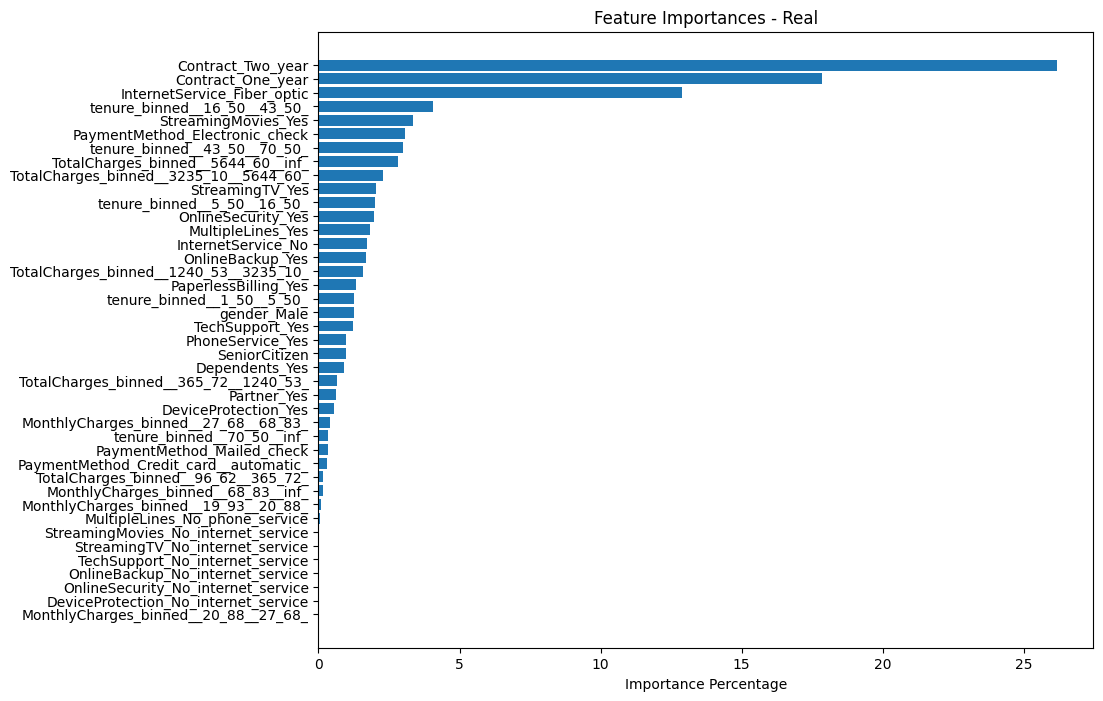


Training model on Synthetic dataset...
Training until validation scores don't improve for 50 rounds
[100]	training's binary_logloss: 0.381199	training's auc: 0.805122	valid_1's binary_logloss: 0.40178	valid_1's auc: 0.771373
Early stopping, best iteration is:
[65]	training's binary_logloss: 0.387743	training's auc: 0.795184	valid_1's binary_logloss: 0.401499	valid_1's auc: 0.771779

Model Performance Metrics:
Accuracy  : 0.8271
Precision : 0.5846
Recall    : 0.2041
F1 Score  : 0.3026
ROC AUC   : 0.7718

Classification Report:
               precision    recall  f1-score   support

    No Churn       0.84      0.97      0.90     11428
       Churn       0.58      0.20      0.30      2572

    accuracy                           0.83     14000
   macro avg       0.71      0.59      0.60     14000
weighted avg       0.80      0.83      0.79     14000


Top Feature Importances (%):
                                   Feature    Importance  \
25          PaymentMethod_Electronic_check  23778

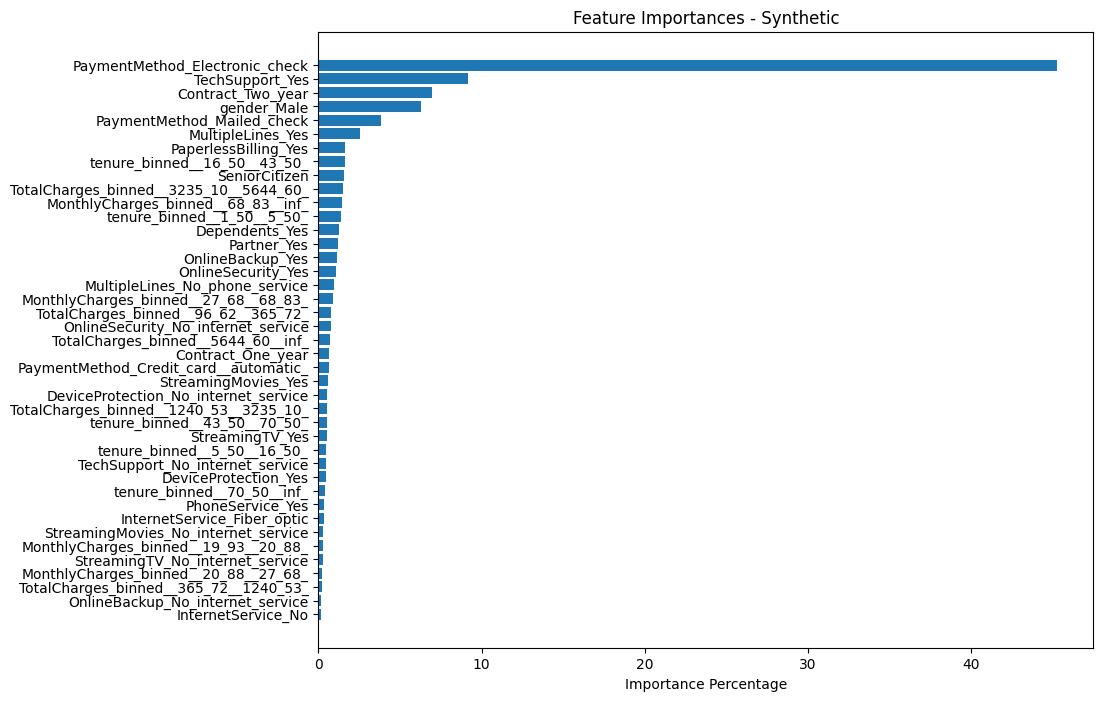

In [29]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt

# Load datasets
real_df = df_binned_with_churn.copy()
synthetic_df = pd.read_csv('/kaggle/working/augmented_CTGAN_Binned_Churn_dataset.csv')

import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

def train_and_evaluate(df, dataset_name):
    print(f"\nTraining model on {dataset_name} dataset...")

    # Split features and target
    X = df.drop('Churn', axis=1)
    y_raw = df['Churn']

    # Handle Churn encoding
    if y_raw.dtype == 'object':
        # Normalize text, just in case (handle 'yes', 'no', 'Yes', etc.)
        y_raw = y_raw.str.strip().str.lower()
        y = y_raw.map({'no': 0, 'yes': 1})
    else:
        # Assume numeric 0/1, but validate
        y = y_raw.copy()
        y = y.where(y.isin([0, 1]))  # Set invalid labels to NaN

    # Drop invalid/missing values
    valid_idx = y.dropna().index
    X = X.loc[valid_idx]
    y = y.loc[valid_idx]

    # Check if there is valid data
    if X.shape[0] == 0:
        print(f"❌ No valid data found in {dataset_name} after cleaning! Skipping training.")
        return None, None

    # Train-test split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # LightGBM Dataset
    lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature='auto')
    lgb_val = lgb.Dataset(X_val, label=y_val, categorical_feature='auto', reference=lgb_train)

    # Model parameters
    params = {
        'objective': 'binary',
        'metric': ['binary_logloss', 'auc'],
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'seed': 42
    }

    # Train model using callbacks
    model = lgb.train(
        params,
        lgb_train,
        valid_sets=[lgb_train, lgb_val],
        num_boost_round=1000,
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(period=100)
        ]
    )

    # Predictions
    y_pred_prob = model.predict(X_val, num_iteration=model.best_iteration)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc = roc_auc_score(y_val, y_pred_prob)

    print("\nModel Performance Metrics:")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc:.4f}")
    print("\nClassification Report:\n", classification_report(y_val, y_pred, target_names=['No Churn', 'Churn']))

    # Feature Importances
    feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importance(importance_type='gain')
    }).sort_values(by='Importance', ascending=False)

    # Calculate percentage
    total = feature_importances['Importance'].sum()
    feature_importances['Importance_Percentage'] = 100 * feature_importances['Importance'] / total

    print("\nTop Feature Importances (%):")
    print(feature_importances)

    # Plot feature importances
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importances['Feature'], feature_importances['Importance_Percentage'])
    plt.xlabel('Importance Percentage')
    plt.title(f'Feature Importances - {dataset_name}')
    plt.gca().invert_yaxis()
    plt.show()

    return model, feature_importances

# Train on real dataset
real_model, real_feature_importances = train_and_evaluate(real_df, 'Real')

# Train on synthetic dataset
synthetic_model, synthetic_feature_importances = train_and_evaluate(synthetic_df, 'Synthetic')


In [37]:
import pandas as pd

# Assume these are your datasets
real_df = df_binned_with_churn.copy()
synthetic_df = pd.read_csv('/kaggle/working/augmented_CTGAN_Binned_Churn_dataset.csv')

# Save datasets as CSVs
real_df_filename = '/kaggle/working/real_dataset_binned_with_churn.csv'
synthetic_df_filename = '/kaggle/working/synthetic_dataset_ctgan_binned_churn.csv'

real_df.to_csv(real_df_filename, index=False)
synthetic_df.to_csv(synthetic_df_filename, index=False)

# Print download links
from IPython.display import FileLink

print("Download your saved datasets here:")
display(FileLink(real_df_filename))
display(FileLink(synthetic_df_filename))


Download your saved datasets here:


/kaggle/working/real_dataset_binned_with_churn.csv

/kaggle/working/synthetic_dataset_ctgan_binned_churn.csv

In [34]:
synthetic_df.shape

(70000, 42)

### Column-wise Conditional Sampling Accuracy Evaluation for CTGAN

**What this cell does**

This cell evaluates how well the trained **CTGAN model can reconstruct each column given all other columns** by performing **conditional sampling per row** and computing column-wise prediction accuracy.

---

**Libraries / Packages / Methods Used**

- `pandas`
  - dataframe operations → column selection, row access, conversion to dictionary

- `numpy`
  - `array()` → stores predictions
  - `sum()` → counts correct predictions
  - `mean()` → computes average accuracy

- `tqdm`
  - `tqdm()` → provides progress bar for column-wise processing

- `CTGAN model`
  - `sample_from_conditions()` → generates synthetic row given fixed conditions

---

**How it is implemented**

1. Extract all column names from `df_binned_with_churn`.
2. Initialize a dictionary (`results`) to store accuracy for each column.
3. For each column (`target_col`):
   - treat it as the target to predict
   - use all other columns as conditioning features
4. For each row in the dataset:
   - create a condition dictionary using all non-target columns
   - generate one synthetic sample using `model.sample_from_conditions()`
   - extract predicted value for the target column
5. Compare predicted values with true values for that column.
6. Compute accuracy as:

(number of correct predictions / total rows) * 100

7. Store accuracy for each column in `results`.
8. Handle any sampling errors using try-except (assigning 0 if failure occurs).
9. Print:
- column-wise prediction accuracy
- overall average accuracy across all columns

In [11]:
# 📦 Import necessary
import pandas as pd
import numpy as np
from tqdm import tqdm

# ✅ Assume df_binned_with_churn and model are already defined

# ✅ Prepare
columns = df_binned_with_churn.columns.tolist()
results = {}

print("🔍 Starting column-wise conditional generation and evaluation...\n")

# ✅ Loop through each column
for target_col in tqdm(columns, desc="Processing columns"):
    total = len(df_binned_with_churn)
    correct = 0

    other_cols = [col for col in columns if col != target_col]
    
    preds = []
    
    try:
        for idx in range(total):
            # Take the conditions for one row
            condition_dict = df_binned_with_churn.iloc[idx][other_cols].to_dict()
            
            # Sample 1 row with these conditions
            sample = model.sample_from_conditions(
                conditions=[condition_dict],  # wrap single dict in list
                output_file_path=None
            )
            
            pred_value = sample[target_col].values[0]
            preds.append(pred_value)
        
        preds = np.array(preds)
        true_values = df_binned_with_churn[target_col].values
        
        correct = np.sum(preds == true_values)
        accuracy = (correct / total) * 100
        results[target_col] = accuracy
        
    except Exception as e:
        print(f"⚠️ Error sampling for column {target_col}: {e}")
        results[target_col] = 0.0  # or np.nan

# ✅ Print per-column accuracy
print("\n📊 Column-wise Prediction Accuracy (%):")
for col, acc in results.items():
    print(f"- {col}: {acc:.2f}%")

# ✅ Print overall average accuracy
average_accuracy = np.mean(list(results.values()))
print(f"\n🎯 Average Prediction Accuracy Across All Columns: {average_accuracy:.2f}%")


🔍 Starting column-wise conditional generation and evaluation...



Processing columns: 100%|██████████| 42/42 [00:00<00:00, 2053.56it/s]

⚠️ Error sampling for column SeniorCitizen: 'dict' object has no attribute 'get_num_rows'
⚠️ Error sampling for column gender_Male: 'dict' object has no attribute 'get_num_rows'
⚠️ Error sampling for column Partner_Yes: 'dict' object has no attribute 'get_num_rows'
⚠️ Error sampling for column Dependents_Yes: 'dict' object has no attribute 'get_num_rows'
⚠️ Error sampling for column PhoneService_Yes: 'dict' object has no attribute 'get_num_rows'
⚠️ Error sampling for column MultipleLines_No_phone_service: 'dict' object has no attribute 'get_num_rows'
⚠️ Error sampling for column MultipleLines_Yes: 'dict' object has no attribute 'get_num_rows'
⚠️ Error sampling for column InternetService_Fiber_optic: 'dict' object has no attribute 'get_num_rows'
⚠️ Error sampling for column InternetService_No: 'dict' object has no attribute 'get_num_rows'
⚠️ Error sampling for column OnlineSecurity_No_internet_service: 'dict' object has no attribute 'get_num_rows'
⚠️ Error sampling for column OnlineSecu

In [26]:
# 📦 Import necessary
import pandas as pd
import numpy as np

# ✅ Assume df_binned_with_churn and model are already defined

# ✅ Choose one target column and one row
target_col = 'Churn'  # Example target column
row_idx = 0  # Example: first row

# ✅ Separate input columns (all except the target)
other_cols = [col for col in df_binned_with_churn.columns if col != target_col]

# ✅ Build input condition dictionary
input_row = df_binned_with_churn.iloc[row_idx][other_cols]
input_condition = input_row.to_dict()

# ✅ Print input nicely
print("\n📋 Input values (all columns except target):")
for key, value in input_row.items():
    print(f"{key}: {value}")

# ✅ Generate prediction
sample = model.sample_conditions(
    conditions=input_condition,  # ✅ simple dict
    num_rows=1
)

generated_value = sample[target_col].values[0]
real_value = df_binned_with_churn.iloc[row_idx][target_col]

print("\n🎯 Predicted (Generated) Value for Target Column '{}': {}".format(target_col, generated_value))
print("✅ Real Value for Target Column '{}': {}".format(target_col, real_value))



📋 Input values (all columns except target):
SeniorCitizen: 0
gender_Male: False
Partner_Yes: True
Dependents_Yes: False
PhoneService_Yes: False
MultipleLines_No_phone_service: True
MultipleLines_Yes: False
InternetService_Fiber_optic: False
InternetService_No: False
OnlineSecurity_No_internet_service: False
OnlineSecurity_Yes: False
OnlineBackup_No_internet_service: False
OnlineBackup_Yes: True
DeviceProtection_No_internet_service: False
DeviceProtection_Yes: False
TechSupport_No_internet_service: False
TechSupport_Yes: False
StreamingTV_No_internet_service: False
StreamingTV_Yes: False
StreamingMovies_No_internet_service: False
StreamingMovies_Yes: False
Contract_One_year: False
Contract_Two_year: False
PaperlessBilling_Yes: True
PaymentMethod_Credit_card__automatic_: False
PaymentMethod_Electronic_check: True
PaymentMethod_Mailed_check: False
tenure_binned__1_50__5_50_: False
tenure_binned__16_50__43_50_: False
tenure_binned__43_50__70_50_: False
tenure_binned__5_50__16_50_: False
t

AttributeError: 'CTGANSynthesizer' object has no attribute 'sample_conditions'

In [17]:
import sys
import platform

# Basic system info
print("🔵 Python Version:", sys.version)
print("🔵 Platform:", platform.platform())

# Libraries
import pandas as pd
import numpy as np
import torch
import sdv
import optbinning
import lightgbm as lgb
import sklearn

print("\n📦 Library Versions:")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("sdv:", sdv.__version__)
print("optbinning:", optbinning.__version__)
print("lightgbm:", lgb.__version__)
print("scikit-learn:", sklearn.__version__)


🔵 Python Version: 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
🔵 Platform: Linux-6.6.56+-x86_64-with-glibc2.35

📦 Library Versions:
pandas: 2.2.3
numpy: 1.26.4
torch: 2.5.1+cu124
sdv: 1.20.0
optbinning: 0.20.1
lightgbm: 4.6.0
scikit-learn: 1.2.2


In [3]:
!pip install sdv==0.8.0

ERROR: Ignored the following yanked versions: 1.13.0
ERROR: Ignored the following versions that require a different python version: 0.10.0 Requires-Python >=3.6,<3.9; 0.10.0.dev0 Requires-Python >=3.6,<3.9; 0.10.1 Requires-Python >=3.6,<3.9; 0.10.1.dev0 Requires-Python >=3.6,<3.9; 0.11.0 Requires-Python >=3.6,<3.9; 0.11.0.dev0 Requires-Python >=3.6,<3.9; 0.12.0 Requires-Python >=3.6,<3.9; 0.12.0.dev0 Requires-Python >=3.6,<3.9; 0.12.0.dev1 Requires-Python >=3.6,<3.9; 0.12.1 Requires-Python >=3.6,<3.9; 0.12.1.dev0 Requires-Python >=3.6,<3.9; 0.13.0 Requires-Python >=3.6,<3.10; 0.13.0.dev0 Requires-Python >=3.6,<3.10; 0.13.1 Requires-Python >=3.6,<3.10; 0.13.1.dev0 Requires-Python >=3.6,<3.10; 0.14.0 Requires-Python >=3.6,<3.10; 0.14.0.dev0 Requires-Python >=3.6,<3.10; 0.14.0.dev1 Requires-Python >=3.6,<3.10; 0.14.0.dev2 Requires-Python >=3.6,<3.10; 0.14.1 Requires-Python >=3.6,<3.10; 0.14.1.dev0 Requires-Python >=3.6,<3.10; 0.15.0 Requires-Python >=3.6,<3.10; 0.15.0.dev0 Requires-Python